<a href="https://colab.research.google.com/github/carlosmvond/hybrid-modelling-of-batch-bioreactors/blob/main/sweep_case_study_1_Ecoli_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This first code block is used to generate synthetic data using the model developed by Mauri et al. (2020). It is important to note that we consider the version of the model without recombinant protein production.

Mauri, M., Gouzé, J. L., De Jong, H., & Cinquemani, E. (2020). Enhanced production of heterologous proteins by a synthetic microbial community: Conditions and trade-offs. PLOS Computational Biology, 16(4), e1007795.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# === Model parameters (batch, Yh = 0) ===
kg      = 1.53
Kg      = 0.09
Theta_a = 0.52
n       = 1
k_over  = 0.17
l       = 0.7
ka      = 0.97
Ka      = 0.5
Theta_g = 0.25
m_CCR   = 1
Yg      = 0.44
Ya      = 0.298
kdeg    = 0.0044

# === Kinetics ===
def r_gup(G, A):
    """Glucose uptake rate."""
    return kg * G/(G + Kg) * (Theta_a**n)/(A**n + Theta_a**n)

def r_a_up(G, A):
    """Acetate uptake rate with CCR."""
    return ka * A/(A + Ka) * 1/(1 + (r_gup(G, A)/Theta_g)**m_CCR)

def r_a_over(G, A):
    """Overflow acetate production when glucose uptake exceeds threshold l."""
    return k_over * max(0, r_gup(G, A) - l)

# === Batch model ODEs ===
def ode_batch(t, y):
    """
    States:
      X: biomass
      G: glucose
      A: acetate
    """
    X, G, A = y
    rg  = r_gup(G, A)
    rau = r_a_up(G, A)
    ro  = r_a_over(G, A)
    dX = (Yg*rg + Ya*(rau - ro)) * X - kdeg * X
    dG = - rg * X
    dA = (ro - rau) * X
    return [dX, dG, dA]

# === Generate "clean" synthetic data ===
time_points = np.linspace(0, 15, 10)
initial_glucose = [10, 20, 35, 50, 5, 15, 25, 30, 40, 45]
X0 = 0.1

raw_t, raw_X, raw_G, raw_A = [], [], [], []

for G0 in initial_glucose:
    sol = solve_ivp(
        ode_batch,
        (time_points[0], time_points[-1]),
        [X0, G0, 0.0],
        t_eval=time_points
    )
    raw_t.append(sol.t.tolist())
    raw_X.append(sol.y[0].tolist())
    raw_G.append(sol.y[1].tolist())
    raw_A.append(sol.y[2].tolist())

# === Configurable multiplicative noise ===
# Coefficient of variation (relative std): typically 0.02–0.2
cv_X = 0.05  # biomass
cv_G = 0.05  # glucose
cv_A = 0.05  # acetate

# Factor for t = 0 (use <1.0 to reduce noise on initial conditions)
init_scale = 0.5  # 0.5 = half the noise on the first point; use 1.0 for the same as others

rng = np.random.default_rng(12345)

def add_multiplicative_noise(series_2d, cv, init_scale=1.0, clip_min=0.0):
    """
    Apply y_obs = y * (1 + N(0, cv)) pointwise.
    The first point is scaled by 'init_scale' to optionally reduce initial noise.
    """
    out = []
    for row in series_2d:
        row = np.asarray(row, dtype=float)
        eps = rng.normal(0.0, cv, size=row.shape)
        eps[0] *= init_scale
        y_obs = row * (1.0 + eps)
        if clip_min is not None:
            y_obs = np.maximum(y_obs, clip_min)
        out.append(y_obs.tolist())
    return out

# Observed data with multiplicative noise
obs_X = add_multiplicative_noise(raw_X, cv_X, init_scale=init_scale, clip_min=0.0)
obs_G = add_multiplicative_noise(raw_G, cv_G, init_scale=init_scale, clip_min=0.0)
obs_A = add_multiplicative_noise(raw_A, cv_A, init_scale=init_scale, clip_min=0.0)

# === Utility: pretty-print 2D lists ===
def print_list(name, data):
    print(f"{name} = [")
    for row in data:
        print("    [" + ", ".join(f"{x:.4f}" for x in row) + "],")
    print("]\n")

# Print noisy data (switch to raw_* if you want clean data)
print_list("raw_t", raw_t)
print_list("obs_X", obs_X)
print_list("obs_G", obs_G)
print_list("obs_A", obs_A)


raw_t = [
    [0.0000, 1.6667, 3.3333, 5.0000, 6.6667, 8.3333, 10.0000, 11.6667, 13.3333, 15.0000],
    [0.0000, 1.6667, 3.3333, 5.0000, 6.6667, 8.3333, 10.0000, 11.6667, 13.3333, 15.0000],
    [0.0000, 1.6667, 3.3333, 5.0000, 6.6667, 8.3333, 10.0000, 11.6667, 13.3333, 15.0000],
    [0.0000, 1.6667, 3.3333, 5.0000, 6.6667, 8.3333, 10.0000, 11.6667, 13.3333, 15.0000],
    [0.0000, 1.6667, 3.3333, 5.0000, 6.6667, 8.3333, 10.0000, 11.6667, 13.3333, 15.0000],
    [0.0000, 1.6667, 3.3333, 5.0000, 6.6667, 8.3333, 10.0000, 11.6667, 13.3333, 15.0000],
    [0.0000, 1.6667, 3.3333, 5.0000, 6.6667, 8.3333, 10.0000, 11.6667, 13.3333, 15.0000],
    [0.0000, 1.6667, 3.3333, 5.0000, 6.6667, 8.3333, 10.0000, 11.6667, 13.3333, 15.0000],
    [0.0000, 1.6667, 3.3333, 5.0000, 6.6667, 8.3333, 10.0000, 11.6667, 13.3333, 15.0000],
    [0.0000, 1.6667, 3.3333, 5.0000, 6.6667, 8.3333, 10.0000, 11.6667, 13.3333, 15.0000],
]

obs_X = [
    [0.0964, 0.2917, 0.6666, 1.5951, 3.4965, 4.2735, 4.1042, 4.5152, 4.4197, 

This code visualizes the synthetic batch data generated with the Mauri et al. (2020) model.
It produces a grid of plots showing the time evolution of biomass (X), glucose (G), and acetate (A) for each simulated batch experiment.

Each subplot corresponds to one batch, identified by its initial glucose concentration (G₀).

*   The left y-axis displays biomass (X) and glucose (G).
*   The right y-axis displays acetate (A).
*   Observed data (with noise) are shown with dashed lines and markers.

Global minimum and maximum values are computed so that all subplots share consistent axis limits, facilitating comparison across experiments.

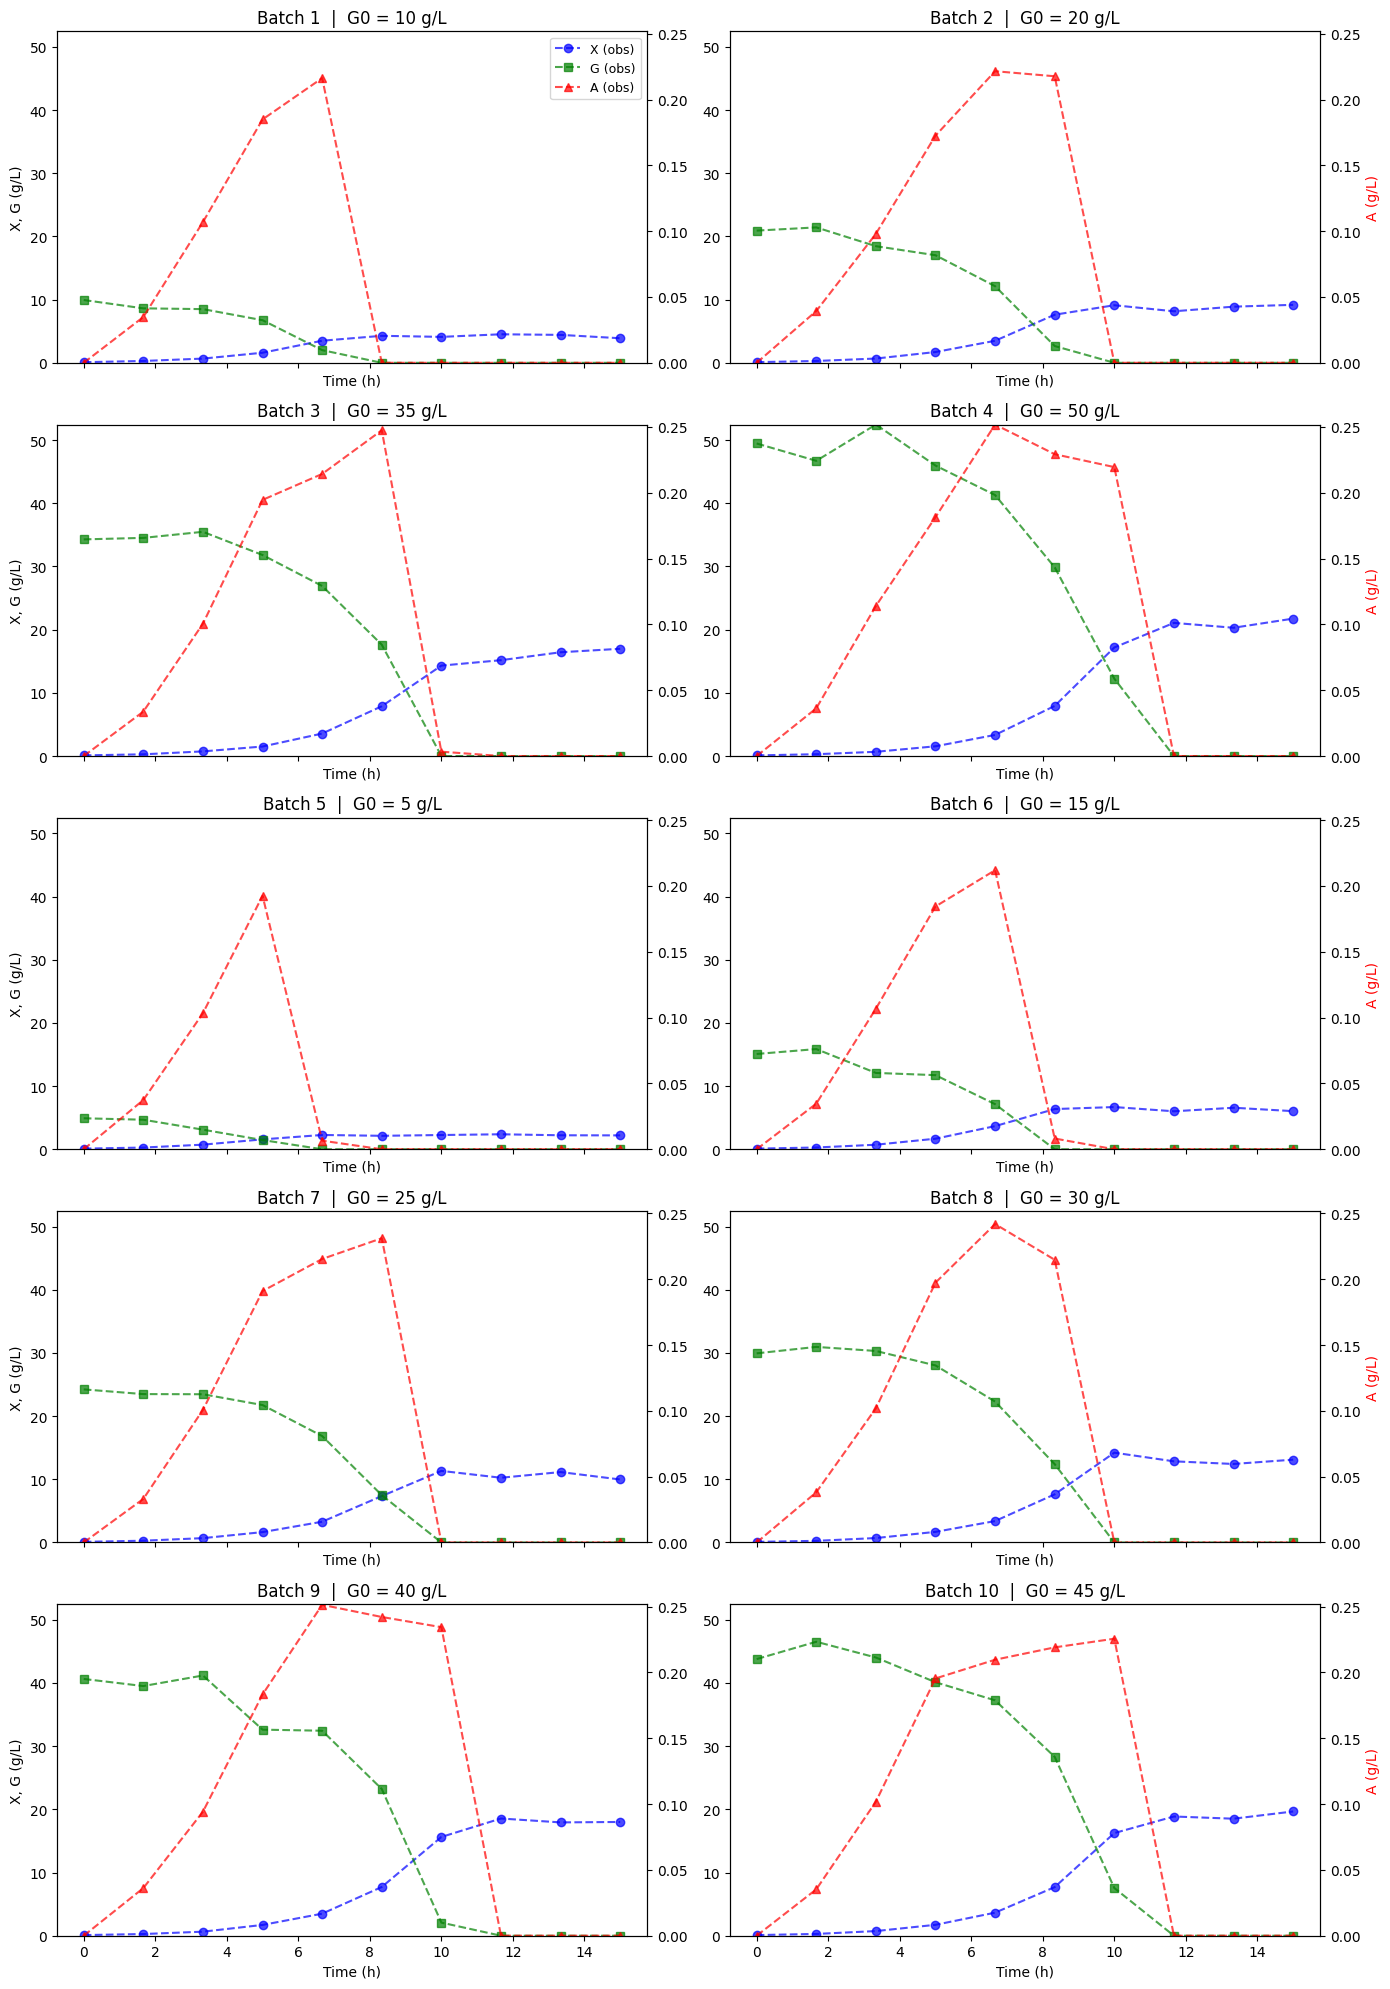

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- Compute global min/max for consistent y-axes ---
X_all = np.concatenate([np.array(x) for x in obs_X])
G_all = np.concatenate([np.array(g) for g in obs_G])
A_all = np.concatenate([np.array(a) for a in obs_A])

ymin_XG = min(X_all.min(), G_all.min())
ymax_XG = max(X_all.max(), G_all.max())

ymin_A = A_all.min()
ymax_A = A_all.max()

# --- Figure: 2 rows × 2 cols (4 batches) ---
n_batches = len(initial_glucose)
fig, axes = plt.subplots(5, 2, figsize=(14, 20), sharex=True)
axes = axes.flatten()

for i, (G0, t, X_true, G_true, A_true, X_obs, G_obs, A_obs) in enumerate(
    zip(initial_glucose, raw_t, raw_X, raw_G, raw_A, obs_X, obs_G, obs_A)
):
    ax1 = axes[i]
    ax2 = ax1.twinx()

    # X (blue) and G (green) on left axis
    ax1.plot(t, X_obs, 'b--', marker='o', alpha=0.7, label='X (obs)')
    ax1.plot(t, G_obs, 'g--', marker='s', alpha=0.7, label='G (obs)')
    ax1.set_xlabel("Time (h)")
    ax1.set_ylim(ymin_XG, ymax_XG)
    if i % 2 == 0:  # first column
        ax1.set_ylabel("X, G (g/L)")

    # A (red) on right axis
    ax2.plot(t, A_obs, 'r--', marker='^', alpha=0.7, label='A (obs)')
    ax2.set_ylim(ymin_A, ymax_A)
    if i % 2 == 1:  # last column
        ax2.set_ylabel("A (g/L)", color='r')

    # Title with Batch number + G0
    ax1.set_title(f"Batch {i+1}  |  G0 = {G0} g/L")

    # Merge legends (only on first subplot to avoid clutter)
    if i == 0:
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=9)

# Hide any extra axes if present
for j in range(n_batches, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


The following code runs the **hyperparameter sweep for Case Study 1**: the growth of
*Escherichia coli* on glucose with acetate production through overflow metabolism, on
synthetic data. For every combination of
hyperparameters and every random seed the model is trained, evaluated on training,
validation and test experiments, and recorded, so that the configuration used in the
paper is selected from the results rather than assumed.

**Model structure** (three states: biomass $X$, glucose $G$, acetate $A$)

$$
\begin{aligned}
\frac{dX}{dt} &= f_{1}(\cdot)\,X,\\[4pt]
\frac{dG}{dt} &= f_{2}(\cdot)\,G\,X,\\[4pt]
\frac{dA}{dt} &= f_{3}(\cdot)\,A\,X + g_{3}(\cdot)\,X.
\end{aligned}
$$

The functions $f_1$, $f_2$, $f_3$ and $g_3$ form the **output layer** of the neural
network, which receives $(X,G,A)$ as input. The output activation is the **identity**
for the $f_i$, since $f_1$ must be free to become negative to represent biomass decay,
and **ReLU** for $g_3$, which prevents acetate from being generated out of nothing. No
mechanistic parameter is introduced.

---

### 🔬 Two-study workflow

The script is meant to be run twice, controlled by the `MC_DROPOUT` switch:

- **Study 1 — exploration** (`MC_DROPOUT = False`): the whole grid is swept quickly,
  without stochastic forward passes. The winning configuration is chosen from the
  *Summary* and *Architecture* sheets of the Excel output.
- **Study 2 — uncertainty** (`MC_DROPOUT = True`): the grid is narrowed to the selected
  configuration and re-run. The trained model is then integrated `MC_SAMPLES` times with
  dropout active at prediction time, each sample using one dropout mask held fixed along
  the whole trajectory, and the percentiles of the resulting trajectories give the
  predictive bands. This step is expensive and is meant for a handful of configurations.

The resume logic keys on (configuration, seed), so runs already in the csv are skipped:
narrowing the grid or raising `N_SEEDS` and re-running only trains what is new.

---

### 🔧 Algorithm configuration

- **DATA_SOURCE** (`"clean"` | `"noisy"`): fits the clean synthetic data `raw_*` or the
  version with multiplicative noise `obs_*`.

- **TRAIN_MODE** (`"batch"` | `"global"`):
  - `"batch"`: each batch experiment is treated as an independent minibatch; parameters
    are updated once per experiment, so several times per epoch.
  - `"global"`: the loss of all experiments is accumulated and a single update is
    performed per epoch (full-batch optimization).

- **GRID_LR, GRID_DROPOUT, GRID_ACTIVATION, GRID_HIDDEN, GRID_LAMBDA_IC:** the grid of
  learning rates, dropout rates, hidden activations, architectures and weights of the
  initial-condition penalty. Only the hidden activation is swept; the output activations
  are structural.

- **NUM_EPOCHS:** maximum number of complete passes through the training set.
  Throughout training the parameters attaining the lowest validation loss are retained,
  and those define the model reported for the run.

- **SEED_START / N_SEEDS:** first seed and number of random initializations per
  configuration.

- **train_idxs / valid_idxs / test_idxs:** the data partition, at the experiment level.
  Training uses $G_0 = 20, 25, 30$ g/L, validation $G_0 = 15, 35$ g/L and test
  $G_0 = 5, 10, 40, 45, 50$ g/L, so both held-out sets lie outside the training range,
  the test experiments further than the validation ones.

- **MC_DROPOUT, MC_SAMPLES, MC_RATE, MC_CI:** the uncertainty pass. `MC_RATE = None`
  reuses the dropout rate of the configuration; a zero rate produces no variability, so
  a positive value is required for sampling.

- **SOLVER, ODE_RTOL, ODE_ATOL, ODE_MAX_STEPS:** ODE integration, by default the Tsit5
  explicit Runge–Kutta method of `diffrax` with adaptive step size. Gradients are
  obtained by backpropagating through the solver. `ODE_MAX_STEPS` is a safety cap: a
  healthy trajectory needs only tens of steps, and a run that exceeds it is producing an
  explosive vector field.

- **CALIB_STEPS / CALIB_LR:** zero-field pretraining. Before training, the network
  outputs are driven to zero so that the initial vector field nearly vanishes and the
  states stay at their initial conditions, giving a neutral starting point.

- **DIVERGENCE_THRESHOLD:** a run whose loss grows beyond this value is aborted and
  flagged as diverged; the parameters of the best epoch reached before the interruption
  are still kept.

- **EPS:** small positive constant that stabilizes the divisions in the loss function.

---

### 🧠 MLP architecture

Assembled into `layer_sizes` as `input – hidden … – output`. The input dimension is
**3**, the state vector $(X,G,A)$, and the output dimension is **4**
($f_1,f_2,f_3,g_3$). A configuration with `hidden = [5, 5]` therefore gives `3-5-5-4`.
The start-up banner prints, for every architecture, the number of weights and the
ratio of training measurements per weight.

---

### 📦 Outputs

The script writes `sweep_runs_proposed.csv` (one row per run) and
`sensitivity_proposed.xlsx`, whose sheets hold the individual runs, a per-configuration
summary across seeds, the architecture comparison, the uncertainty metrics when Monte
Carlo dropout is enabled (relative band width and coverage, per split and per variable),
the determination coefficients in long format and the protocol of the sweep. Each run
also records the minimum concentration reached along the simulated trajectories, the
empirical counterpart of the non-negativity property. Trajectory and loss figures are
saved per run, the best parameters of every run are pickled, and vector figures,
including the uncertainty bands, are produced for the best run.

jax 0.11.1 | diffrax 0.7.2 | optax 0.2.8
Backend: tpu | Devices: [TpuDevice(id=0, process_index=0, coords=(0,0,0), core_on_chip=0)]
Matplotlib backend: Agg | SHOW_PLOTS=True

FULL SWEEP: 2 LR x 1 dropout x 4 arch x 1 lambda x 1 activation = 8 configurations
Models: proposed | seeds: 1 | total trainings: 8
Data source: clean | MC dropout: OFF
------------------------------------------------------------------------------
Training measurements: 90 (3 experiments x 3 state variables)

  Proposed framework (4 network outputs)
          hidden   weights   obs/param
               5        44        2.05
             5-5        74        1.22
           7-7-7       172        0.52
         7-7-7-7       228        0.39


[1/8] LR=0.01 | dropout=0.1 | hidden=5 | lambda_IC=1 | act=tanh
   --- seed 1 (1/1) ---
     proposed:
        ep 400: train=0.047202, valid=0.844227
        ep 800: train=0.053395, valid=0.309203
        ep 1200: train=0.042025, valid=0.397954
        ep 1600: train=0.046513

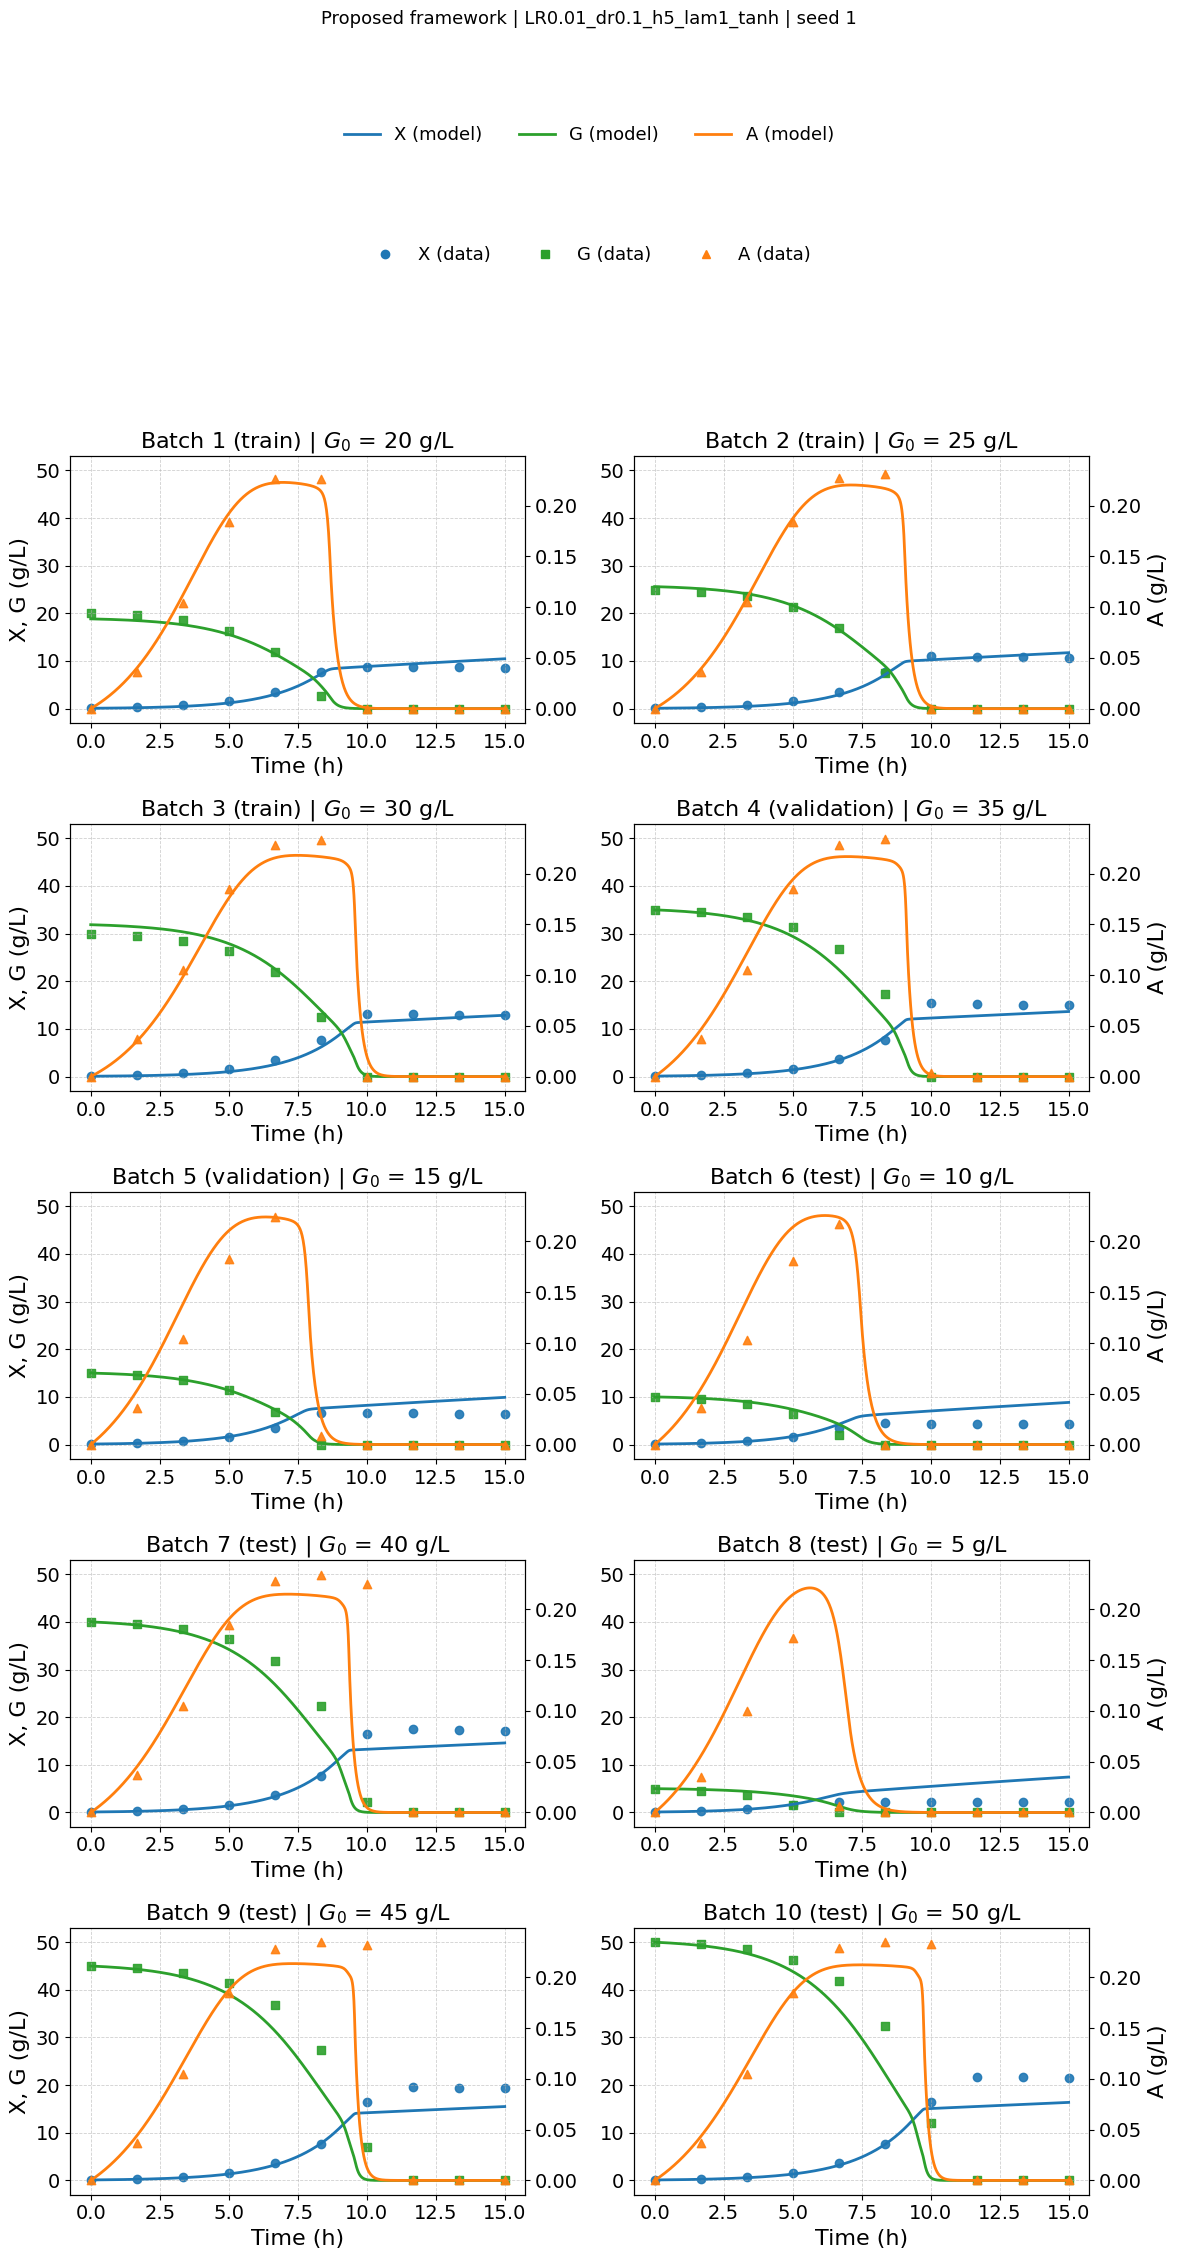

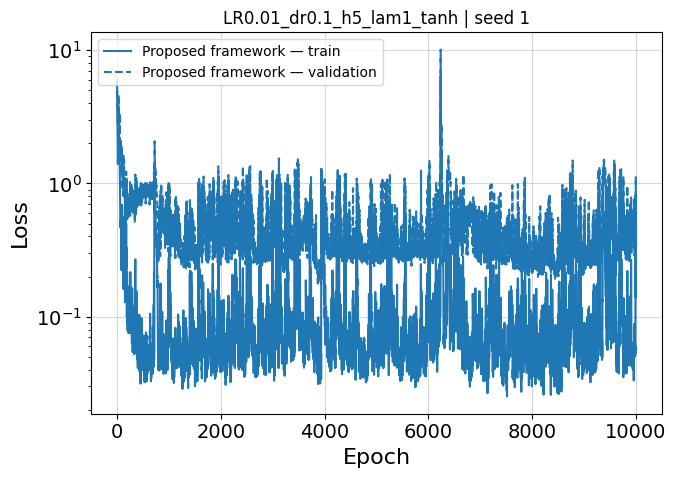

     --> NEW BEST for proposed: 1.7481e-01
   [progress] 1/8 configs | 29.5 min | ETA 206.2 min

[2/8] LR=0.01 | dropout=0.1 | hidden=5-5 | lambda_IC=1 | act=tanh
   --- seed 1 (1/1) ---
     proposed:
        ep 400: train=0.066516, valid=1.351058
        ep 800: train=0.117763, valid=1.286230
        ep 1200: train=0.071983, valid=1.199417
        ep 1600: train=0.109211, valid=1.343343
        ep 2000: train=0.057425, valid=1.312879
        ep 2400: train=0.067833, valid=1.021861
        ep 2800: train=0.071643, valid=1.078329
        ep 3200: train=0.063358, valid=1.013303
        ep 3600: train=0.050228, valid=1.433961
        ep 4000: train=0.302573, valid=1.665778
        ep 4400: train=0.049151, valid=1.027260
        ep 4800: train=0.161026, valid=1.096184
        ep 5200: train=0.069690, valid=1.061262
        ep 5600: train=0.179101, valid=1.070970
        ep 6000: train=0.059613, valid=1.209169
        ep 6400: train=0.080475, valid=1.218283
        ep 6800: train=0.077375,

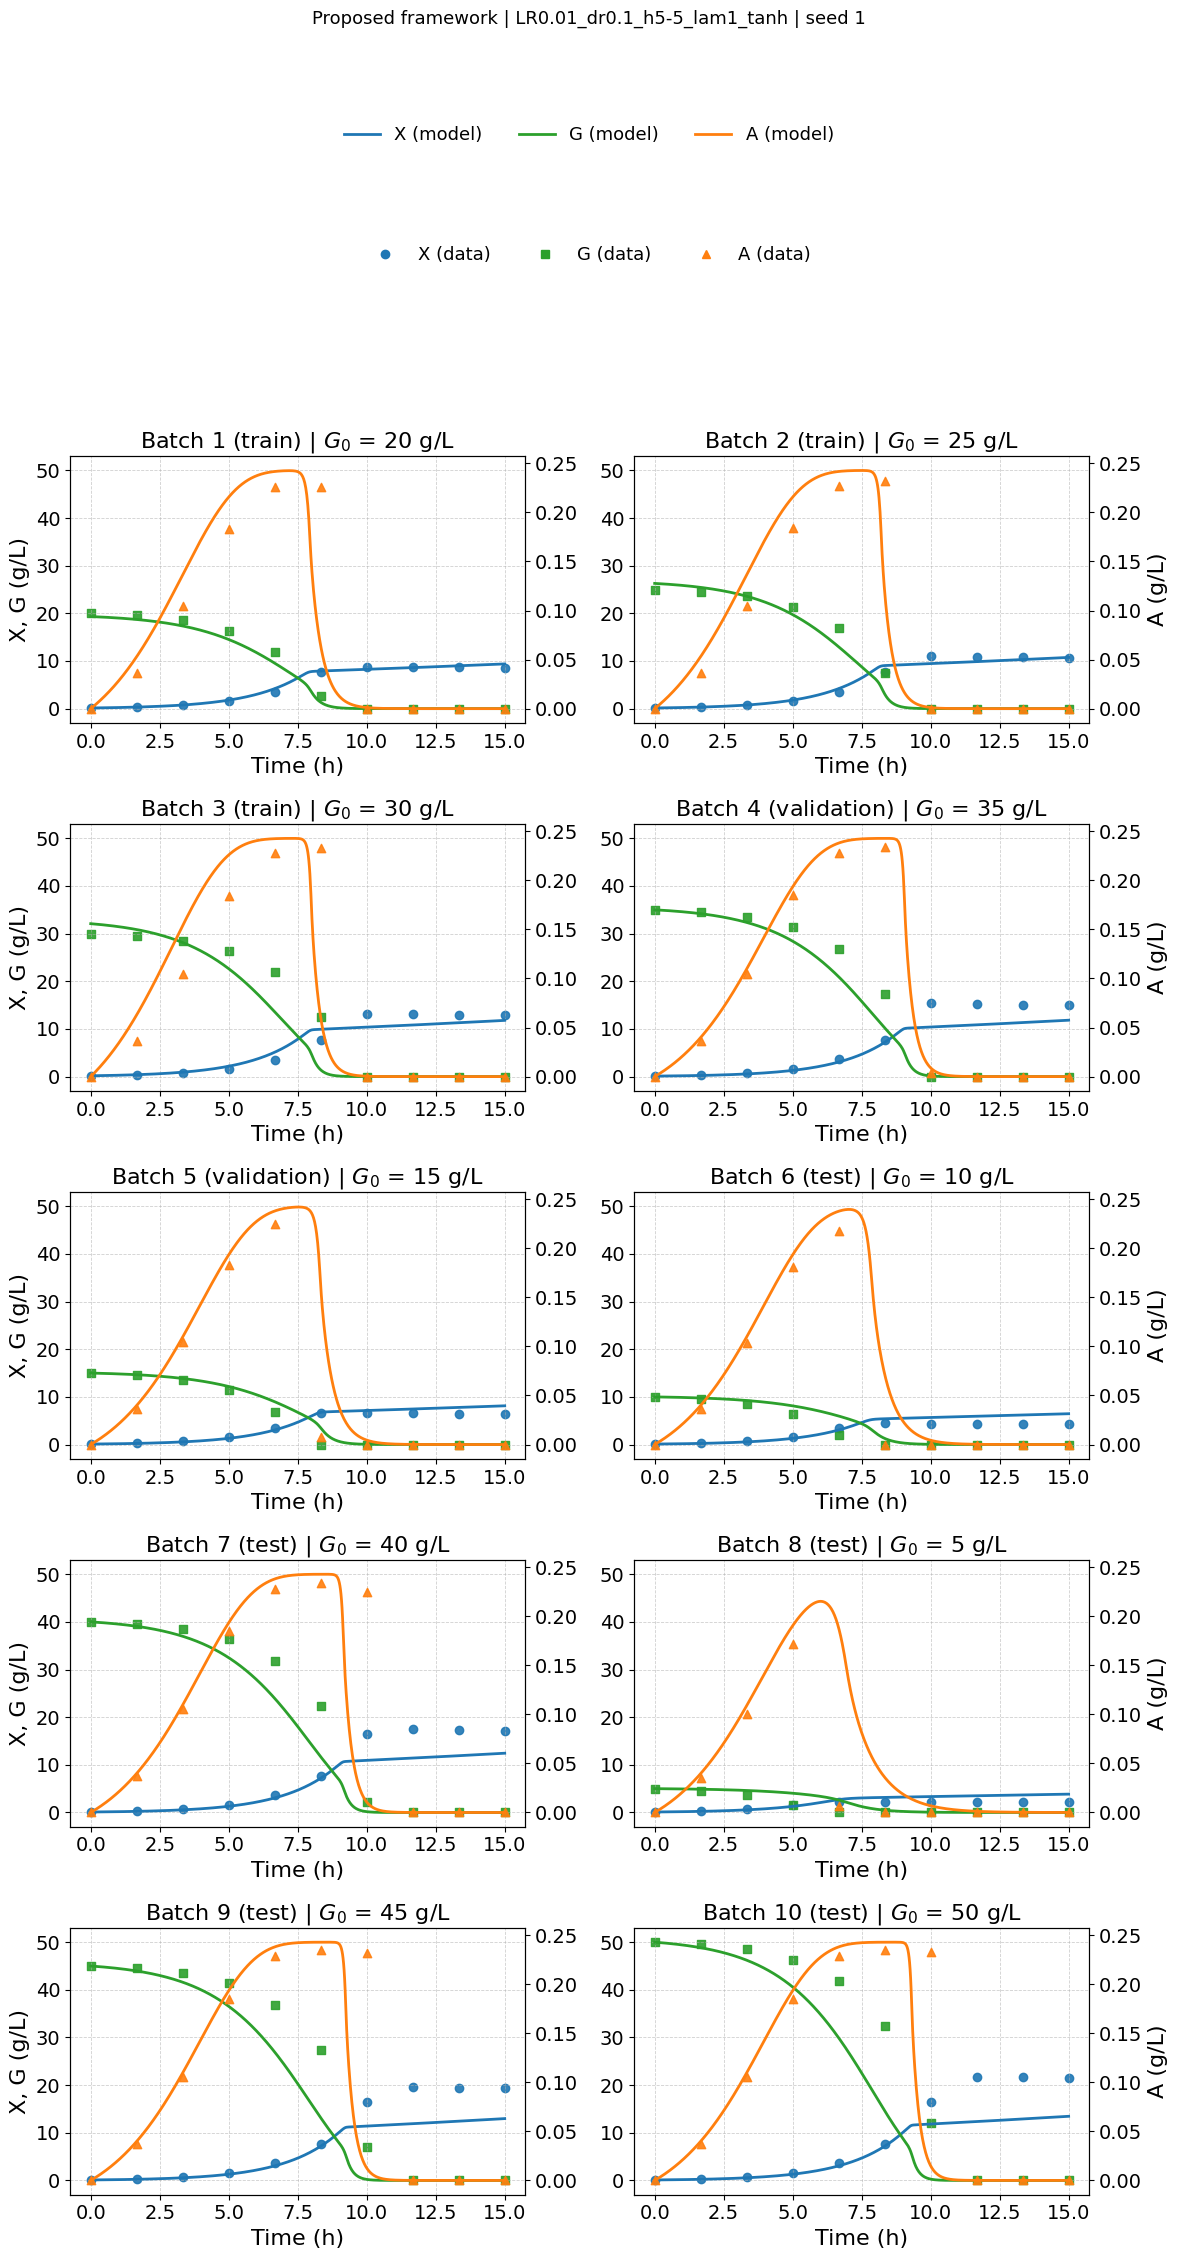

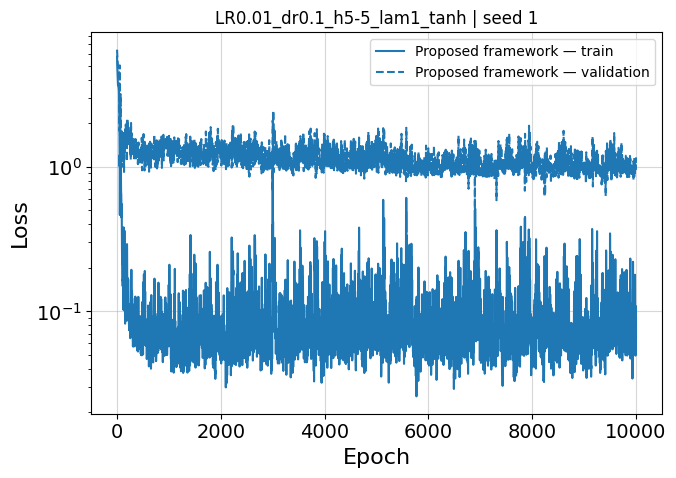

   [progress] 2/8 configs | 61.2 min | ETA 183.6 min

[3/8] LR=0.01 | dropout=0.1 | hidden=7-7-7 | lambda_IC=1 | act=tanh
   --- seed 1 (1/1) ---
     proposed:
        ep 400: train=0.063550, valid=1.379088
        ep 800: train=0.048003, valid=0.975894
        ep 1200: train=0.074992, valid=1.323752
        ep 1600: train=0.060835, valid=0.975069
        ep 2000: train=0.057533, valid=1.131279
        ep 2400: train=0.058522, valid=0.867160
        ep 2800: train=0.112182, valid=0.912913
        ep 3200: train=0.066289, valid=0.974430
        ep 3600: train=0.244033, valid=0.677836
        ep 4000: train=0.088579, valid=0.729427
        ep 4400: train=0.065826, valid=0.857402
        ep 4800: train=0.064796, valid=0.949762
        ep 5200: train=0.105721, valid=1.092529
        ep 5600: train=0.074894, valid=0.886597
        ep 6000: train=0.048610, valid=0.833812
        ep 6400: train=0.256731, valid=0.967820
        ep 6800: train=0.057128, valid=0.979828
        ep 7200: train=0.

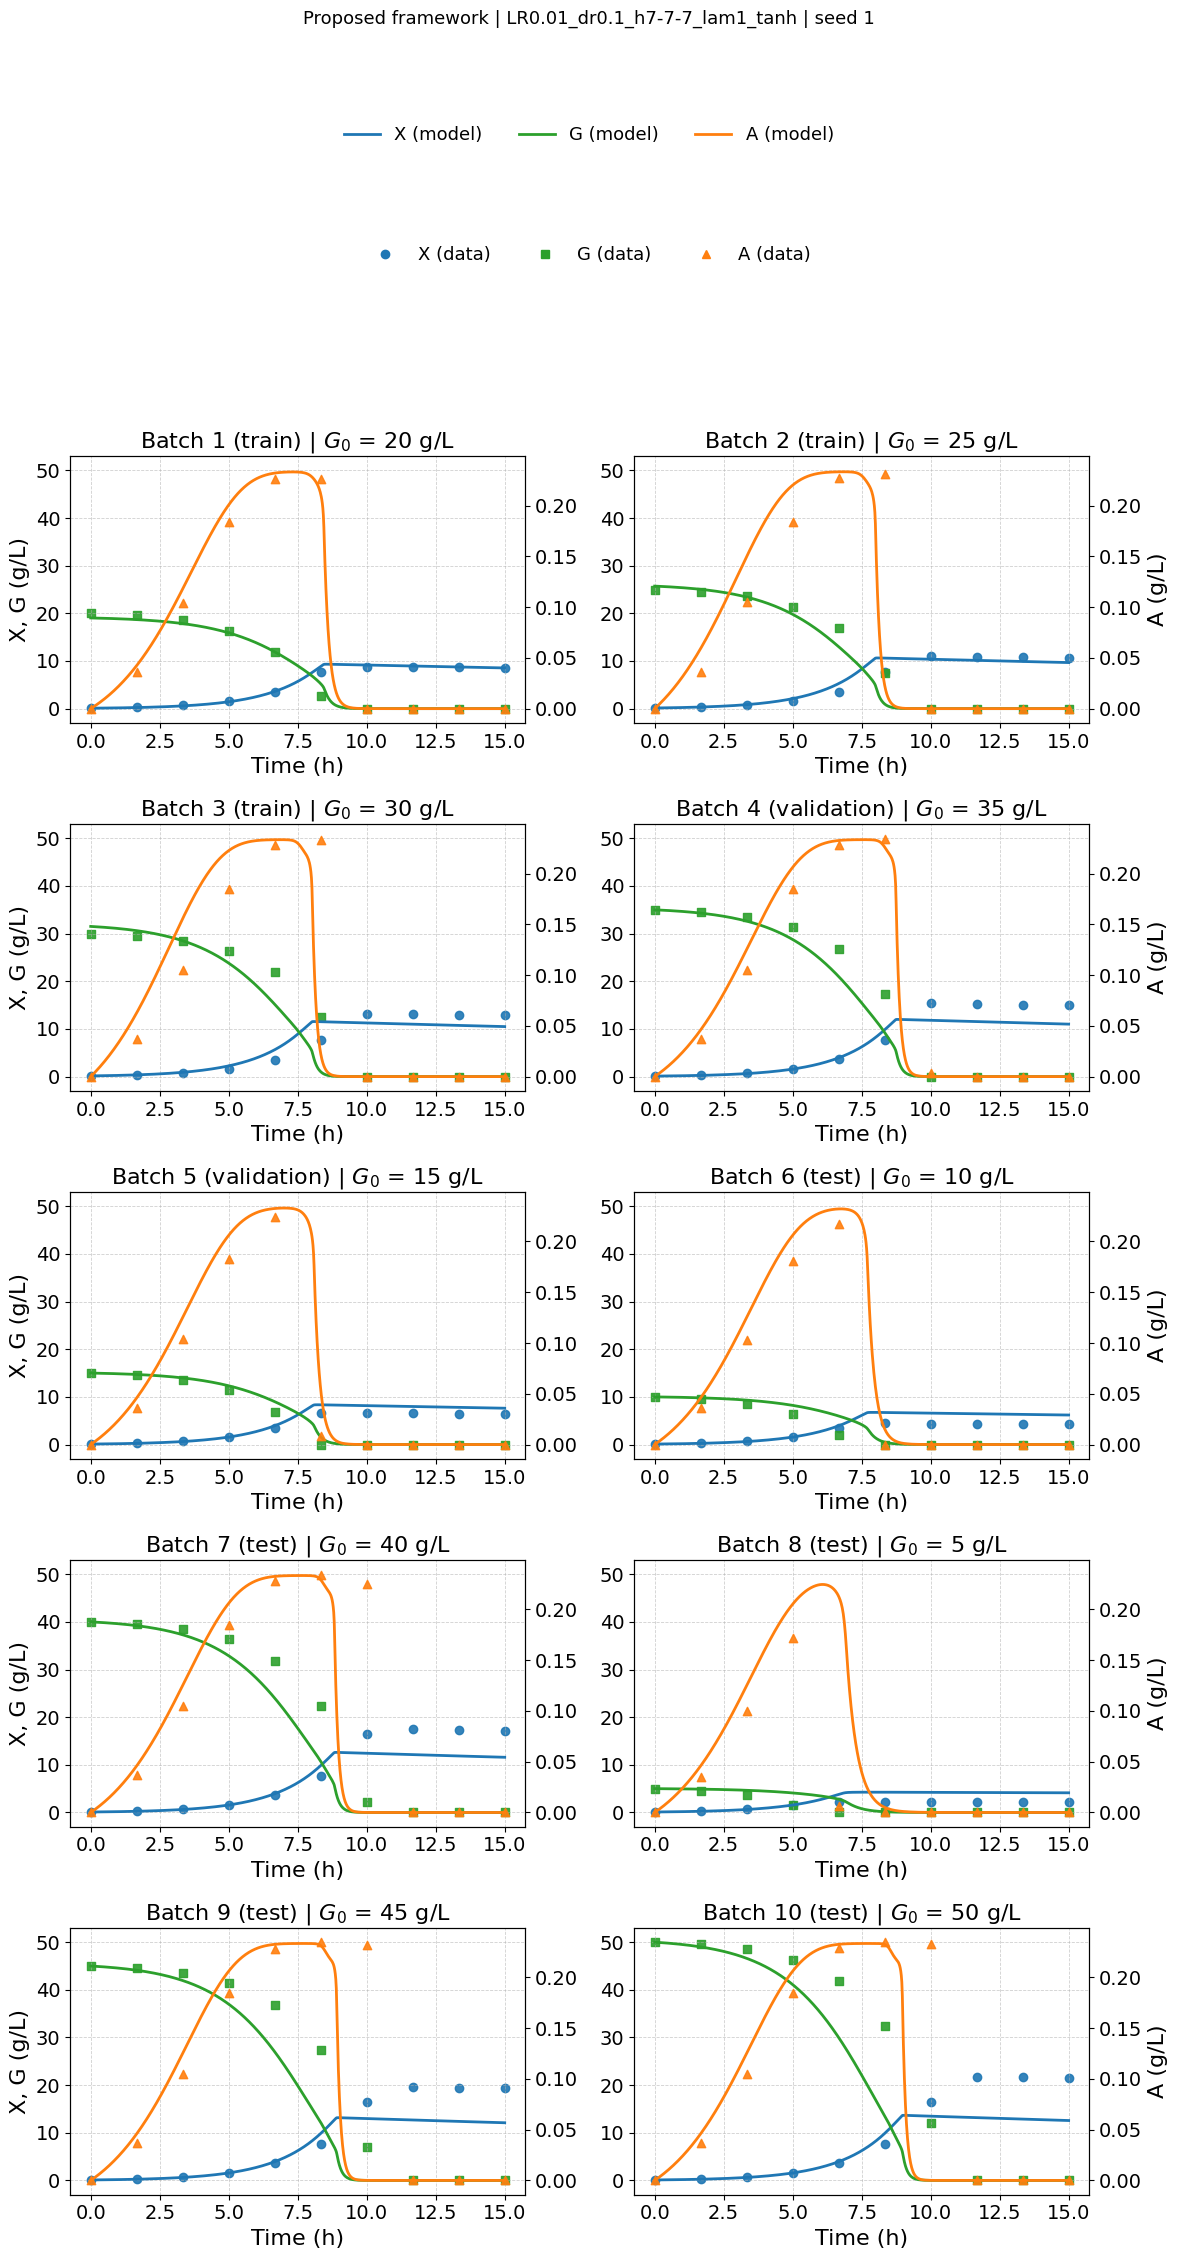

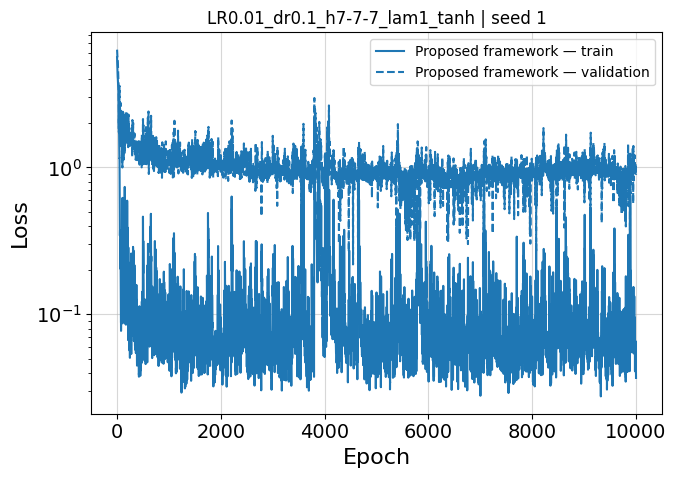

   [progress] 3/8 configs | 95.7 min | ETA 159.6 min

[4/8] LR=0.01 | dropout=0.1 | hidden=7-7-7-7 | lambda_IC=1 | act=tanh
   --- seed 1 (1/1) ---
     proposed:
        ep 400: train=0.107936, valid=2.224229
        ep 800: train=0.094667, valid=1.038700
        ep 1200: train=0.042437, valid=1.018100
        ep 1600: train=0.078563, valid=0.968431
        ep 2000: train=0.049231, valid=0.900719
        ep 2400: train=1.734337, valid=2.084534
        ep 2800: train=0.119998, valid=0.598851
        ep 3200: train=0.076584, valid=0.995878
        ep 3600: train=0.170330, valid=0.325577
        ep 4000: train=0.055897, valid=0.925271
        ep 4400: train=0.087677, valid=0.262503
        ep 4800: train=4.543317, valid=6.339053
        ep 5200: train=4.292657, valid=6.195474
        ep 5600: train=3.997703, valid=5.840118
        ep 6000: train=3.767823, valid=5.221402
        ep 6400: train=3.665905, valid=4.941100
        ep 6800: train=3.590342, valid=4.617392
        ep 7200: train=

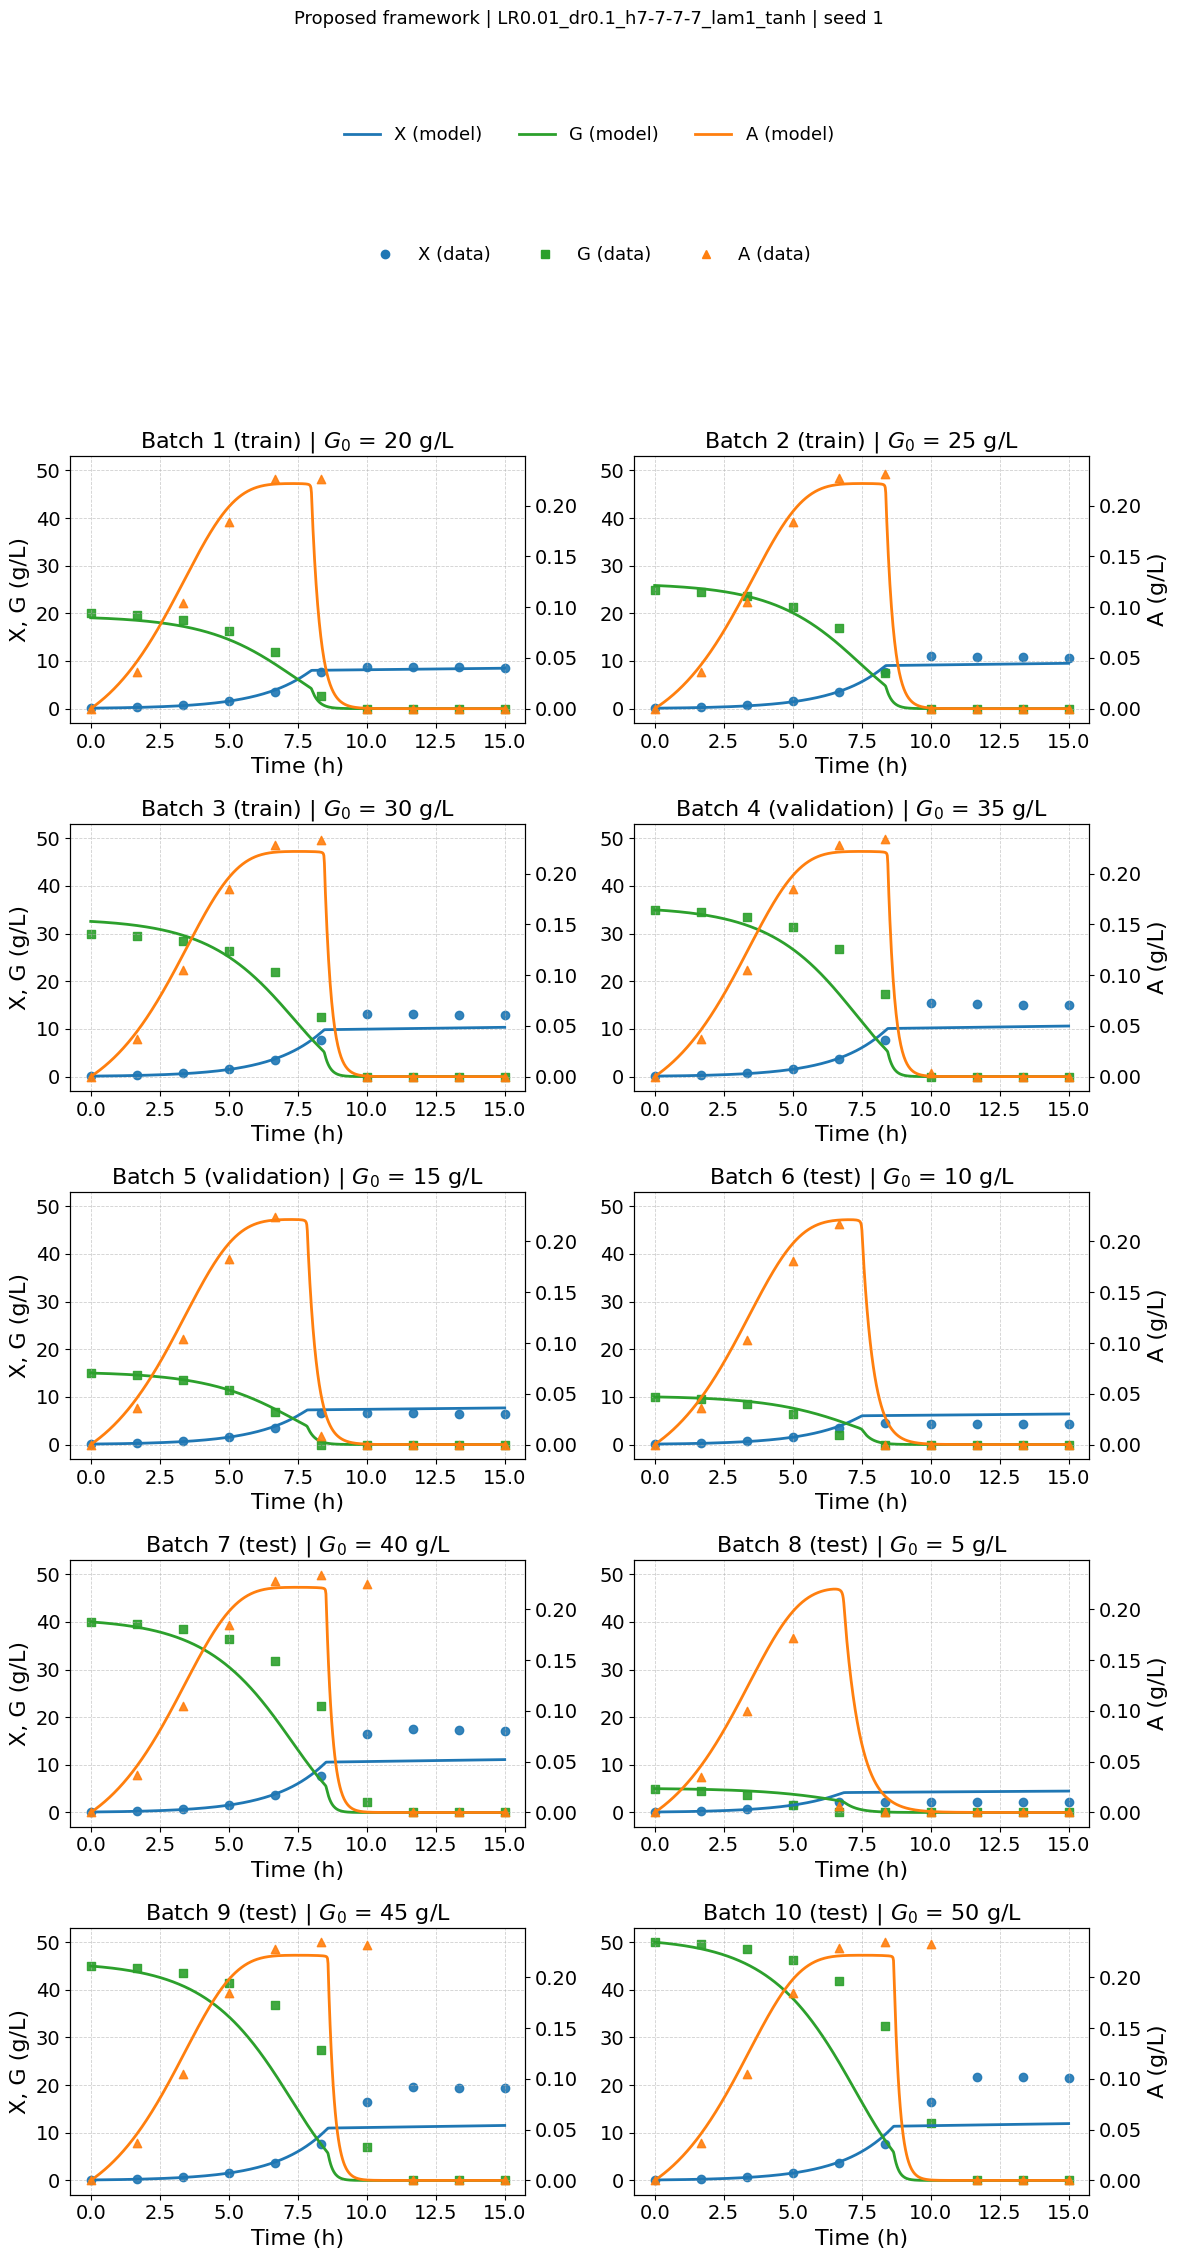

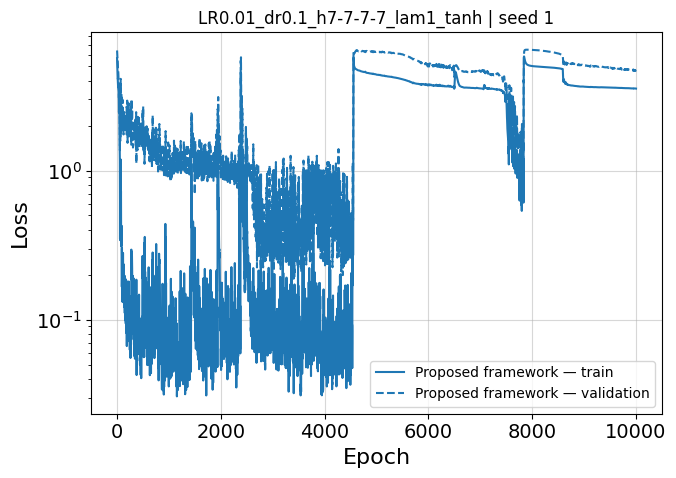

   [progress] 4/8 configs | 128.2 min | ETA 128.2 min

[5/8] LR=0.001 | dropout=0.1 | hidden=5 | lambda_IC=1 | act=tanh
   --- seed 1 (1/1) ---
     proposed:
        ep 400: train=0.169367, valid=1.651616
        ep 800: train=0.057279, valid=1.564069
        ep 1200: train=0.062703, valid=1.656073
        ep 1600: train=0.046715, valid=1.544923
        ep 2000: train=0.035490, valid=1.724821
        ep 2400: train=0.036435, valid=1.733775
        ep 2800: train=0.036656, valid=1.628965
        ep 3200: train=0.031660, valid=1.600713
        ep 3600: train=0.032832, valid=1.538822
        ep 4000: train=0.037650, valid=1.533349
        ep 4400: train=0.037651, valid=1.307990
        ep 4800: train=0.025663, valid=1.452865
        ep 5200: train=0.028349, valid=1.287134
        ep 5600: train=0.026398, valid=1.201660
        ep 6000: train=0.022582, valid=1.121606
        ep 6400: train=0.027728, valid=1.070201
        ep 6800: train=0.031640, valid=1.074516
        ep 7200: train=0.02

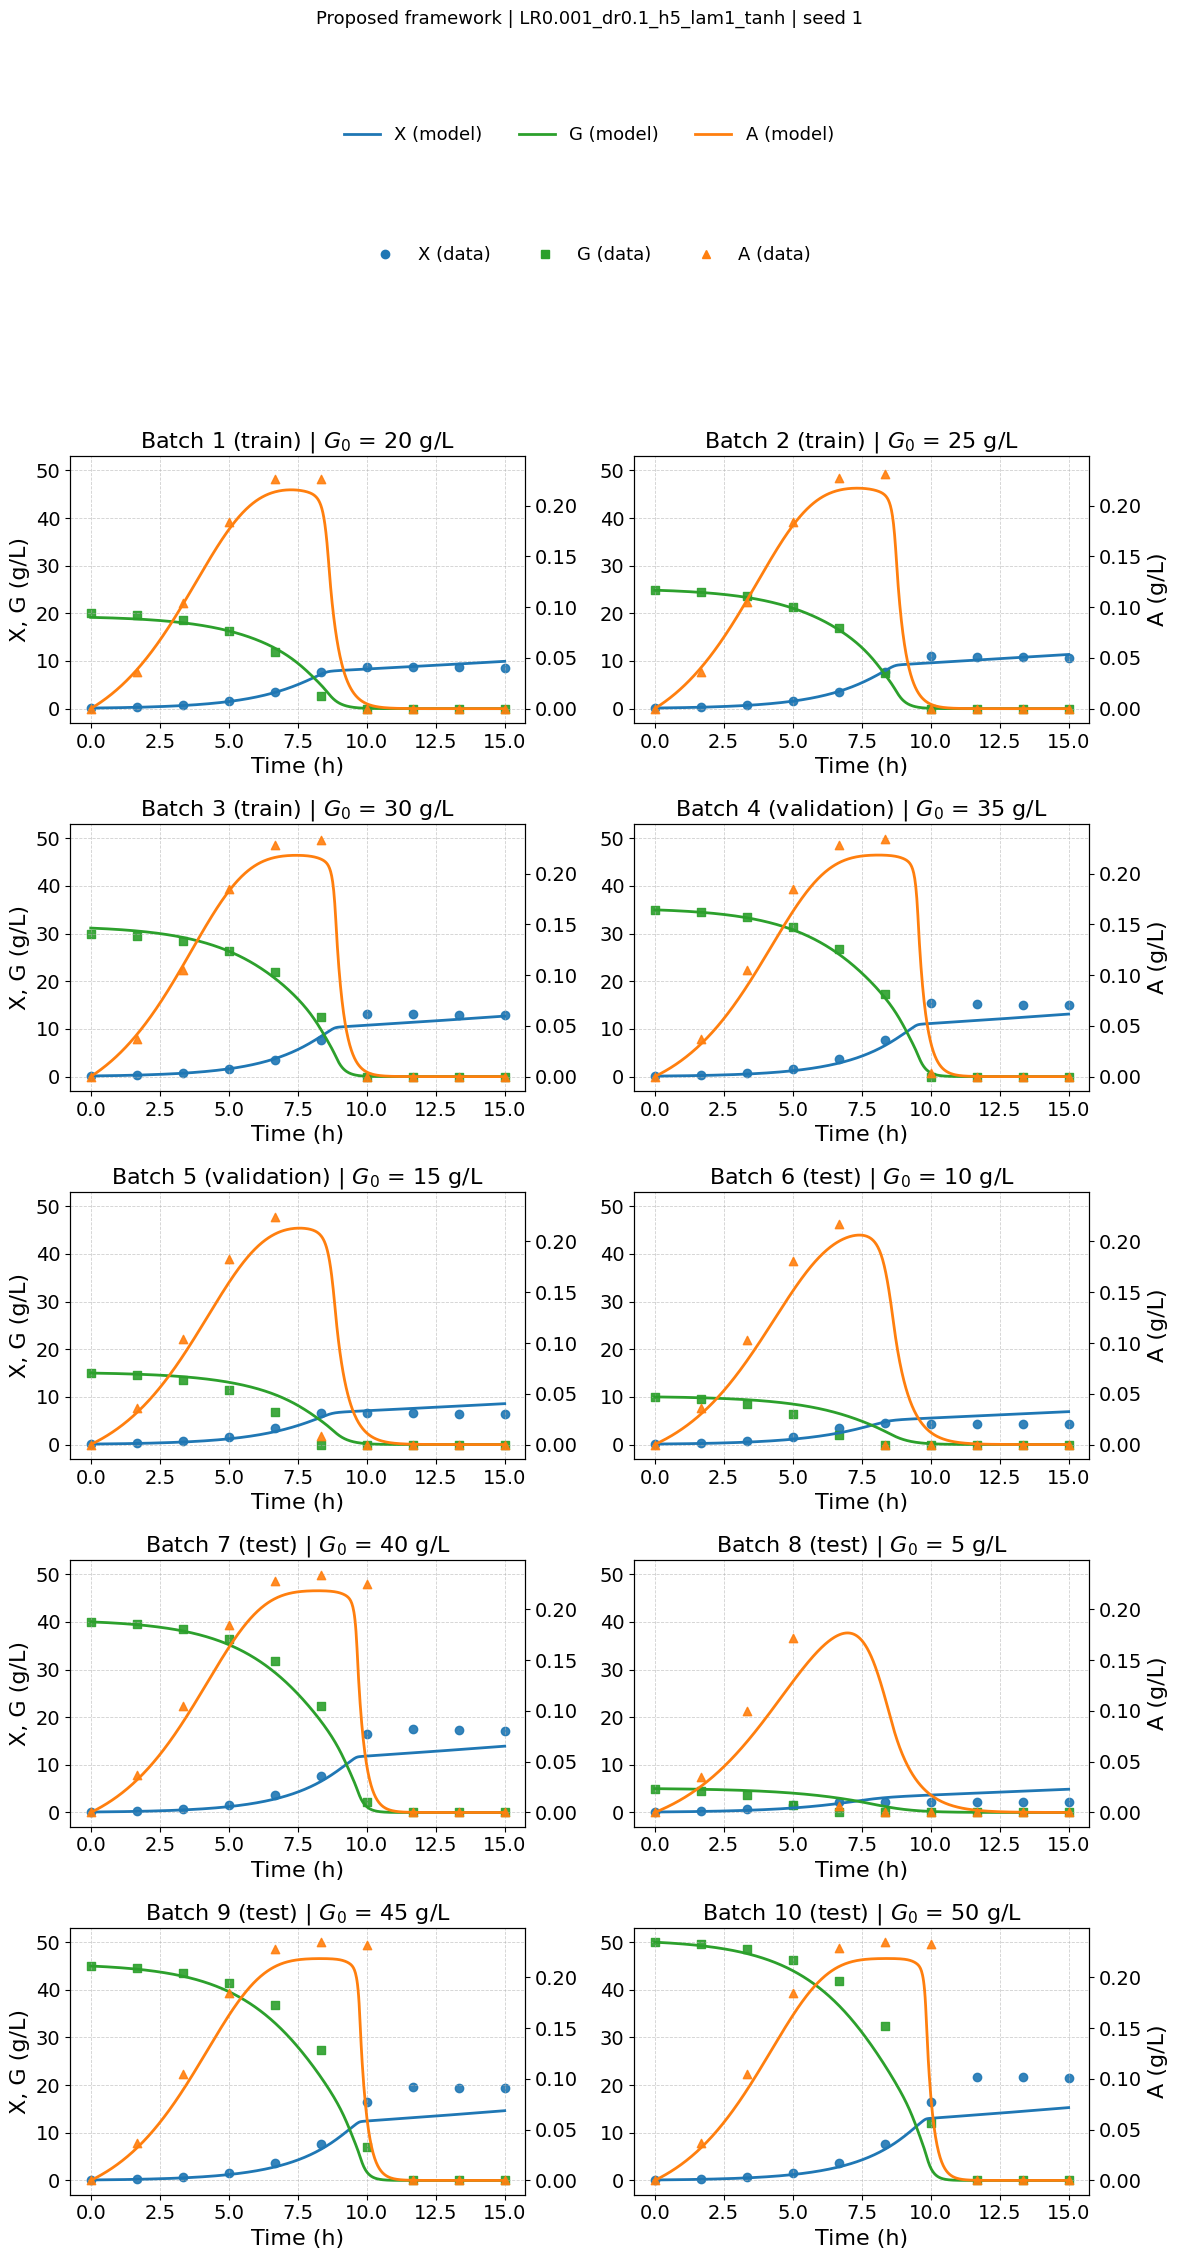

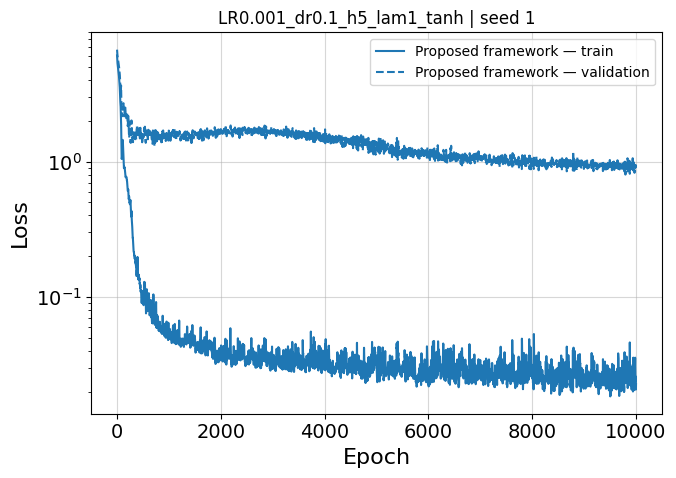

   [progress] 5/8 configs | 156.3 min | ETA 93.8 min

[6/8] LR=0.001 | dropout=0.1 | hidden=5-5 | lambda_IC=1 | act=tanh
   --- seed 1 (1/1) ---
     proposed:
        ep 400: train=0.079723, valid=2.938948
        ep 800: train=0.059298, valid=2.495231
        ep 1200: train=0.054510, valid=2.643828
        ep 1600: train=0.049007, valid=2.322353
        ep 2000: train=0.047213, valid=2.331424
        ep 2400: train=0.041753, valid=2.253955
        ep 2800: train=0.043405, valid=2.059208
        ep 3200: train=0.038158, valid=1.893518
        ep 3600: train=0.039547, valid=1.835966
        ep 4000: train=0.038383, valid=1.779247
        ep 4400: train=0.036516, valid=1.670646
        ep 4800: train=0.031634, valid=1.758098
        ep 5200: train=0.034705, valid=1.708983
        ep 5600: train=0.041614, valid=1.571209
        ep 6000: train=0.032030, valid=1.572642
        ep 6400: train=0.030252, valid=1.525075
        ep 6800: train=0.035730, valid=1.571217
        ep 7200: train=0.0

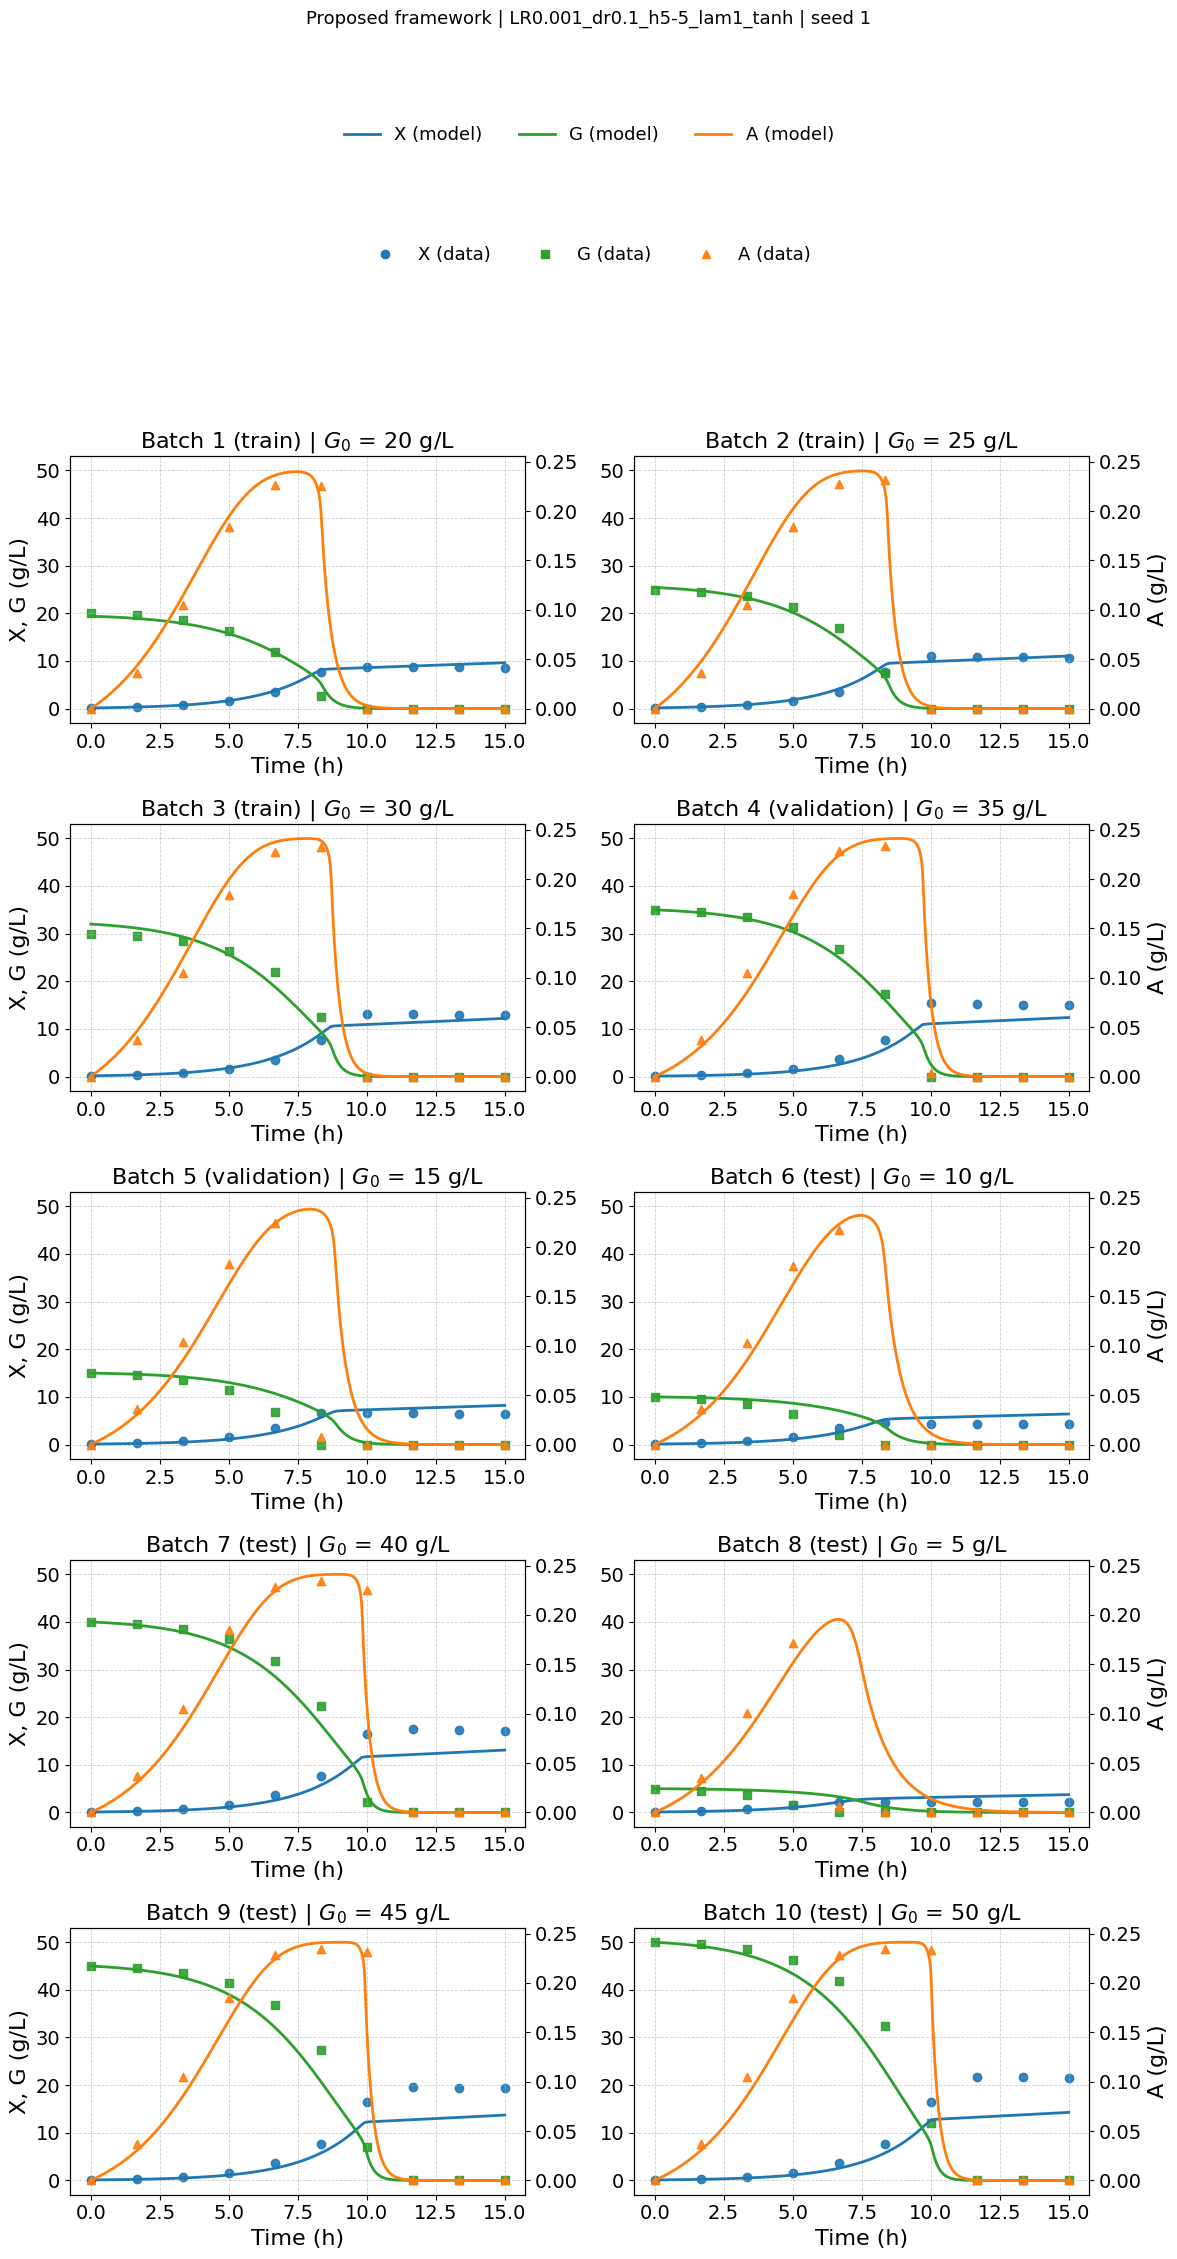

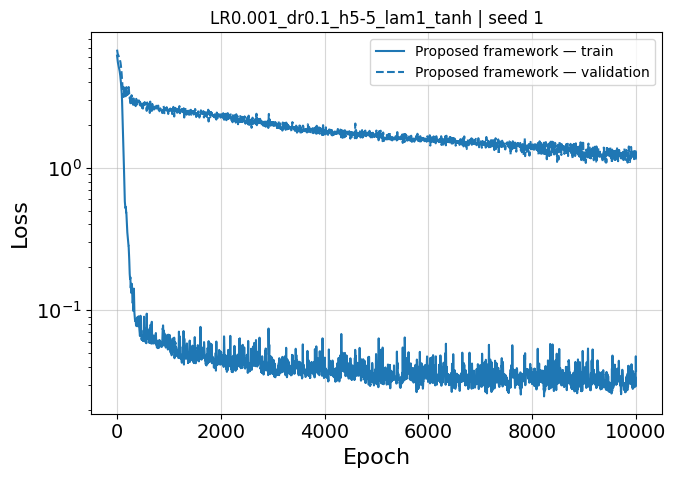

   [progress] 6/8 configs | 187.8 min | ETA 62.6 min

[7/8] LR=0.001 | dropout=0.1 | hidden=7-7-7 | lambda_IC=1 | act=tanh
   --- seed 1 (1/1) ---
     proposed:
        ep 400: train=0.096184, valid=2.408495
        ep 800: train=0.063931, valid=2.207403
        ep 1200: train=0.052119, valid=2.318036
        ep 1600: train=0.052886, valid=1.997833
        ep 2000: train=0.045916, valid=2.111477
        ep 2400: train=0.040463, valid=1.923347
        ep 2800: train=0.053939, valid=1.807715
        ep 3200: train=0.035827, valid=1.759213
        ep 3600: train=0.033139, valid=1.700720
        ep 4000: train=0.033048, valid=1.697185
        ep 4400: train=0.037497, valid=1.688237
        ep 4800: train=0.031193, valid=1.549916
        ep 5200: train=0.052640, valid=1.678154
        ep 5600: train=0.030276, valid=1.489627
        ep 6000: train=0.026719, valid=1.168094
        ep 6400: train=0.030856, valid=1.458754
        ep 6800: train=0.033180, valid=1.361535
        ep 7200: train=0

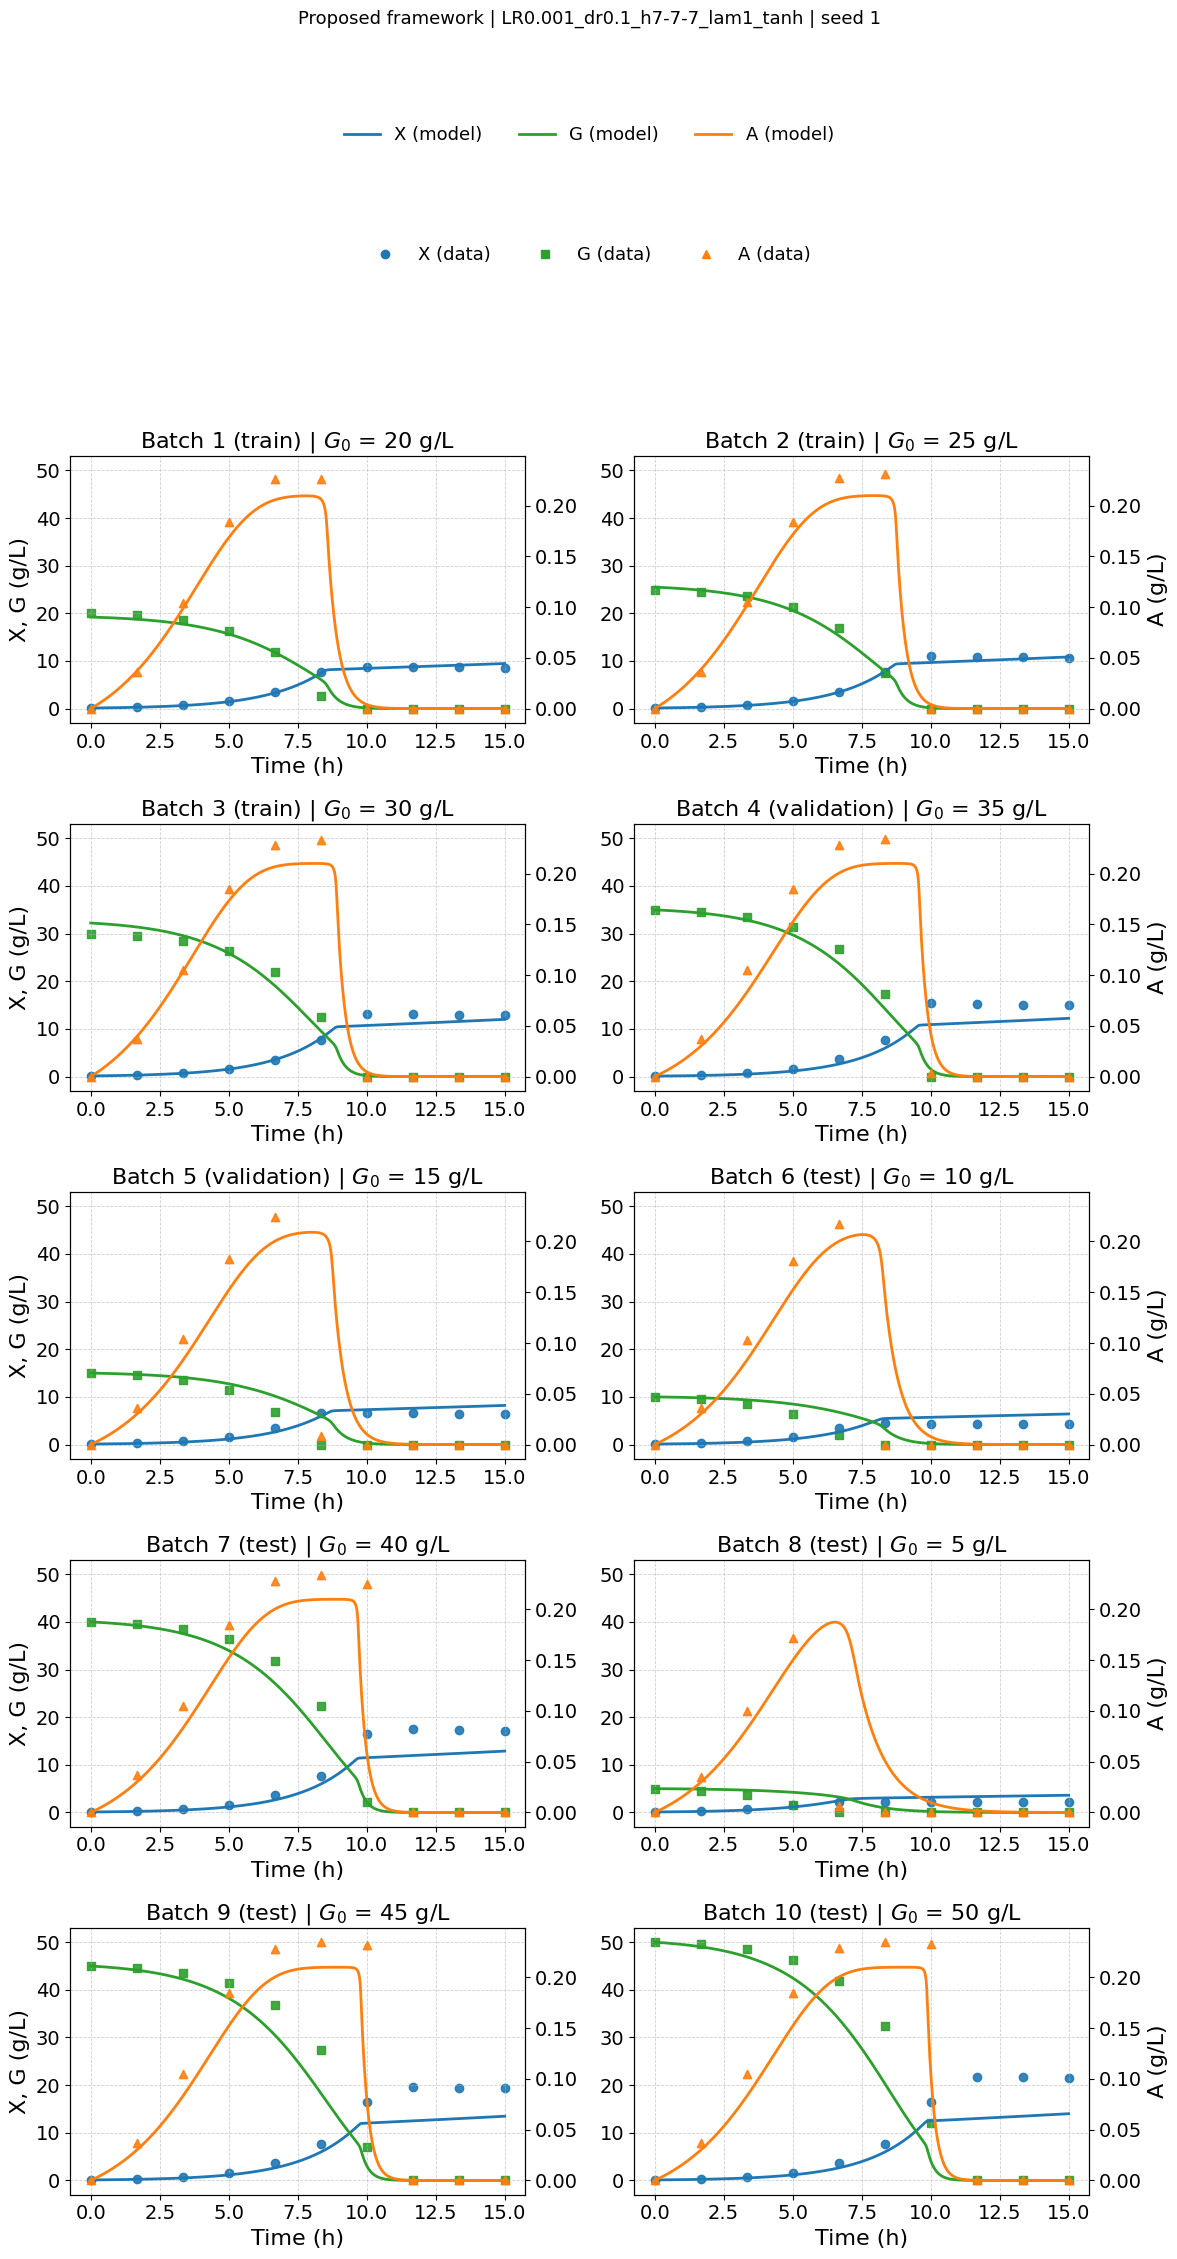

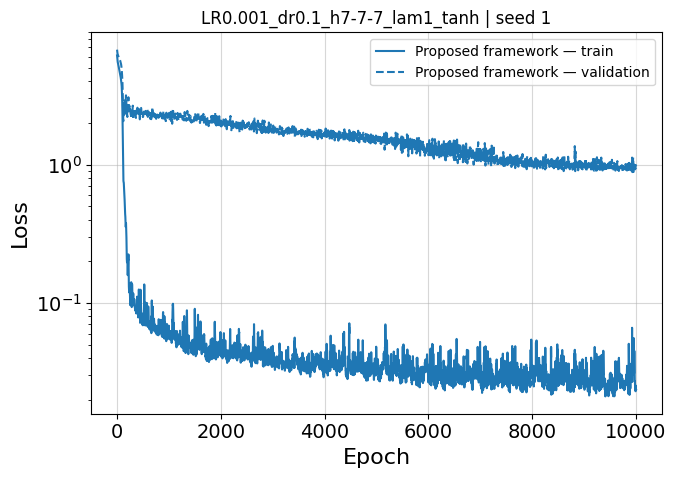

   [progress] 7/8 configs | 221.3 min | ETA 31.6 min

[8/8] LR=0.001 | dropout=0.1 | hidden=7-7-7-7 | lambda_IC=1 | act=tanh
   --- seed 1 (1/1) ---
     proposed:
        ep 400: train=0.106224, valid=2.530053
        ep 800: train=0.065995, valid=2.271561
        ep 1200: train=0.060395, valid=2.539723
        ep 1600: train=0.055365, valid=2.401782
        ep 2000: train=0.047449, valid=2.419824
        ep 2400: train=0.043023, valid=2.231323
        ep 2800: train=0.037573, valid=2.047715
        ep 3200: train=0.052327, valid=1.906602
        ep 3600: train=0.042966, valid=1.920902
        ep 4000: train=0.033540, valid=1.778687
        ep 4400: train=0.036469, valid=1.673776
        ep 4800: train=0.038829, valid=1.677026
        ep 5200: train=0.030544, valid=1.499902
        ep 5600: train=0.032992, valid=1.585521
        ep 6000: train=0.025424, valid=1.506243
        ep 6400: train=0.034395, valid=1.431612
        ep 6800: train=0.043475, valid=1.362259
        ep 7200: train

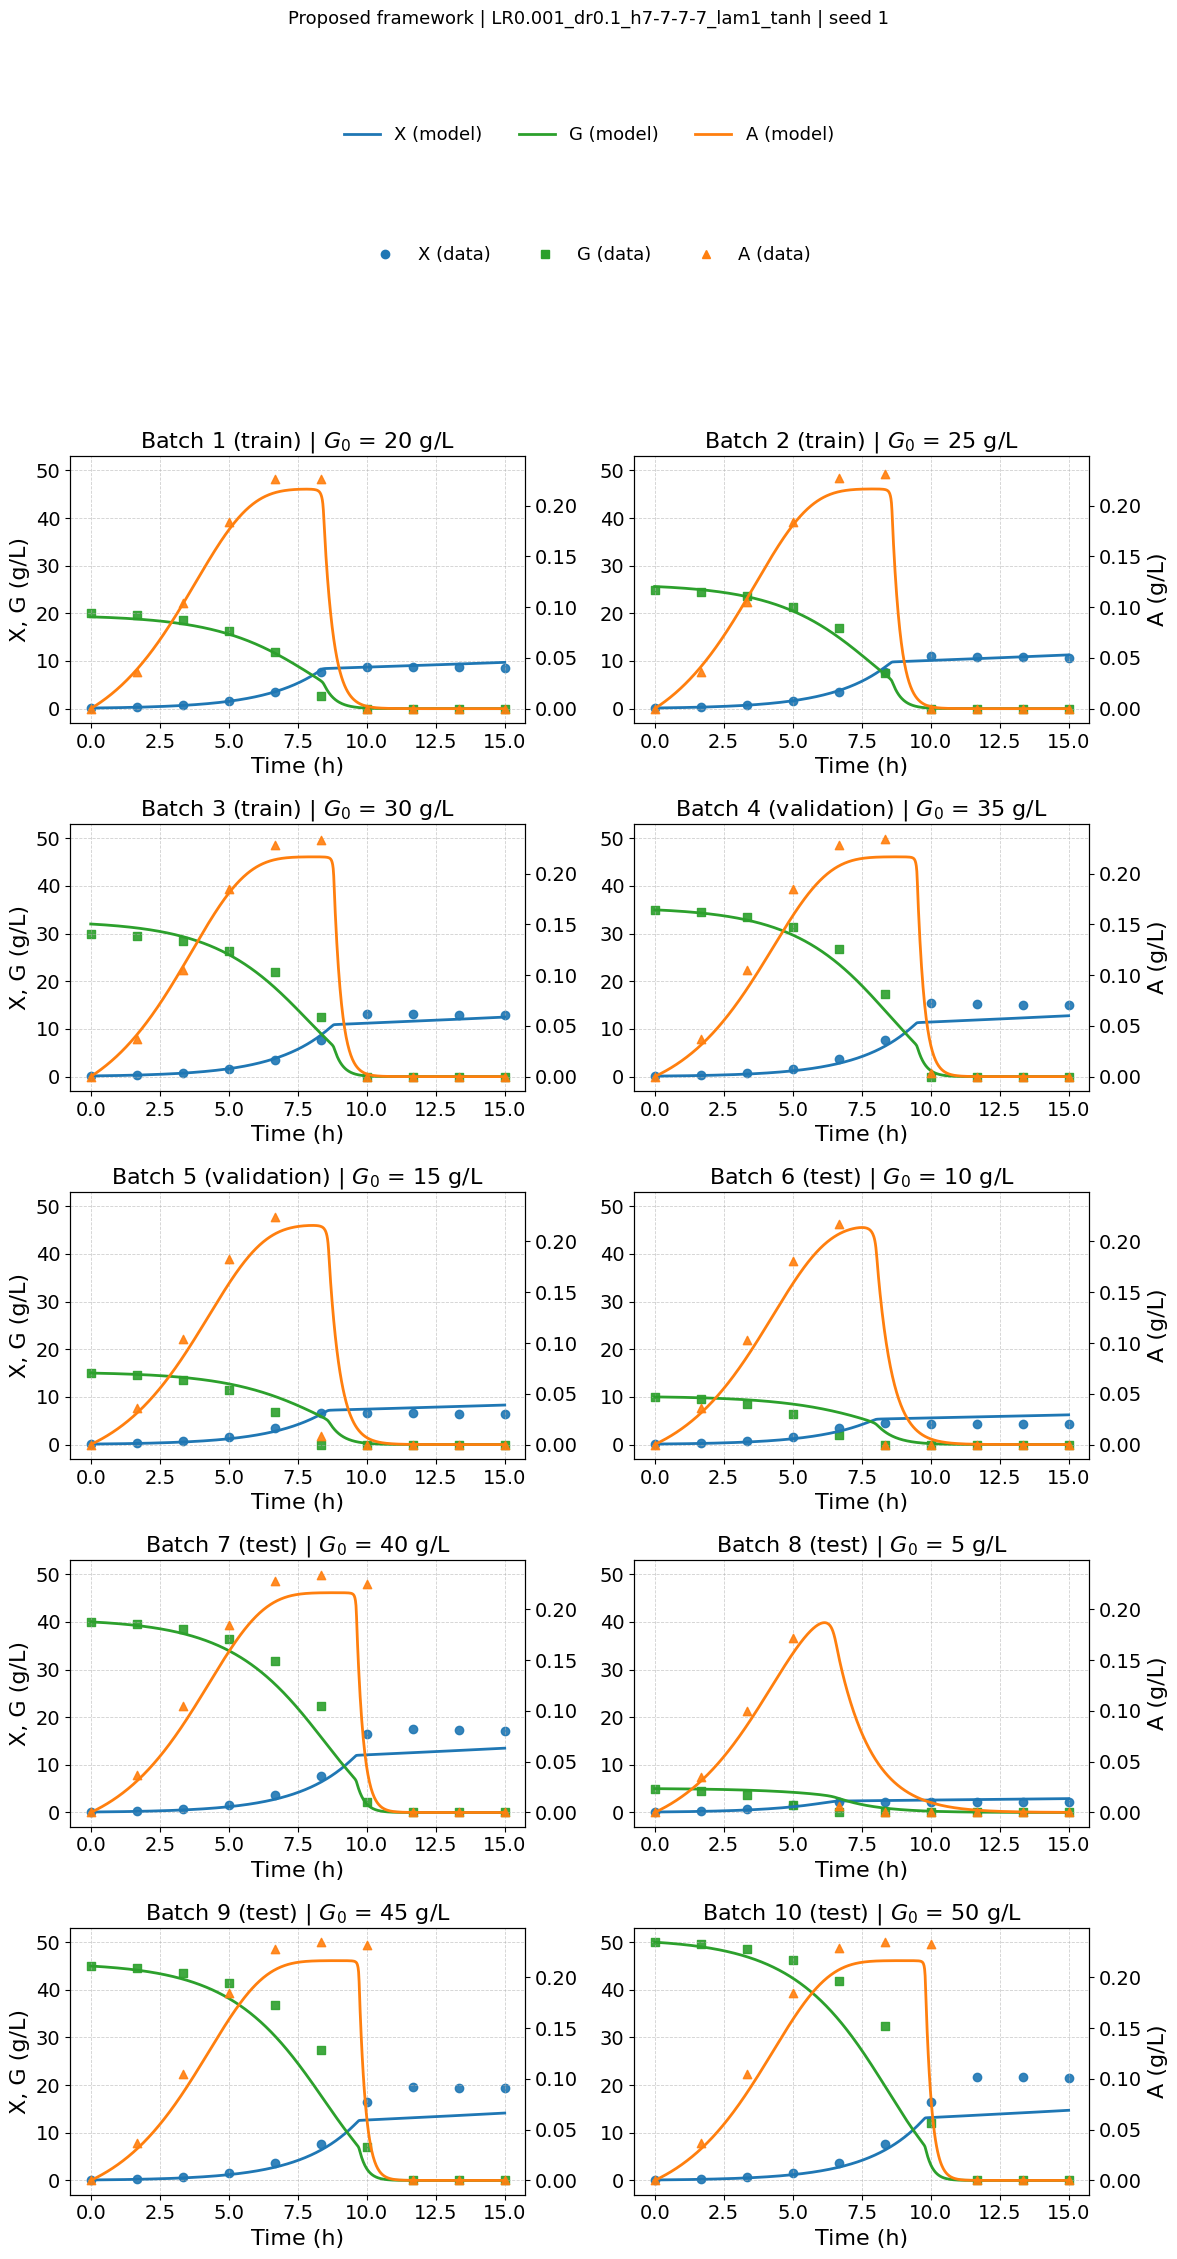

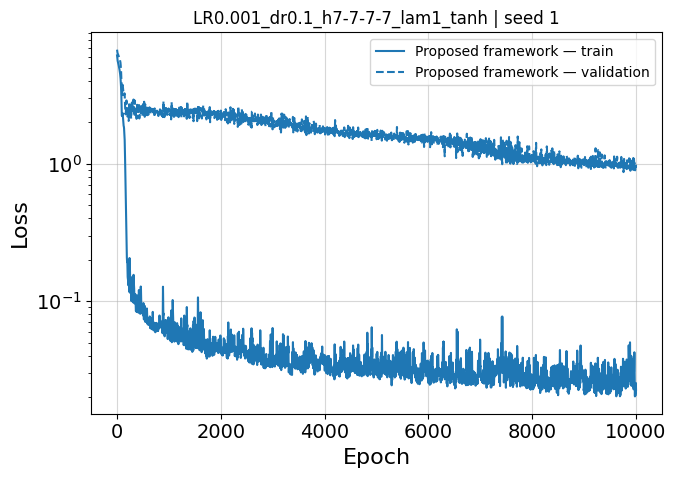

   [progress] 8/8 configs | 256.8 min | ETA 0.0 min

Sweep finished in 256.8 min.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.9/250.9 kB 9.7 MB/s eta 0:00:00

PROPOSED FRAMEWORK  (8 runs, 0 diverged)
Best 5 configurations by mean validation loss across seeds:
       LR   drop     hidden    act   n     val_mean      val_std
  1.0e-02   0.10          5   tanh   1   1.7481e-01   0.0000e+00
  1.0e-02   0.10      7-7-7   tanh   1   1.7978e-01   0.0000e+00
  1.0e-02   0.10    7-7-7-7   tanh   1   1.8619e-01   0.0000e+00
  1.0e-02   0.10        5-5   tanh   1   5.0932e-01   0.0000e+00
  1.0e-03   0.10          5   tanh   1   8.0180e-01   0.0000e+00

Runs producing a negative concentration: 0 / 8

Excel written to: sweep_results_acetate/sensitivity_proposed.xlsx



Best-run figure (proposed):
  - sweep_results_acetate/traj_best_proposed_LR0.01_dr0.1_h5_lam1_tanh_seed1.png
  - sweep_results_acetate/traj_best_proposed_LR0.01_dr0.1_h5_lam1_tanh_seed1.eps
  - sweep_results_acetate/traj_best_proposed_LR0.01_dr0.1_h5_lam1_tanh_seed1.svg


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# HYPERPARAMETER SWEEP — ACETATE PRODUCTION, HYBRID NEURAL-ODE (single model)
# Paste this whole block into a single Colab cell.
#
# Requires in memory (produced by your data-generation cell):
#     raw_t
#     raw_X, raw_G, raw_A   (clean synthetic data)     -> DATA_SOURCE = "clean"
#     obs_X, obs_G, obs_A   (multiplicative noise)     -> DATA_SOURCE = "noisy"
#
# Structure imposed a priori (the "proposed" framework), 3 states X, G, A:
#
#     dX/dt = f1 X
#     dG/dt = f2 G X
#     dA/dt = (f3 A + g3) X
#     FNN outputs: f1, f2, f3 (free), g3 (>= 0)
#     Mechanistic parameters: none
#
# f1 is linear (must be allowed to go negative -> biomass decay); g3 is passed
# through a ReLU so acetate cannot be created out of nothing. There is a SINGLE
# model here (no mass-balance competitor): the acetate system is Case Study 1.
#
# --------------------------------------------------------------------------
# TWO-STUDY WORKFLOW (this is the whole point of the MC_DROPOUT switch)
#
#   STUDY 1 — exploration.   MC_DROPOUT = False.
#       Sweep the whole GRID_* fast. No stochastic forward passes, so no
#       uncertainty figures. Pick the winning configuration from the Summary /
#       Architecture sheets.
#
#   STUDY 2 — uncertainty.   MC_DROPOUT = True.
#       Narrow GRID_* down to the winner, then re-run. The trained model is
#       simulated MC_SAMPLES times with dropout ACTIVE at inference to produce
#       predictive bands. This is expensive; only switch it on once.
#
# The resume logic keys on (config, seed): rows already in the csv are skipped,
# so raising N_SEEDS or narrowing the grid and re-running only trains what is
# new. (The MC metrics are written into the same row when MC_DROPOUT is on.)
# ============================================================
import importlib.util, subprocess, sys


def _install_dependencies():
    def _has_gpu():
        try:
            return subprocess.run(["nvidia-smi"], capture_output=True).returncode == 0
        except FileNotFoundError:
            return False
    jax_pkg = "jax[cuda12]" if _has_gpu() else "jax"
    print(f"Installing {jax_pkg}, diffrax and optax (first run only)...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-U",
                           jax_pkg, "diffrax", "optax"])


if importlib.util.find_spec("diffrax") is None:
    _install_dependencies()

import os, csv, re, time, pickle, itertools
import numpy as np

# ---- display setting ----
SHOW_PLOTS = True             # True = save AND display inline; False = save only

import matplotlib
# Always render off-screen with Agg. This is robust and immune to the backend-
# switching problem you can hit when toggling SHOW_PLOTS within one session
# (once Agg is active, switching back to the inline backend often no longer
# displays). Inline display is done EXPLICITLY via IPython display(fig), which
# shows the figure in Colab regardless of the active backend.
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def _show_fig(fig):
    """Render a figure inline in Colab, whatever the backend. Safe no-op
    outside IPython."""
    try:
        from IPython.display import display
        display(fig)
    except Exception:
        pass

import jax
import jax.numpy as jnp
from jax import config
from jax.experimental.ode import odeint

try:
    import diffrax
    import optax
except ImportError:
    _install_dependencies()
    raise SystemExit(
        "\n=================================================================\n"
        "Dependencies reinstalled. NOW restart the session:\n"
        "  Runtime -> Restart session\n"
        "and run this same cell again (it will not reinstall anything).\n"
        "=================================================================")

print(f"jax {jax.__version__} | diffrax {diffrax.__version__} | optax {optax.__version__}")
print(f"Backend: {jax.default_backend()} | Devices: {jax.devices()}")
print(f"Matplotlib backend: {matplotlib.get_backend()} | SHOW_PLOTS={SHOW_PLOTS}")

# ========================================================
# (OPTIONAL) FORCE TPU BACKEND
# ========================================================
# WARNING: enable ONLY if the Colab runtime is actually a TPU
# (Runtime -> Change runtime type -> TPU). Forcing "tpu" on a CPU/GPU runtime
# makes JAX try to reach a device that is not there and can appear to FREEZE --
# this is the most likely cause of a hang. Also, XLA_FLAGS is read by JAX at
# initialisation, so setting it here (AFTER `import jax`) has no effect anyway.
# Leave both lines commented unless you are certain you are on a TPU runtime.
# config.update("jax_platform_name", "tpu")
# os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=8"

# ========================================================
# 0. GENERAL SETTINGS
# ========================================================
MODELS = ["proposed"]         # single model (no mass-balance competitor here)

# Which measurements to fit. The acetate data is Case Study 1: clean synthetic
# data, so "clean" is the consistent default. Switch to "noisy" to fit obs_*.
DATA_SOURCE = "clean"         # "clean" -> raw_* ; "noisy" -> obs_*

TRAIN_MODE = "batch"          # "batch" or "global"
NUM_EPOCHS = 10000
EPS = 1.0e-8

SEED_START = 1
N_SEEDS = 1

# NOTE ON SEEDS. Sweep everything at 3 seeds first, then deepen the winning
# configuration to 10 -- a standard deviation over 3 seeds is a rough
# indication, not a number to put in a table. The dispersion across seeds
# (val_std, R2_std in the Summary sheet) is also the evidence of identifiability
# that the reviewers ask for.

# ---------- HYPERPARAMETER GRID  <<<< EDIT HERE >>>> ----------
# Defaults span the reviewer-requested sensitivity range for Case Study 1:
# hidden layers 1-3, neurons 3-8, tanh vs ReLU, dropout in {0, 0.01, 0.1}.
GRID_LR         = [1e-2, 1e-3]
GRID_DROPOUT    = [0.1]
GRID_LAMBDA_IC  = [1.0]
GRID_ACTIVATION = ["tanh"]      # hidden layers only
GRID_HIDDEN     = [[5], [5, 5], [7,7,7], [7,7,7,7]]
# --------------------------------------------------------------
# Only the HIDDEN-layer activation is swept. The output activations are
# structural, not tunable: g3 is passed through a ReLU to stay non-negative,
# and the f_i outputs are linear because f_1 must be able to go negative to
# represent biomass decay.

# --- ODE solver ---
SOLVER = "diffrax"            # "diffrax" (robust for sweeps) or "odeint"
ODE_RTOL = 1e-6
ODE_ATOL = 1e-7
# ODE_MAX_STEPS is a SAFETY CAP, not a target. A healthy trajectory over this
# time span needs only tens of steps; needing thousands means the network is
# producing a stiff/explosive field early in training. With throw=False the
# solver RETURNS (unreached points filled with inf) instead of hanging, and the
# per-epoch divergence guard then aborts that run. So if the sweep feels frozen:
#   - it is almost never this cap (raising it only lets bad runs grind longer);
#   - check the forced-TPU block above (the usual culprit), lower the learning
#     rate, or drop ReLU in favour of tanh for the offending config.
# Lowering the cap makes blow-ups fail faster; raising it does the opposite.
ODE_MAX_STEPS = 4096
ODE_MXSTEP = 2000

# Zero-field pretraining of the network outputs
CALIB_STEPS = 1000
CALIB_LR = 1e-3

DIVERGENCE_THRESHOLD = 1e6

# ---------- MONTE CARLO DROPOUT (uncertainty)  <<<< EDIT HERE >>>> ----------
# STUDY 1: leave this False -> fast sweep, no uncertainty figures.
# STUDY 2: set True on the winning configuration -> predictive bands.
#
# When enabled, the trained model is simulated MC_SAMPLES times with dropout
# ACTIVE at inference. Each sample uses ONE dropout mask held fixed along the
# whole trajectory, exactly as during training. The mean and the lo/hi
# percentiles at each time point give the band. This adds MC_SAMPLES ODE
# integrations per batch per run, so it is meant for a handful of already-
# selected configurations, not the whole grid.
MC_DROPOUT = False
MC_SAMPLES = 1000              # number of stochastic forward simulations
MC_RATE = None                # None = use the configuration's dropout rate;
                              # a float overrides it. NEEDED when the winning
                              # config has dropout = 0 (clean data often prefers
                              # no dropout): a zero rate produces no variability,
                              # so set e.g. MC_RATE = 0.05 for the UQ pass and
                              # report that choice in the manuscript.
MC_CI = 95.0                  # width of the reported interval, in percent

# Dataset splits  <<<< YOU WILL FINALISE THESE >>>>
# initial_glucose = [10, 20, 35, 50, 5, 15, 25, 30, 40, 45]
#   index :   0   1   2   3   4   5   6   7   8   9
#   G0    :  10  20  35  50   5  15  25  30  40  45
# Default: train on the interior (G0 20/25/30), keep the extremes for test so
# that the extrapolation batch G0 = 5 (index 4) is held out AND receives an MC
# band (the MC pass now covers train, valid AND test).
train_idxs = [1, 6, 7]        # G0 = 20, 25, 30
valid_idxs = [2, 5]           # G0 = 35, 15
test_idxs  = [0, 8, 4, 9, 3]  # G0 = 10, 40, 5, 45, 50

# Output paths (one csv + one Excel PER MODEL)
OUTDIR = "sweep_results_acetate"
PLOTDIR = os.path.join(OUTDIR, "run_plots")
PARAMDIR = os.path.join(OUTDIR, "params")
for _d in (OUTDIR, PLOTDIR, PARAMDIR):
    os.makedirs(_d, exist_ok=True)


def csv_path(model):
    return os.path.join(OUTDIR, f"sweep_runs_{model}.csv")


def xlsx_path(model):
    return os.path.join(OUTDIR, f"sensitivity_{model}.xlsx")


PLOT_EACH_RUN = True          # trajectory figure after every run
PLOT_LOSS_CURVES = True       # loss figure after every run
VECTOR_FOR_BEST = True        # EPS + SVG for the overall best run
SAVE_PARAMS = True            # pickle the best parameters of every run

CONFIGS = list(itertools.product(GRID_LR, GRID_DROPOUT, GRID_HIDDEN,
                                 GRID_LAMBDA_IC, GRID_ACTIVATION))
MAX_CONFIGS = None            # e.g. 2 for a smoke test; None = all

# ========================================================
# 1. DATA PREP
# ========================================================
if DATA_SOURCE == "noisy":
    _srcX, _srcG, _srcA = obs_X, obs_G, obs_A
elif DATA_SOURCE == "clean":
    _srcX, _srcG, _srcA = raw_X, raw_G, raw_A
else:
    raise ValueError("DATA_SOURCE must be 'clean' or 'noisy'")

t_batches = [jax.device_put(jnp.array(a)) for a in raw_t]
X_batches = [jax.device_put(jnp.array(a)) for a in _srcX]
G_batches = [jax.device_put(jnp.array(a)) for a in _srcG]
A_batches = [jax.device_put(jnp.array(a)) for a in _srcA]


def _subset(idxs):
    return ([t_batches[i] for i in idxs], [X_batches[i] for i in idxs],
            [G_batches[i] for i in idxs], [A_batches[i] for i in idxs])


t_train, X_train, G_train, A_train = _subset(train_idxs)
t_valid, X_valid, G_valid, A_valid = _subset(valid_idxs)
t_test,  X_test,  G_test,  A_test  = _subset(test_idxs)

N_STATES = 3
STATE_NAMES = ("X", "G", "A")
N_OBS_TRAIN = int(sum(len(np.array(t)) for t in t_train) * N_STATES)

# ========================================================
# 1.1 MODEL REGISTRY
# ========================================================
MODEL_SPECS = {
    "proposed": dict(
        label="Proposed framework",
        n_outputs=4,                       # f1, f2, f3, g3
        output_names=("f1", "f2", "f3", "g3"),
        mech_names=(),
    ),
}


def n_outputs_of(model):
    return MODEL_SPECS[model]["n_outputs"]


# ========================================================
# 1.2 START-UP BANNER
# ========================================================
def _n_weights(hidden, n_in, n_out):
    sizes = [n_in] + list(hidden) + [n_out]
    return sum(sizes[i + 1] * sizes[i] + sizes[i + 1] for i in range(len(sizes) - 1))


print("\n" + "=" * 78)
print("FULL SWEEP: " + " x ".join([
    f"{len(GRID_LR)} LR", f"{len(GRID_DROPOUT)} dropout",
    f"{len(GRID_HIDDEN)} arch", f"{len(GRID_LAMBDA_IC)} lambda",
    f"{len(GRID_ACTIVATION)} activation"]) + f" = {len(CONFIGS)} configurations")
print(f"Models: {', '.join(MODELS)} | seeds: {N_SEEDS} | "
      f"total trainings: {len(CONFIGS) * N_SEEDS * len(MODELS)}")
print(f"Data source: {DATA_SOURCE} | MC dropout: {'ON' if MC_DROPOUT else 'OFF'}")
print("-" * 78)
print(f"Training measurements: {N_OBS_TRAIN} "
      f"({len(t_train)} experiments x {N_STATES} state variables)")
for m in MODELS:
    no = n_outputs_of(m)
    print(f"\n  {MODEL_SPECS[m]['label']} ({no} network outputs)")
    print(f"  {'hidden':>14} {'weights':>9} {'obs/param':>11}")
    for _h in GRID_HIDDEN:
        _nw = _n_weights(_h, N_STATES, no)
        print(f"  {'-'.join(map(str, _h)):>14} {_nw:>9} {N_OBS_TRAIN / _nw:>11.2f}")
print("=" * 78 + "\n")

# ========================================================
# 1.3 Helpers
# ========================================================
def count_params_pytree(pytree):
    leaves, _ = jax.tree_util.tree_flatten(pytree)
    total = 0
    for l in leaves:
        if isinstance(l, (np.ndarray, jnp.ndarray)):
            total += int(np.prod(np.array(l.shape)))
        else:
            total += 1
    return total


def arch_string(layer_sizes):
    return "-".join(str(n) for n in layer_sizes)


def pytree_snapshot_to_cpu(pytree):
    return jax.tree_util.tree_map(lambda x: np.array(x), pytree)


def ensure_dir(p):
    os.makedirs(p, exist_ok=True)


# ========================================================
# 2. NEURAL NETWORK
# ========================================================
HIDDEN_ACTIVATIONS = {
    "tanh": jnp.tanh,
    "relu": jax.nn.relu,
    "softplus": jax.nn.softplus,
}


def init_net_params(rng_key, layer_sizes):
    params = {}
    keys = jax.random.split(rng_key, 2 * (len(layer_sizes) - 1))
    k = 0
    for i in range(len(layer_sizes) - 1):
        n_in, n_out = layer_sizes[i], layer_sizes[i + 1]
        params[f"W{i}"] = jax.random.uniform(keys[k], (n_out, n_in), minval=-0.1, maxval=0.1)
        params[f"b{i}"] = jax.random.uniform(keys[k + 1], (n_out,), minval=-0.1, maxval=0.1)
        k += 2
    return params


def sample_hidden_masks(net_params, rate, rng):
    if rate is None or rate <= 0.0:
        return None
    keep = 1.0 - rate
    masks = []
    num_layers = len(net_params) // 2
    for i in range(num_layers - 1):
        size = net_params[f"b{i}"].shape
        rng, ki = jax.random.split(rng)
        masks.append(jax.random.bernoulli(ki, p=keep, shape=size).astype(jnp.float32) / keep)
    return masks


def neural_network(net_params, y, *, train=False, masks=None, activation="tanh"):
    phi = HIDDEN_ACTIVATIONS[activation]
    a = y
    num_layers = len(net_params) // 2
    for i in range(num_layers):
        W, b = net_params[f"W{i}"], net_params[f"b{i}"]
        z = W @ a + b
        if i < num_layers - 1:
            a = phi(z)
            if train and (masks is not None):
                a = a * masks[i]
        else:
            a = z
    return a


# ========================================================
# 2.1 RIGHT-HAND SIDE
# ========================================================
def model_jax(net_params, y, t, *, model="proposed",
              train=False, masks=None, activation="tanh"):
    X, G, A = y
    out = neural_network(net_params, jnp.array([X, G, A]),
                         train=train, masks=masks, activation=activation)
    if model != "proposed":
        raise ValueError(f"unknown model '{model}'")
    f1, f2, f3, g3 = out
    g3c = jax.nn.relu(g3)
    return jnp.stack([
        f1 * X,
        f2 * G * X,
        (f3 * A + g3c) * X,
    ])


# ========================================================
# 2.2 PREDICT
# ========================================================
if SOLVER == "diffrax":
    def predict(net_params, t_array, X0, G0, *, A0=0.0,
                model="proposed", train=False, masks=None, activation="tanh"):
        def rhs(t, y, args):
            return model_jax(net_params, y, t, model=model,
                             train=train, masks=masks, activation=activation)
        sol = diffrax.diffeqsolve(
            diffrax.ODETerm(rhs), diffrax.Tsit5(),
            t0=t_array[0], t1=t_array[-1], dt0=None,
            y0=jnp.array([X0, G0, A0]),
            saveat=diffrax.SaveAt(ts=t_array),
            stepsize_controller=diffrax.PIDController(rtol=ODE_RTOL, atol=ODE_ATOL),
            max_steps=ODE_MAX_STEPS,
            adjoint=diffrax.RecursiveCheckpointAdjoint(),
            throw=False,
        )
        ys = sol.ys
        return ys[:, 0], ys[:, 1], ys[:, 2]
elif SOLVER == "odeint":
    def predict(net_params, t_array, X0, G0, *, A0=0.0,
                model="proposed", train=False, masks=None, activation="tanh"):
        def rhs(y, tt):
            return model_jax(net_params, y, tt, model=model,
                             train=train, masks=masks, activation=activation)
        sol = odeint(rhs, jnp.array([X0, G0, A0]), t_array,
                     rtol=ODE_RTOL, atol=ODE_ATOL, mxstep=ODE_MXSTEP)
        return sol[:, 0], sol[:, 1], sol[:, 2]
else:
    raise ValueError("SOLVER must be 'diffrax' or 'odeint'")

predict = jax.jit(predict, static_argnames=("model", "train", "activation"))


# ========================================================
# 2.3 INITIAL CONDITIONS VIA LOG-OFFSETS
# ========================================================
def init_ic_offset_params_from_data(X_train, G_train):
    n = len(X_train)
    X0_meas = jnp.array([float(np.array(X_train[i])[0]) for i in range(n)])
    G0_meas = jnp.array([float(np.array(G_train[i])[0]) for i in range(n)])
    return ({"alpha_X": jnp.zeros_like(X0_meas), "alpha_G": jnp.zeros_like(G0_meas)},
            {"X0": X0_meas, "G0": G0_meas})


def ic_for_train_batch(params, idx):
    X0 = params["ic_meas"]["X0"][idx] * jnp.exp(params["ic_alpha"]["alpha_X"][idx])
    G0 = params["ic_meas"]["G0"][idx] * jnp.exp(params["ic_alpha"]["alpha_G"][idx])
    return X0, G0, jnp.array(0.0)


# ========================================================
# 3. LOSSES
# ========================================================
def safe_rel(pred, obs):
    return (pred - obs) / jnp.maximum(jnp.mean(jnp.abs(obs)), EPS)


def _mse3(Xp, Gp, Ap, Xo, Go, Ao):
    return (jnp.mean(safe_rel(Xp, Xo) ** 2) + jnp.mean(safe_rel(Gp, Go) ** 2) +
            jnp.mean(safe_rel(Ap, Ao) ** 2))


def make_losses(model, dropout_rate, lambda_ic, activation):
    """Losses closed over THIS model and configuration, so jit never reuses a
    graph compiled with different settings."""

    def batch_loss_train(params, idx, rng):
        X0, G0, A0 = ic_for_train_batch(params, idx)
        masks = sample_hidden_masks(params["net"], dropout_rate, rng)
        Xp, Gp, Ap = predict(params["net"], t_train[idx], X0, G0, A0=A0,
                             model=model, train=True, masks=masks,
                             activation=activation)
        data_loss = _mse3(Xp, Gp, Ap,
                          X_train[idx], G_train[idx], A_train[idx])
        reg = lambda_ic * (params["ic_alpha"]["alpha_X"][idx] ** 2 +
                           params["ic_alpha"]["alpha_G"][idx] ** 2)
        return data_loss + reg

    batch_loss_train_jit = jax.jit(batch_loss_train, static_argnums=(1,))

    def global_train_loss(params, rng_key):
        total = 0.0
        for idx in range(len(t_train)):
            total += batch_loss_train(params, idx, jax.random.fold_in(rng_key, idx))
        return total / len(t_train)

    def batch_loss_train_eval(params, idx):
        X0, G0, A0 = ic_for_train_batch(params, idx)
        Xp, Gp, Ap = predict(params["net"], t_train[idx], X0, G0, A0=A0,
                             model=model, train=False, masks=None,
                             activation=activation)
        return _mse3(Xp, Gp, Ap,
                     X_train[idx], G_train[idx], A_train[idx])

    batch_loss_train_eval_jit = jax.jit(batch_loss_train_eval, static_argnums=(1,))

    def loss_heldout(net, t_o, X_o, G_o, A_o):
        Xp, Gp, Ap = predict(net, t_o, X_o[0], G_o[0], A0=0.0,
                             model=model, train=False, masks=None,
                             activation=activation)
        return _mse3(Xp, Gp, Ap, X_o, G_o, A_o)

    loss_heldout_jit = jax.jit(loss_heldout)

    return (batch_loss_train_jit, global_train_loss,
            batch_loss_train_eval_jit, loss_heldout_jit)


# ========================================================
# 3.1 R^2 AND NON-NEGATIVITY DIAGNOSTICS
# ========================================================
def _r2(obs, pred):
    """R^2 of one variable in one experiment. NaN when undefined; negative
    values are legitimate and kept."""
    obs = np.asarray(obs, float).ravel()
    pred = np.asarray(pred, float).ravel()
    n = min(obs.size, pred.size)
    obs, pred = obs[:n], pred[:n]
    mask = np.isfinite(obs) & np.isfinite(pred)
    if mask.sum() < 2:
        return np.nan
    o, p = obs[mask], pred[mask]
    ss_tot = float(np.sum((o - o.mean()) ** 2))
    if ss_tot <= 0.0:
        return np.nan
    return float(1.0 - np.sum((o - p) ** 2) / ss_tot)


def evaluate_run(best_params, model, activation="tanh"):
    """R^2 per state variable and per experiment, plus the minimum concentration
    reached along each simulated trajectory.

    The minima are the empirical counterpart of the non-negativity proposition:
    the proposed formulation cannot produce negative states.
    """
    flat = {}
    if best_params is None:
        return flat

    net = jax.tree_util.tree_map(jnp.asarray, best_params["net"])
    ic_alpha = jax.tree_util.tree_map(jnp.asarray, best_params["ic_alpha"])
    ic_meas = jax.tree_util.tree_map(jnp.asarray, best_params["ic_meas"])

    blocks = [
        ("train", train_idxs, t_train, X_train, G_train, A_train, True),
        ("valid", valid_idxs, t_valid, X_valid, G_valid, A_valid, False),
        ("test",  test_idxs,  t_test,  X_test,  G_test,  A_test,  False),
    ]

    global_min = {v: np.inf for v in STATE_NAMES}

    for split, idxs, T, Xs, Gs, As, learned_ic in blocks:
        pooled = {v: ([], []) for v in STATE_NAMES}
        for i in range(len(T)):
            if learned_ic:
                X0 = float(ic_meas["X0"][i] * jnp.exp(ic_alpha["alpha_X"][i]))
                G0 = float(ic_meas["G0"][i] * jnp.exp(ic_alpha["alpha_G"][i]))
            else:
                X0 = float(np.array(Xs[i])[0])
                G0 = float(np.array(Gs[i])[0])

            # dense grid so the minima are not missed between sampling times
            t_np = np.array(T[i], float)
            t_dense = jnp.linspace(float(t_np.min()), float(t_np.max()), 400)
            dense = predict(net, t_dense, X0, G0, A0=0.0,
                            model=model, train=False, masks=None,
                            activation=activation)
            for v, arr in zip(STATE_NAMES, dense):
                a = np.array(arr, float)
                if np.any(np.isfinite(a)):
                    global_min[v] = min(global_min[v], float(np.nanmin(a)))

            preds = predict(net, T[i], X0, G0, A0=0.0,
                            model=model, train=False, masks=None,
                            activation=activation)
            bidx = int(idxs[i])
            for v, o_arr, p_arr in zip(STATE_NAMES, (Xs[i], Gs[i], As[i]), preds):
                o = np.array(o_arr, float)
                p = np.array(p_arr, float)
                flat[f"r2_{split}_b{bidx}_{v}"] = _r2(o, p)
                pooled[v][0].append(o)
                pooled[v][1].append(p)

        for v in STATE_NAMES:
            if pooled[v][0]:
                flat[f"r2_{split}_{v}"] = _r2(np.concatenate(pooled[v][0]),
                                              np.concatenate(pooled[v][1]))

    for v in STATE_NAMES:
        flat[f"min_{v}"] = (float(global_min[v]) if np.isfinite(global_min[v])
                            else np.nan)
    flat["any_negative_state"] = int(any(
        np.isfinite(flat[f"min_{v}"]) and flat[f"min_{v}"] < -1e-6
        for v in STATE_NAMES))
    return flat


# ========================================================
# 3.2 MONTE CARLO DROPOUT
# ========================================================
def _mc_simulate(net, t_grid, X0, G0, rate, rng, n_samples, model, activation):
    """n_samples stochastic trajectories, one dropout mask each, held fixed
    along the whole integration. Returns an array (n_samples, 3, n_times)."""
    keys = jax.random.split(rng, n_samples)

    def one(key):
        masks = sample_hidden_masks(net, rate, key)
        Xp, Gp, Ap = predict(net, t_grid, X0, G0, A0=0.0,
                             model=model, train=True, masks=masks,
                             activation=activation)
        return jnp.stack([Xp, Gp, Ap])

    return jax.vmap(one)(keys)


def mc_dropout_run(best_params, model, activation, rate, n_samples=MC_SAMPLES,
                   ci=MC_CI, seed=0):
    """Predictive bands for every train, validation AND test batch.

    Returns (panels, metrics). Each panel carries the dense mean/lo/hi curves
    for plotting; the metrics summarise, per split and per state variable, the
    relative width of the band and the fraction of observations it contains.
    """
    if best_params is None or rate is None or rate <= 0.0:
        return [], {}

    net = jax.tree_util.tree_map(jnp.asarray, best_params["net"])
    ic_alpha = jax.tree_util.tree_map(jnp.asarray, best_params["ic_alpha"])
    ic_meas = jax.tree_util.tree_map(jnp.asarray, best_params["ic_meas"])
    lo_q, hi_q = (100.0 - ci) / 2.0, 100.0 - (100.0 - ci) / 2.0

    blocks = [("train", t_train, X_train, G_train, A_train, True),
              ("valid", t_valid, X_valid, G_valid, A_valid, False),
              ("test",  t_test,  X_test,  G_test,  A_test,  False)]
    split_offset = {"train": 0, "valid": 500, "test": 1000}

    panels = []
    acc = {(s, v): {"w": [], "cov": []}
           for s in ("train", "valid", "test") for v in STATE_NAMES}

    for split, T, Xs, Gs, As, learned_ic in blocks:
        for i in range(len(T)):
            if learned_ic:
                X0 = float(ic_meas["X0"][i] * jnp.exp(ic_alpha["alpha_X"][i]))
                G0 = float(ic_meas["G0"][i] * jnp.exp(ic_alpha["alpha_G"][i]))
            else:
                X0 = float(np.array(Xs[i])[0])
                G0 = float(np.array(Gs[i])[0])

            t_obs = np.array(T[i], float)
            t_dense = _dense_time_grid(t_obs)
            rng = jax.random.fold_in(jax.random.PRNGKey(seed), i + split_offset[split])
            samples = np.array(_mc_simulate(net, t_dense, X0, G0, rate, rng,
                                            n_samples, model, activation))

            mean = np.nanmean(samples, axis=0)                    # (3, n_times)
            lo = np.nanpercentile(samples, lo_q, axis=0)
            hi = np.nanpercentile(samples, hi_q, axis=0)

            obs = dict(zip(STATE_NAMES, (np.array(Xs[i], float),
                                         np.array(Gs[i], float),
                                         np.array(As[i], float))))
            td = np.array(t_dense, float)
            for j, v in enumerate(STATE_NAMES):
                scale = max(float(np.mean(np.abs(obs[v]))), EPS)
                acc[(split, v)]["w"].append(float(np.mean(hi[j] - lo[j])) / scale)
                lo_o = np.interp(t_obs, td, lo[j])
                hi_o = np.interp(t_obs, td, hi[j])
                inside = (obs[v] >= lo_o - 1e-9) & (obs[v] <= hi_o + 1e-9)
                acc[(split, v)]["cov"].append(float(np.mean(inside)))

            panels.append(dict(split=split, t_obs=t_obs, t_dense=td,
                               mean=mean, lo=lo, hi=hi, obs=obs,
                               G0=int(round(float(obs["G"][0]))), role=split))

    metrics = {"mc_samples": int(n_samples), "mc_rate": float(rate),
               "mc_ci": float(ci)}
    for (split, v), d in acc.items():
        if d["w"]:
            metrics[f"mc_relwidth_{split}_{v}"] = float(np.mean(d["w"]))
            metrics[f"mc_coverage_{split}_{v}"] = float(np.mean(d["cov"]))
    return panels, metrics


def plot_mc_bands(panels, model, tag, seed, outdir=PLOTDIR, show=False,
                  vector=False):
    """Mean trajectory and predictive band for every batch. X and G on the left
    axis, A on the right axis."""
    if not panels:
        return []
    n = len(panels)
    ncols = 2 if n > 1 else 1
    nrows = int(np.ceil(n / ncols))
    colors = dict(zip(STATE_NAMES, (COL_X, COL_G, COL_A)))
    markers = dict(zip(STATE_NAMES, ('o', 's', '^')))

    with plt.rc_context(_PLOT_RC):
        fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows),
                                 squeeze=False)
        axes = axes.ravel()
        for i, e in enumerate(panels):
            ax1 = axes[i]
            ax2 = ax1.twinx()
            for j, v in enumerate(STATE_NAMES):
                ax = ax2 if v == "A" else ax1
                ax.plot(e["t_dense"], e["mean"][j], "-", color=colors[v], lw=2)
                ax.fill_between(e["t_dense"], e["lo"][j], e["hi"][j],
                                color=colors[v], alpha=0.18, linewidth=0)
                ax.scatter(e["t_obs"], e["obs"][v], marker=markers[v],
                           color=colors[v], alpha=0.9, zorder=3)
            ax1.set_title(f"Batch {i+1} ({e['role']}) | $G_0$ = {e['G0']} g/L")
            if i % ncols == 0:
                ax1.set_ylabel("X, G (g/L)")
            if i % ncols == ncols - 1:
                ax2.set_ylabel("A (g/L)")
            ax1.set_xlabel("Time (h)")
            ax1.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)
        for j in range(n, len(axes)):
            axes[j].axis("off")

        handles = [Line2D([0], [0], color=colors[v], lw=2, label=v) for v in STATE_NAMES]
        fig.legend(handles=handles, loc='upper center', ncol=len(STATE_NAMES),
                   frameon=False, bbox_to_anchor=(0.5, 1.04))
        fig.suptitle(f"{MODEL_SPECS[model]['label']} — MC dropout, "
                     f"{MC_SAMPLES} samples, {MC_CI:g}% interval\n{tag} | seed {seed}",
                     y=1.14, fontsize=12)
        fig.tight_layout(rect=[0, 0, 1, 0.95])

        ensure_dir(outdir)
        base = os.path.join(outdir, f"mc_{model}_{tag}_seed{seed}")
        saved = [base + ".png"]
        fig.savefig(saved[0], dpi=150, bbox_inches="tight")
        if vector:
            for ext in ("eps", "svg"):
                fig.savefig(f"{base}.{ext}", format=ext, dpi=600, bbox_inches="tight")
                saved.append(f"{base}.{ext}")
        if show:
            _show_fig(fig)
        plt.close(fig)
    return saved


# ========================================================
# 4. ZERO-FIELD PRETRAINING
# ========================================================
def calib_loss(net_params, points, n_out, activation="tanh"):
    target = jnp.zeros(n_out)

    def per_point(y):
        return jnp.mean((neural_network(net_params, y, train=False,
                                        activation=activation) - target) ** 2)
    return jnp.mean(jax.vmap(per_point)(points))


def calibrate_with_data(net_params, points, n_out, steps=CALIB_STEPS,
                        lr=CALIB_LR, activation="tanh", verbose=False):
    """Drive the network outputs to zero before training, so the whole vector
    field starts neutral (the model initially predicts no change)."""
    optc = optax.adam(lr)
    opt_state = optc.init(net_params)

    @jax.jit
    def step(p, s):
        loss, grads = jax.value_and_grad(calib_loss)(p, points, n_out, activation)
        updates, s = optc.update(grads, s, p)
        return optax.apply_updates(p, updates), s, loss

    p = net_params
    for i in range(steps):
        p, opt_state, loss = step(p, opt_state)
        if verbose and i % 250 == 0:
            print(f"    [calib] step {i}, loss={loss:.4e}")
    return p


_calib_points = jnp.array([[x, g, a]
                           for Xb, Gb, Ab in zip(X_train, G_train, A_train)
                           for x, g, a in zip(np.array(Xb), np.array(Gb),
                                              np.array(Ab))])

# ========================================================
# 5. PLOTTING
# ========================================================
COL_X, COL_G, COL_A = "#1f77b4", "#2ca02c", "#ff7f0e"
MODEL_LS = {"proposed": "-"}

_PLOT_RC = {
    "font.size": 14, "axes.titlesize": 16, "axes.labelsize": 16,
    "xtick.labelsize": 14, "ytick.labelsize": 14,
    "legend.fontsize": 13, "figure.titlesize": 18,
}


def _dense_time_grid(t_np, n=800, pad_frac=0.0):
    t0, t1 = float(np.min(t_np)), float(np.max(t_np))
    if t1 <= t0:
        t1 = t0 + 1e-6
    span = t1 - t0
    return jnp.linspace(t0 - pad_frac * span, t1 + pad_frac * span, n)


def _with_pad(vmin, vmax, frac=0.06):
    span = vmax - vmin
    if span <= 0:
        base = max(abs(vmin), abs(vmax), 1.0)
        return vmin - base * frac, vmax + base * frac
    return vmin - span * frac, vmax + span * frac


def _simulate_panels(best_params, model, activation):
    """Dense simulation of every training and held-out batch, for plotting."""
    net = jax.tree_util.tree_map(jnp.asarray, best_params["net"])
    ic_alpha = jax.tree_util.tree_map(jnp.asarray, best_params["ic_alpha"])
    ic_meas = jax.tree_util.tree_map(jnp.asarray, best_params["ic_meas"])

    panels = ([(t_train[i], X_train[i], G_train[i], A_train[i], i, "train")
               for i in range(len(t_train))] +
              [(t_valid[i], X_valid[i], G_valid[i], A_valid[i], None, "validation")
               for i in range(len(t_valid))] +
              [(t_test[i], X_test[i], G_test[i], A_test[i], None, "test")
               for i in range(len(t_test))])

    out = []
    for t_b, X_b, G_b, A_b, tr_idx, role in panels:
        t_obs = np.array(t_b)
        X_obs, G_obs, A_obs = np.array(X_b), np.array(G_b), np.array(A_b)
        t_dense = _dense_time_grid(t_obs)
        if tr_idx is not None:
            X0 = float(ic_meas["X0"][tr_idx] * jnp.exp(ic_alpha["alpha_X"][tr_idx]))
            G0 = float(ic_meas["G0"][tr_idx] * jnp.exp(ic_alpha["alpha_G"][tr_idx]))
        else:
            X0, G0 = float(X_obs[0]), float(G_obs[0])
        Xp, Gp, Ap = predict(net, t_dense, X0, G0, A0=0.0,
                             model=model, train=False, masks=None,
                             activation=activation)
        out.append(dict(t_obs=t_obs, t_dense=np.array(t_dense),
                        X_obs=X_obs, G_obs=G_obs, A_obs=A_obs,
                        X_pred=np.array(Xp), G_pred=np.array(Gp),
                        A_pred=np.array(Ap),
                        G0=int(round(float(G_obs[0]))), role=role))
    return out


def _axis_limits(all_panels):
    left, right = [], []
    for panels in all_panels:
        for e in panels:
            left += [e["X_obs"], e["G_obs"], e["X_pred"], e["G_pred"]]
            right += [e["A_obs"], e["A_pred"]]
    f = lambda arrs, fn: fn([fn(a[np.isfinite(a)]) if np.any(np.isfinite(a)) else 0.0
                             for a in arrs])
    return (_with_pad(f(left, np.min), f(left, np.max)),
            _with_pad(f(right, np.min), f(right, np.max)))


def plot_trajectories(panels_by_model, tag, seed, outdir=PLOTDIR,
                      vector=False, show=False, suffix=""):
    """One figure with all batches. X and G on the left axis, A on the right."""
    models = list(panels_by_model)
    if not models:
        return []
    n_panels = len(panels_by_model[models[0]])
    if n_panels == 0:
        return []

    (left_lo, left_hi), (right_lo, right_hi) = _axis_limits(panels_by_model.values())
    ncols = 2 if n_panels > 1 else 1
    nrows = int(np.ceil(n_panels / ncols))

    with plt.rc_context(_PLOT_RC):
        fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows),
                                 squeeze=False)
        axes = axes.ravel()

        for i in range(n_panels):
            ax1 = axes[i]
            ax2 = ax1.twinx()
            ax1.set_ylim(left_lo, left_hi)
            ax2.set_ylim(right_lo, right_hi)

            for m in models:
                e = panels_by_model[m][i]
                ls = MODEL_LS.get(m, "-")
                ax1.plot(e["t_dense"], e["X_pred"], ls, color=COL_X, lw=2)
                ax1.plot(e["t_dense"], e["G_pred"], ls, color=COL_G, lw=2)
                ax2.plot(e["t_dense"], e["A_pred"], ls, color=COL_A, lw=2)

            e = panels_by_model[models[0]][i]
            ax1.scatter(e["t_obs"], e["X_obs"], marker='o', color=COL_X, alpha=0.9)
            ax1.scatter(e["t_obs"], e["G_obs"], marker='s', color=COL_G, alpha=0.9)
            ax2.scatter(e["t_obs"], e["A_obs"], marker='^', color=COL_A, alpha=0.9)

            ax1.set_title(f"Batch {i+1} ({e['role']}) | $G_0$ = {e['G0']} g/L")
            if i % ncols == 0:
                ax1.set_ylabel("X, G (g/L)")
            if i % ncols == ncols - 1:
                ax2.set_ylabel("A (g/L)")
            ax1.set_xlabel("Time (h)")
            ax1.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)

        for j in range(n_panels, len(axes)):
            axes[j].axis("off")

        legend_state = [Line2D([0], [0], color=c, lw=2, label=f"{n} (model)")
                        for n, c in zip(STATE_NAMES, (COL_X, COL_G, COL_A))]
        legend_data = [Line2D([0], [0], color=c, marker=mk, lw=0, label=f"{n} (data)")
                       for n, c, mk in zip(STATE_NAMES,
                                           (COL_X, COL_G, COL_A),
                                           ('o', 's', '^'))]
        fig.legend(handles=legend_state, loc='upper center', ncol=3,
                   frameon=False, bbox_to_anchor=(0.5, 1.08))
        fig.legend(handles=legend_data, loc='upper center', ncol=3,
                   frameon=False, bbox_to_anchor=(0.5, 1.02))
        fig.suptitle(f"{MODEL_SPECS[models[0]]['label']} | {tag} | seed {seed}",
                     y=1.13, fontsize=13)
        fig.tight_layout(rect=[0, 0, 1, 0.95])

        ensure_dir(outdir)
        base = os.path.join(outdir, f"traj{suffix}_{tag}_seed{seed}")
        saved = [base + ".png"]
        fig.savefig(saved[0], dpi=150, bbox_inches="tight")
        if vector:
            for ext in ("eps", "svg"):
                fig.savefig(f"{base}.{ext}", format=ext, dpi=600, bbox_inches="tight")
                saved.append(f"{base}.{ext}")
        if show:
            _show_fig(fig)
        plt.close(fig)
    return saved


def plot_losses(histories, tag, seed, outdir=PLOTDIR, show=False):
    """Training and validation loss on a single figure."""
    if not histories:
        return None
    with plt.rc_context(_PLOT_RC):
        fig = plt.figure(figsize=(7, 5))
        colors = {"proposed": "#1f77b4"}
        for m, (tr, va) in histories.items():
            if len(tr) == 0:
                continue
            ep = np.arange(1, len(tr) + 1)
            c = colors.get(m, None)
            plt.plot(ep, tr, "-", color=c, lw=1.5,
                     label=f"{MODEL_SPECS[m]['label']} — train")
            plt.plot(ep, va, "--", color=c, lw=1.5,
                     label=f"{MODEL_SPECS[m]['label']} — validation")
        plt.yscale("log")
        plt.xlabel("Epoch"); plt.ylabel("Loss")
        plt.title(f"{tag} | seed {seed}", fontsize=12)
        plt.legend(fontsize=10); plt.grid(True, alpha=0.5); plt.tight_layout()
        ensure_dir(outdir)
        path = os.path.join(outdir, f"loss_{tag}_seed{seed}.png")
        fig.savefig(path, dpi=150)
        if show:
            _show_fig(fig)
        plt.close(fig)
    return path


# ========================================================
# 6. SINGLE TRAINING (one model, one configuration, one seed)
# ========================================================
def train_one(model, seed, lr, dropout, hidden, lambda_ic, activation):
    spec = MODEL_SPECS[model]
    layer_sizes = [N_STATES] + list(hidden) + [spec["n_outputs"]]
    tag = (f"LR{lr:g}_dr{dropout:g}_h{'-'.join(map(str, hidden))}"
           f"_lam{lambda_ic:g}_{activation}")

    rng_master = jax.random.PRNGKey(seed)
    np.random.seed(seed)
    t0_cpu, t0_wall = time.process_time(), time.perf_counter()

    net_params = init_net_params(jax.random.fold_in(rng_master, 0), layer_sizes)
    net_params = calibrate_with_data(net_params, _calib_points, spec["n_outputs"],
                                     activation=activation)
    n_net_params = count_params_pytree(net_params)

    ic_alpha, ic_meas = init_ic_offset_params_from_data(X_train, G_train)
    params = {"net": net_params, "ic_alpha": ic_alpha, "ic_meas": ic_meas}

    (batch_loss_train_jit, global_train_loss,
     batch_loss_train_eval_jit, loss_heldout_jit) = make_losses(
        model, dropout, lambda_ic, activation)

    def eval_avg_train_loss(p):
        v = [float(batch_loss_train_eval_jit(p, i)) for i in range(len(t_train))]
        return float(np.mean(v)) if v else np.nan

    def eval_split(net, T, Xs, Gs, As):
        v = [float(loss_heldout_jit(net, T[i], Xs[i], Gs[i], As[i]))
             for i in range(len(T))]
        return (float(np.mean(v)) if v else np.nan), v

    def _blown_up(tr, va):
        return (not (np.isfinite(tr) and np.isfinite(va))
                or tr > DIVERGENCE_THRESHOLD or va > DIVERGENCE_THRESHOLD)

    opt = optax.adam(lr)
    opt_state = opt.init(params)

    train_history, valid_history = [], []
    best_val, best_epoch, best_params = np.inf, None, None
    diverged = False

    if TRAIN_MODE == "batch":
        def train_step(params, opt_state, idx, rng):
            grads = jax.grad(batch_loss_train_jit)(params, idx, rng)
            updates, opt_state = opt.update(grads, opt_state, params)
            return optax.apply_updates(params, updates), opt_state
        train_step = jax.jit(train_step, static_argnums=(2,))

        for epoch in range(1, NUM_EPOCHS + 1):
            epoch_key = jax.random.fold_in(rng_master, epoch)
            perm = np.array(jax.random.permutation(epoch_key, len(t_train)))
            for idx in perm:
                params, opt_state = train_step(
                    params, opt_state, int(idx),
                    jax.random.fold_in(epoch_key, int(idx)))

            tr = eval_avg_train_loss(params)
            va, _ = eval_split(params["net"], t_valid, X_valid, G_valid, A_valid)
            train_history.append(tr); valid_history.append(va)

            if _blown_up(tr, va):
                diverged = True
                print(f"        ep {epoch}: DIVERGED -> aborted")
                break
            if va < best_val:
                best_val, best_epoch = float(va), epoch
                best_params = pytree_snapshot_to_cpu(params)
            if epoch % 400 == 0:
                print(f"        ep {epoch}: train={tr:.6f}, valid={va:.6f}")

    elif TRAIN_MODE == "global":
        # jax.grad deliberately NOT jitted here (TPU compiler issue).
        for epoch in range(1, NUM_EPOCHS + 1):
            epoch_key = jax.random.fold_in(rng_master, epoch)
            grads = jax.grad(global_train_loss)(params, epoch_key)
            updates, opt_state = opt.update(grads, opt_state, params)
            params = optax.apply_updates(params, updates)

            tr = eval_avg_train_loss(params)
            va, _ = eval_split(params["net"], t_valid, X_valid, G_valid, A_valid)
            train_history.append(tr); valid_history.append(va)

            if _blown_up(tr, va):
                diverged = True
                print(f"        ep {epoch}: DIVERGED -> aborted")
                break
            if va < best_val:
                best_val, best_epoch = float(va), epoch
                best_params = pytree_snapshot_to_cpu(params)
            if epoch % 400 == 0:
                print(f"        ep {epoch}: train={tr:.6f}, valid={va:.6f}")
    else:
        raise ValueError("TRAIN_MODE must be 'batch' or 'global'")

    cpu_time_s = time.process_time() - t0_cpu
    wall_time_s = time.perf_counter() - t0_wall
    train_history = np.array(train_history, float)
    valid_history = np.array(valid_history, float)

    diag = evaluate_run(best_params, model, activation=activation)

    # ---- Monte Carlo dropout (optional, expensive) ----
    mc_metrics = {}
    if MC_DROPOUT and best_params is not None:
        rate = MC_RATE if MC_RATE is not None else dropout
        if rate is None or rate <= 0.0:
            print("        MC dropout skipped: the rate is zero, so the forward "
                  "passes would be deterministic. Set MC_RATE to a positive "
                  "value to sample anyway.")
        else:
            t_mc = time.perf_counter()
            mc_panels, mc_metrics = mc_dropout_run(
                best_params, model, activation, rate,
                n_samples=MC_SAMPLES, ci=MC_CI, seed=seed)
            if mc_panels:
                plot_mc_bands(mc_panels, model, tag, seed, show=SHOW_PLOTS)
                cov = [mc_metrics.get(f"mc_coverage_test_{v}", np.nan)
                       for v in STATE_NAMES]
                cov = [c for c in cov if np.isfinite(c)]
                print(f"        MC dropout: {MC_SAMPLES} samples at rate "
                      f"{rate:g} in {time.perf_counter()-t_mc:.0f}s"
                      + (f" | mean test coverage {100*np.mean(cov):.0f}%"
                         if cov else ""))

    if SAVE_PARAMS and best_params is not None:
        ensure_dir(PARAMDIR)
        with open(os.path.join(PARAMDIR, f"{model}_{tag}_seed{seed}.pkl"), "wb") as fh:
            pickle.dump({"params": best_params, "model": model, "tag": tag,
                         "seed": seed, "layer_sizes": layer_sizes,
                         "activation": activation, "data_source": DATA_SOURCE}, fh)

    test_mean, test_per_batch, ic_dev = np.nan, [np.nan] * len(t_test), np.nan
    if best_params is not None:
        if len(t_test):
            bn = jax.tree_util.tree_map(jnp.asarray, best_params["net"])
            test_mean, test_per_batch = eval_split(bn, t_test, X_test, G_test, A_test)
        aX = np.array(best_params["ic_alpha"]["alpha_X"])
        aG = np.array(best_params["ic_alpha"]["alpha_G"])
        ic_dev = float(np.sqrt(np.mean(aX ** 2 + aG ** 2)))

    _clean = lambda x: float(x) if np.isfinite(x) else np.nan
    n_fitted = n_net_params + 2 * len(t_train)

    row = {
        "model": model, "model_label": spec["label"],
        "learning_rate": lr, "dropout": dropout,
        "hidden_layers": "-".join(map(str, hidden)), "lambda_IC": lambda_ic,
        "activation": activation, "architecture": arch_string(layer_sizes),
        "n_net_parameters": n_net_params,
        "n_fitted_parameters": n_fitted,
        "n_obs_train": N_OBS_TRAIN,
        "obs_per_parameter": round(N_OBS_TRAIN / n_net_params, 3),
        "seed": seed,
        "diverged": int(diverged), "epochs_completed": len(train_history),
        "best_epoch": best_epoch, "best_validation_loss": _clean(best_val),
        "train_loss_at_best": _clean(train_history[best_epoch - 1]) if best_epoch else np.nan,
        "test_loss_at_best": _clean(test_mean),
        "final_train_loss": _clean(train_history[-1]) if train_history.size else np.nan,
        "final_validation_loss": _clean(valid_history[-1]) if valid_history.size else np.nan,
        "ic_deviation_rms": _clean(ic_dev),
        "cpu_time_s": float(cpu_time_s), "wall_time_s": float(wall_time_s),
    }
    for i, v in enumerate(test_per_batch):
        row[f"test_loss_batch_{test_idxs[i]}"] = _clean(v)

    for key in sorted(diag):
        row[key] = _clean(diag[key]) if key != "any_negative_state" else int(diag[key])

    for key in sorted(mc_metrics):
        row[key] = _clean(mc_metrics[key])

    return row, best_params, tag, train_history, valid_history


# ========================================================
# 7. SWEEP (one csv per model, with resume)
# ========================================================
def _csv_append(row, path):
    if os.path.exists(path):
        with open(path) as f:
            header = next(csv.reader(f), None)
        if header:
            missing = [k for k in row if k not in header]
            if missing:
                new_header = header + missing
                with open(path) as f:
                    old = list(csv.DictReader(f))
                with open(path, "w", newline="") as f:
                    w = csv.DictWriter(f, fieldnames=new_header)
                    w.writeheader()
                    for o in old:
                        w.writerow({c: o.get(c, "") for c in new_header})
                header = new_header
            with open(path, "a", newline="") as f:
                csv.DictWriter(f, fieldnames=header).writerow(
                    {c: row.get(c, "") for c in header})
            return
    with open(path, "a", newline="") as f:
        w = csv.DictWriter(f, fieldnames=list(row.keys()))
        w.writeheader(); w.writerow(row)


def _already_done(path):
    done = set()
    if os.path.exists(path):
        with open(path) as f:
            for r in csv.DictReader(f):
                done.add((int(r["seed"]), float(r["learning_rate"]),
                          float(r["dropout"]), r["hidden_layers"],
                          float(r["lambda_IC"]), r.get("activation", "tanh")))
    return done


configs = CONFIGS if MAX_CONFIGS is None else CONFIGS[:MAX_CONFIGS]
done = {m: _already_done(csv_path(m)) for m in MODELS}
for m in MODELS:
    if done[m]:
        print(f"Resuming {m}: {len(done[m])} runs already in {csv_path(m)}")

best_overall = {m: {"best_validation_loss": np.inf} for m in MODELS}
t_sweep0 = time.perf_counter()

for ci, (lr, dropout, hidden, lam, act) in enumerate(configs, 1):
    print("\n" + "=" * 80)
    print(f"[{ci}/{len(configs)}] LR={lr:g} | dropout={dropout:g} | "
          f"hidden={'-'.join(map(str, hidden))} | lambda_IC={lam:g} | act={act}")
    print("=" * 80)

    for k in range(N_SEEDS):
        seed = SEED_START + k
        key = (seed, float(lr), float(dropout), "-".join(map(str, hidden)),
               float(lam), act)
        print(f"   --- seed {seed} ({k+1}/{N_SEEDS}) ---")

        tag = None
        for model in MODELS:
            if key in done[model]:
                print(f"     {model}: already in the csv, skipped")
                continue
            print(f"     {model}:")
            row, bparams, tag, tr_hist, va_hist = train_one(
                model, seed, lr, dropout, list(hidden), lam, act)
            _csv_append(row, csv_path(model))

            if row["diverged"]:
                print(f"     {model}: DIVERGED at epoch {row['epochs_completed']}")
            else:
                neg = " | NEGATIVE STATES" if row.get("any_negative_state") else ""
                print(f"     {model}: val={row['best_validation_loss']:.4e} "
                      f"@ep{row['best_epoch']} | cpu={row['cpu_time_s']:.0f}s{neg}")

            if bparams is not None:
                panels = _simulate_panels(bparams, model, act)
                if PLOT_EACH_RUN:
                    plot_trajectories({model: panels}, tag, seed,
                                      show=SHOW_PLOTS, suffix=f"_{model}")
                if PLOT_LOSS_CURVES:
                    plot_losses({model: (tr_hist, va_hist)}, tag, seed,
                                show=SHOW_PLOTS)

            if (np.isfinite(row["best_validation_loss"]) and
                    row["best_validation_loss"] < best_overall[model]["best_validation_loss"]):
                best_overall[model] = dict(row)
                best_overall[model]["_params"] = bparams
                best_overall[model]["_tag"] = tag
                best_overall[model]["_activation"] = act
                print(f"     --> NEW BEST for {model}: "
                      f"{row['best_validation_loss']:.4e}")

    el = time.perf_counter() - t_sweep0
    print(f"   [progress] {ci}/{len(configs)} configs | {el/60:.1f} min | "
          f"ETA {el/ci*(len(configs)-ci)/60:.1f} min")

print(f"\nSweep finished in {(time.perf_counter()-t_sweep0)/60:.1f} min.")

# ========================================================
# 8. RESULTS AND EXCEL (one workbook per model)
# ========================================================
!pip install openpyxl
import pandas as pd
from openpyxl.styles import Font, Alignment, PatternFill, Border, Side
from openpyxl.utils import get_column_letter

CONFIG_KEYS = ["learning_rate", "dropout", "hidden_layers", "lambda_IC", "activation"]
_R2_BATCH_RE = re.compile(r"^r2_(train|valid|test)_b(\d+)_([XGA])$")
summary_by_model = {}

for model in MODELS:
    path = csv_path(model)
    if not os.path.exists(path):
        print(f"\n[{model}] no results file; skipped")
        continue

    df_runs = pd.read_csv(path)
    if "activation" not in df_runs.columns:
        df_runs["activation"] = "tanh"
    df_runs["activation"] = df_runs["activation"].fillna("tanh")

    test_cols = sorted([c for c in df_runs.columns if c.startswith("test_loss_batch_")],
                       key=lambda c: int(c.rsplit("_", 1)[1]))
    min_cols = [f"min_{v}" for v in STATE_NAMES if f"min_{v}" in df_runs.columns]
    mc_cols = sorted([c for c in df_runs.columns if c.startswith("mc_")])
    r2_pooled = [f"r2_{s}_{v}" for s in ("train", "valid", "test") for v in STATE_NAMES
                 if f"r2_{s}_{v}" in df_runs.columns]
    r2_batch = sorted([c for c in df_runs.columns if _R2_BATCH_RE.match(c)],
                      key=lambda c: (["train", "valid", "test"].index(_R2_BATCH_RE.match(c).group(1)),
                                     int(_R2_BATCH_RE.match(c).group(2)),
                                     list(STATE_NAMES).index(_R2_BATCH_RE.match(c).group(3))))

    col_order = (["model", "model_label"] + CONFIG_KEYS +
                 ["architecture", "n_net_parameters",
                  "n_fitted_parameters", "n_obs_train", "obs_per_parameter", "seed",
                  "diverged", "epochs_completed", "best_epoch",
                  "best_validation_loss", "train_loss_at_best", "test_loss_at_best",
                  "final_train_loss", "final_validation_loss", "ic_deviation_rms",
                  "cpu_time_s", "wall_time_s"] +
                 ["any_negative_state"] + min_cols + mc_cols +
                 test_cols + r2_pooled + r2_batch)
    col_order = [c for c in col_order if c in df_runs.columns]
    df_runs = df_runs[col_order + [c for c in df_runs.columns if c not in col_order]]
    df_runs = df_runs.sort_values(CONFIG_KEYS + ["seed"]).reset_index(drop=True)
    df_ok = df_runs[np.isfinite(df_runs["best_validation_loss"])]

    # --- per-configuration summary ---
    if len(df_ok):
        spec = dict(
            n_seeds=("seed", "count"),
            val_mean=("best_validation_loss", "mean"),
            val_std=("best_validation_loss", "std"),
            val_min=("best_validation_loss", "min"),
            train_mean=("train_loss_at_best", "mean"),
            epoch_median=("best_epoch", "median"),
            cpu_mean=("cpu_time_s", "mean"),
        )
        for c in r2_pooled:
            spec[f"{c}_mean"] = (c, "mean")
            spec[f"{c}_std"] = (c, "std")
        df_summary = df_ok.groupby(CONFIG_KEYS).agg(**spec).reset_index()
        _all = df_runs.groupby(CONFIG_KEYS).size()
        df_summary["n_diverged"] = [
            int(_all.get(tuple(r[k] for k in CONFIG_KEYS), 0) - r["n_seeds"])
            for _, r in df_summary.iterrows()]
        df_summary = df_summary.sort_values("val_mean").reset_index(drop=True)
    else:
        df_summary = pd.DataFrame()

    # --- architecture sensitivity ---
    if len(df_ok):
        aspec = dict(
            n_weights=("n_net_parameters", "first"),
            obs_per_param=("obs_per_parameter", "first"),
            n_seeds=("seed", "count"),
            val_mean=("best_validation_loss", "mean"),
            val_std=("best_validation_loss", "std"),
            val_min=("best_validation_loss", "min"),
            cpu_mean=("cpu_time_s", "mean"),
        )
        df_arch = df_ok.groupby(["hidden_layers", "activation"]).agg(**aspec).reset_index()
        df_arch = df_arch.sort_values(["n_weights", "activation"]).reset_index(drop=True)
    else:
        df_arch = pd.DataFrame()

    # --- tidy R2 ---
    if r2_batch:
        df_r2 = df_runs.melt(id_vars=CONFIG_KEYS + ["seed", "architecture"],
                             value_vars=r2_batch, var_name="_col", value_name="R2")
        parsed = df_r2["_col"].str.extract(_R2_BATCH_RE)
        df_r2["split"] = parsed[0]
        df_r2["batch_index"] = parsed[1].astype(int)
        df_r2["variable"] = parsed[2]
        df_r2 = df_r2.drop(columns=["_col"])
        df_r2 = df_r2[CONFIG_KEYS + ["seed", "architecture", "split",
                                     "batch_index", "variable", "R2"]]
        df_r2 = df_r2.sort_values(CONFIG_KEYS + ["seed", "split", "batch_index",
                                                 "variable"]).reset_index(drop=True)
    else:
        df_r2 = pd.DataFrame()

    # --- Monte Carlo dropout uncertainty ---
    mc_present = [c for c in mc_cols if c.startswith("mc_relwidth_")
                  or c.startswith("mc_coverage_")]
    if mc_present and len(df_ok) and df_ok[mc_present].notna().any().any():
        recs = []
        for split in ("train", "valid", "test"):
            for v in STATE_NAMES:
                w = df_ok.get(f"mc_relwidth_{split}_{v}")
                c = df_ok.get(f"mc_coverage_{split}_{v}")
                if w is None or c is None:
                    continue
                w, c = w.dropna(), c.dropna()
                if not len(w):
                    continue
                recs.append(dict(split=split, variable=v, n_runs=int(len(w)),
                                 rel_band_width_mean=float(w.mean()),
                                 rel_band_width_std=float(w.std(ddof=1)) if len(w) > 1 else 0.0,
                                 coverage_mean=float(c.mean()),
                                 coverage_std=float(c.std(ddof=1)) if len(c) > 1 else 0.0))
        df_unc = pd.DataFrame(recs)
    else:
        df_unc = pd.DataFrame()

    summary_by_model[model] = dict(runs=df_runs, summary=df_summary,
                                   arch=df_arch, unc=df_unc)

    # --- console report ---
    print("\n" + "=" * 100)
    print(f"{MODEL_SPECS[model]['label'].upper()}  ({len(df_runs)} runs, "
          f"{len(df_runs) - len(df_ok)} diverged)")
    print("=" * 100)
    if len(df_summary):
        print("Best 5 configurations by mean validation loss across seeds:")
        print(f"{'LR':>9} {'drop':>6} {'hidden':>10} {'act':>6} {'n':>3} "
              f"{'val_mean':>12} {'val_std':>12}")
        for _, d in df_summary.head(5).iterrows():
            std = d["val_std"] if np.isfinite(d["val_std"]) else 0.0
            print(f"{d['learning_rate']:>9.1e} {d['dropout']:>6.2f} "
                  f"{d['hidden_layers']:>10} {d['activation']:>6} "
                  f"{int(d['n_seeds']):>3} {d['val_mean']:>12.4e} {std:>12.4e}")
    if "any_negative_state" in df_runs.columns:
        n_neg = int(df_runs["any_negative_state"].fillna(0).sum())
        print(f"\nRuns producing a negative concentration: {n_neg} / {len(df_runs)}")

    if len(df_unc):
        print(f"\nMC dropout uncertainty ({MC_CI:g}% interval, "
              f"{MC_SAMPLES} samples):")
        print(f"{'split':>7} {'var':>4} {'runs':>5} {'rel. width':>12} "
              f"{'coverage':>10}")
        for _, d in df_unc.iterrows():
            print(f"{d['split']:>7} {d['variable']:>4} {int(d['n_runs']):>5} "
                  f"{d['rel_band_width_mean']:>12.4f} "
                  f"{100*d['coverage_mean']:>9.0f}%")
        print("  rel. width = mean band width divided by the mean observed value")
        print("  coverage   = fraction of measurements inside the band")

    # --- Excel ---
    protocol = pd.DataFrame({
        "Parameter": ["Model", "Structure", "Network outputs",
                      "Case study", "Data source", "Training mode", "Epochs",
                      "Optimizer", "Seeds per configuration", "Seed range",
                      "Training batches", "Validation batch(es)", "Test batches",
                      "Training measurements", "Architectures explored",
                      "Learning rates swept", "Dropout rates swept",
                      "Hidden activations swept", "ODE solver", "rtol / atol",
                      "Zero-field pretraining (steps / LR)", "Divergence threshold",
                      "Model selection criterion", "MC dropout",
                      "MC samples / interval", "Configurations", "Total runs",
                      "JAX backend"],
        "Value": [model, MODEL_SPECS[model]["label"],
                  ", ".join(MODEL_SPECS[model]["output_names"]),
                  "Acetate (X, G, A)", DATA_SOURCE, TRAIN_MODE, NUM_EPOCHS, "Adam",
                  N_SEEDS, f"{SEED_START}..{SEED_START+N_SEEDS-1}", str(train_idxs),
                  str(valid_idxs), str(test_idxs) if test_idxs else "none",
                  N_OBS_TRAIN,
                  ", ".join("-".join(map(str, h)) for h in GRID_HIDDEN),
                  ", ".join(f"{v:g}" for v in GRID_LR),
                  ", ".join(f"{v:g}" for v in GRID_DROPOUT),
                  ", ".join(GRID_ACTIVATION),
                  "diffrax Tsit5 (adaptive)" if SOLVER == "diffrax" else "jax odeint",
                  f"{ODE_RTOL:g} / {ODE_ATOL:g}", f"{CALIB_STEPS} / {CALIB_LR:g}",
                  f"{DIVERGENCE_THRESHOLD:g}",
                  "Validation loss (early stopping on epoch)",
                  "enabled" if MC_DROPOUT else "disabled",
                  f"{MC_SAMPLES} / {MC_CI:g}%" if MC_DROPOUT else "not applicable",
                  len(configs), len(df_runs), jax.default_backend()],
    })

    sheets = [("Runs", df_runs)]
    if len(df_summary):
        sheets.append(("Summary", df_summary))
    if len(df_arch):
        sheets.append(("Architecture", df_arch))
    if len(df_unc):
        sheets.append(("Uncertainty", df_unc))
    if len(df_r2):
        sheets.append(("R2_long", df_r2))
    sheets.append(("Protocol", protocol))

    with pd.ExcelWriter(xlsx_path(model), engine="openpyxl") as xw:
        for name, df in sheets:
            df.to_excel(xw, sheet_name=name, index=False)

        HDR_FILL = PatternFill("solid", fgColor="1F3864")
        HDR_FONT = Font(name="Arial", bold=True, color="FFFFFF", size=10)
        BODY = Font(name="Arial", size=10)
        BEST = PatternFill("solid", fgColor="D9EAD3")
        THIN = Side(style="thin", color="BFBFBF")
        SCI = ({"best_validation_loss", "train_loss_at_best", "test_loss_at_best",
                "final_train_loss", "final_validation_loss", "ic_deviation_rms",
                "val_mean", "val_std", "val_min", "train_mean"} | set(test_cols))

        def _is_r2(c):
            c = str(c)
            return c == "R2" or c.startswith("r2_")

        for name, df in sheets:
            ws = xw.book[name]
            ws.freeze_panes = "A2"
            if len(df):
                ws.auto_filter.ref = ws.dimensions
            for j, col in enumerate(df.columns, 1):
                c = ws.cell(row=1, column=j)
                c.fill, c.font = HDR_FILL, HDR_FONT
                c.alignment = Alignment(horizontal="center", vertical="center",
                                        wrap_text=True)
                ws.column_dimensions[get_column_letter(j)].width = max(
                    12, min(20, len(str(col)) + 3))
                for i in range(2, len(df) + 2):
                    cell = ws.cell(row=i, column=j)
                    cell.font = BODY
                    cell.border = Border(bottom=THIN)
                    if _is_r2(col):
                        cell.number_format = "0.0000"
                    elif col in SCI:
                        cell.number_format = "0.000E+00"
                    elif str(col).startswith(("mc_relwidth", "mc_coverage")):
                        cell.number_format = "0.0000"
                    elif str(col).startswith("min_"):
                        cell.number_format = "0.0000"
                    elif col in ("learning_rate", "lambda_IC", "dropout"):
                        cell.number_format = "0.0000"
                    elif str(col).endswith(("_time_s", "cpu_mean")):
                        cell.number_format = "0.00"
            ws.row_dimensions[1].height = 32

        if len(df_ok):
            pos = int(df_runs["best_validation_loss"].idxmin()) + 2
            ws = xw.book["Runs"]
            for j in range(1, len(df_runs.columns) + 1):
                ws.cell(row=pos, column=j).fill = BEST
                ws.cell(row=pos, column=j).font = Font(name="Arial", size=10, bold=True)

    print(f"\nExcel written to: {xlsx_path(model)}")

# ========================================================
# 9. PUBLICATION FIGURES FOR THE BEST RUN
# ========================================================
if VECTOR_FOR_BEST:
    for model in MODELS:
        bo = best_overall.get(model, {})
        if bo.get("_params") is not None:
            panels = _simulate_panels(bo["_params"], model,
                                      bo.get("_activation", "tanh"))
            saved = plot_trajectories({model: panels}, bo["_tag"],
                                      int(bo["seed"]), outdir=OUTDIR, vector=True,
                                      show=False, suffix=f"_best_{model}")
            print(f"\nBest-run figure ({model}):")
            for s in saved:
                print(f"  - {s}")
            # if MC dropout was run, also emit the uncertainty figure of the best run
            if MC_DROPOUT:
                rate = MC_RATE if MC_RATE is not None else float(bo.get("dropout", 0.0))
                if rate and rate > 0.0:
                    mc_panels, _ = mc_dropout_run(bo["_params"], model,
                                                  bo.get("_activation", "tanh"), rate,
                                                  n_samples=MC_SAMPLES, ci=MC_CI,
                                                  seed=int(bo["seed"]))
                    saved = plot_mc_bands(mc_panels, model, bo["_tag"],
                                          int(bo["seed"]), outdir=OUTDIR,
                                          vector=True, show=False)
                    print(f"Best-run MC-dropout figure ({model}):")
                    for s in saved:
                        print(f"  - {s}")

try:
    from google.colab import files
    for model in MODELS:
        if os.path.exists(xlsx_path(model)):
            files.download(xlsx_path(model))
except Exception:
    pass

The following code trains **a single configuration** of the model, typically the one
selected in the sweep above, and saves everything needed afterwards into one `.pkl`
file: the fitted parameters, the architecture, the data splits and a copy of the data.
The plotting script below therefore runs standalone, with no retraining and no
data-generation cell needed.

---

### 🔧 Configuration

- **LR, DROPOUT, HIDDEN, ACTIVATION, LAMBDA_IC, SEED:** the configuration to train, with
  the same meaning as in the sweep.
- **NUM_EPOCHS:** maximum number of epochs. The parameters attaining the lowest
  validation loss are the ones saved, including when the run diverges.
- **TRAIN_MODE:** `"batch"` (minibatch strategy) or `"global"`.
- **DATA_SOURCE:** `"clean"` or `"noisy"` synthetic data.
- **train_idxs / valid_idxs / test_idxs:** the data partition, as in the sweep.
- **QUICK_PLOT:** draws a deterministic trajectory check at the end of the run.

---

### 📦 Outputs

The script prints the $R^2$ per experiment and per state variable, and writes
`acetate_run/model_<run name>.pkl`. That path is what the plotting script expects in
`PKL_PATH`.

jax 0.11.1 | diffrax 0.7.2 | optax 0.2.8
Backend: tpu

Configuration : LR0.001_dr0.1_h7-7-7-7_lam1_tanh_seed2
Data source   : clean
Splits        : train=[1, 6, 7] valid=[2, 5] test=[0, 8, 4, 9, 3]
Architecture  : 3-7-7-7-7-4
Training obs  : 90

  ep 400: train=0.064317, valid=2.203613
  ep 800: train=0.045547, valid=1.943030
  ep 1200: train=0.042018, valid=1.747781
  ep 1600: train=0.040831, valid=1.829889
  ep 2000: train=0.032657, valid=1.577049
  ep 2400: train=0.039350, valid=1.567435
  ep 2800: train=0.044212, valid=1.576807
  ep 3200: train=0.032987, valid=1.459022
  ep 3600: train=0.029015, valid=1.107990
  ep 4000: train=0.037996, valid=1.095849
  ep 4400: train=0.034419, valid=1.206904
  ep 4800: train=0.061751, valid=0.984440
  ep 5200: train=0.027092, valid=0.989870
  ep 5600: train=0.033907, valid=0.991259
  ep 6000: train=0.030070, valid=0.950363
  ep 6400: train=0.026833, valid=0.957812
  ep 6800: train=0.025542, valid=0.952577
  ep 7200: train=0.032593, valid=0.922232


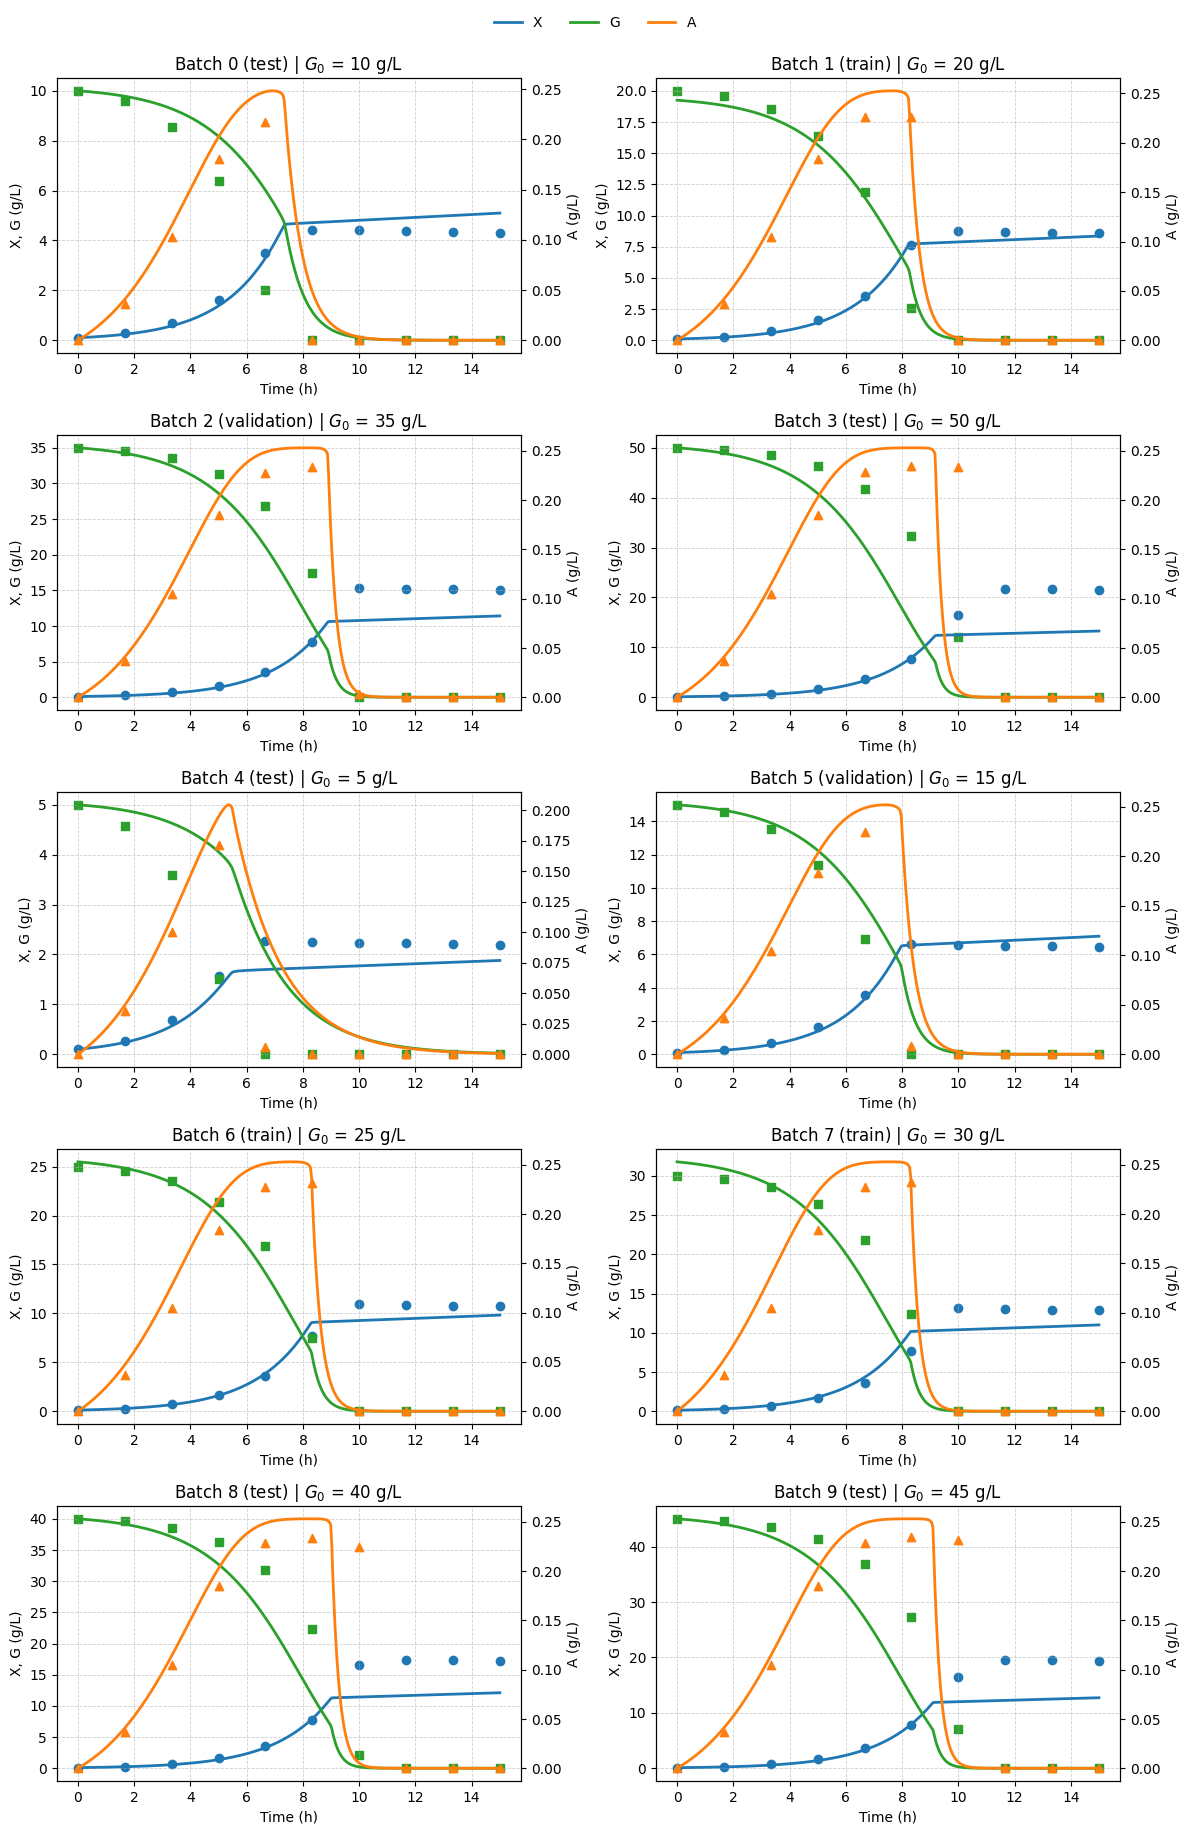

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# SCRIPT 1 of 2 — TRAIN ONE CONFIGURATION AND SAVE THE PARAMETERS
# Acetate production, hybrid neural-ODE (X, G, A).
#
# Requires in memory (from your data-generation cell):
#     raw_t, raw_X, raw_G, raw_A      (clean synthetic data)
#     obs_X, obs_G, obs_A             (noisy version, optional)
#
# This script does ONE training run with the configuration set below and writes
# everything the plotting script needs into a single .pkl file: the fitted
# parameters, the network architecture, the data splits, AND a copy of the data
# itself. The companion script (plot_acetate.py) therefore runs standalone --
# you can restart the session, load the pickle, and make figures without
# retraining and without re-running the data cell.
#
# Structure:
#     dX/dt = f1 X
#     dG/dt = f2 G X
#     dA/dt = (f3 A + ReLU(g3)) X
#     FNN outputs: f1, f2, f3 (linear), g3 (ReLU -> non-negative)
# ============================================================
import importlib.util, subprocess, sys


def _install_dependencies():
    def _has_gpu():
        try:
            return subprocess.run(["nvidia-smi"], capture_output=True).returncode == 0
        except FileNotFoundError:
            return False
    jax_pkg = "jax[cuda12]" if _has_gpu() else "jax"
    print(f"Installing {jax_pkg}, diffrax and optax (first run only)...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-U",
                           jax_pkg, "diffrax", "optax"])


if importlib.util.find_spec("diffrax") is None:
    _install_dependencies()

import os, time, pickle
import numpy as np

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def _show_fig(fig):
    """Inline display in Colab regardless of the backend."""
    try:
        from IPython.display import display
        display(fig)
    except Exception:
        pass


import jax
import jax.numpy as jnp

try:
    import diffrax
    import optax
except ImportError:
    _install_dependencies()
    raise SystemExit(
        "\nDependencies reinstalled. Restart the session "
        "(Runtime -> Restart session) and run this cell again.")

print(f"jax {jax.__version__} | diffrax {diffrax.__version__} | optax {optax.__version__}")
print(f"Backend: {jax.default_backend()}")

# ========================================================
# 0. CONFIGURATION  <<<< EDIT HERE >>>>
# ========================================================
# --- the single configuration to train ---
LR          = 1e-3
DROPOUT     = 0.1             # dropout rate used DURING TRAINING
HIDDEN      = [7,7,7,7]          # hidden layer sizes
LAMBDA_IC   = 1.0
ACTIVATION  = "tanh"          # "tanh", "relu" or "softplus" (hidden layers)
SEED        = 2

NUM_EPOCHS  = 10000
TRAIN_MODE  = "batch"         # "batch" (minibatch per experiment) or "global"

DATA_SOURCE = "clean"         # "clean" -> raw_* ; "noisy" -> obs_*

# --- data splits ---
# initial_glucose = [10, 20, 35, 50, 5, 15, 25, 30, 40, 45]
#   index :   0   1   2   3   4   5   6   7   8   9
#   G0    :  10  20  35  50   5  15  25  30  40  45
train_idxs = [1, 6, 7]        # G0 = 20, 25, 30
valid_idxs = [2, 5]           # G0 = 35, 15
test_idxs  = [0, 8, 4, 9, 3]  # G0 = 10, 40, 5, 45, 50

# --- solver ---
ODE_RTOL = 1e-6
ODE_ATOL = 1e-7
ODE_MAX_STEPS = 4096

# --- zero-field pretraining ---
CALIB_STEPS = 1000
CALIB_LR = 1e-3

DIVERGENCE_THRESHOLD = 1e6
EPS = 1.0e-8

# --- output ---
OUTDIR = "acetate_run"
os.makedirs(OUTDIR, exist_ok=True)
RUN_NAME = (f"LR{LR:g}_dr{DROPOUT:g}_h{'-'.join(map(str, HIDDEN))}"
            f"_lam{LAMBDA_IC:g}_{ACTIVATION}_seed{SEED}")
PKL_PATH = os.path.join(OUTDIR, f"model_{RUN_NAME}.pkl")

QUICK_PLOT = True             # a quick deterministic trajectory check at the end

# ========================================================
# 1. DATA
# ========================================================
if DATA_SOURCE == "noisy":
    _srcX, _srcG, _srcA = obs_X, obs_G, obs_A
elif DATA_SOURCE == "clean":
    _srcX, _srcG, _srcA = raw_X, raw_G, raw_A
else:
    raise ValueError("DATA_SOURCE must be 'clean' or 'noisy'")

# plain numpy copies (these are what gets pickled, so the plotting script is
# fully standalone and does not need the data-generation cell)
DATA_t = [np.asarray(a, float) for a in raw_t]
DATA_X = [np.asarray(a, float) for a in _srcX]
DATA_G = [np.asarray(a, float) for a in _srcG]
DATA_A = [np.asarray(a, float) for a in _srcA]

t_batches = [jax.device_put(jnp.array(a)) for a in DATA_t]
X_batches = [jax.device_put(jnp.array(a)) for a in DATA_X]
G_batches = [jax.device_put(jnp.array(a)) for a in DATA_G]
A_batches = [jax.device_put(jnp.array(a)) for a in DATA_A]


def _subset(idxs):
    return ([t_batches[i] for i in idxs], [X_batches[i] for i in idxs],
            [G_batches[i] for i in idxs], [A_batches[i] for i in idxs])


t_train, X_train, G_train, A_train = _subset(train_idxs)
t_valid, X_valid, G_valid, A_valid = _subset(valid_idxs)
t_test,  X_test,  G_test,  A_test  = _subset(test_idxs)

N_STATES = 3
N_OUTPUTS = 4                 # f1, f2, f3, g3
STATE_NAMES = ("X", "G", "A")
LAYER_SIZES = [N_STATES] + list(HIDDEN) + [N_OUTPUTS]
N_OBS_TRAIN = int(sum(len(t) for t in DATA_t[:1]) * 0)  # placeholder, set below
N_OBS_TRAIN = int(sum(len(DATA_t[i]) for i in train_idxs) * N_STATES)

print(f"\nConfiguration : {RUN_NAME}")
print(f"Data source   : {DATA_SOURCE}")
print(f"Splits        : train={train_idxs} valid={valid_idxs} test={test_idxs}")
print(f"Architecture  : {'-'.join(map(str, LAYER_SIZES))}")
print(f"Training obs  : {N_OBS_TRAIN}\n")

# ========================================================
# 2. NEURAL NETWORK AND MODEL
# ========================================================
HIDDEN_ACTIVATIONS = {"tanh": jnp.tanh, "relu": jax.nn.relu,
                      "softplus": jax.nn.softplus}


def init_net_params(rng_key, layer_sizes):
    params = {}
    keys = jax.random.split(rng_key, 2 * (len(layer_sizes) - 1))
    k = 0
    for i in range(len(layer_sizes) - 1):
        n_in, n_out = layer_sizes[i], layer_sizes[i + 1]
        params[f"W{i}"] = jax.random.uniform(keys[k], (n_out, n_in), minval=-0.1, maxval=0.1)
        params[f"b{i}"] = jax.random.uniform(keys[k + 1], (n_out,), minval=-0.1, maxval=0.1)
        k += 2
    return params


def sample_hidden_masks(net_params, rate, rng):
    if rate is None or rate <= 0.0:
        return None
    keep = 1.0 - rate
    masks = []
    num_layers = len(net_params) // 2
    for i in range(num_layers - 1):
        size = net_params[f"b{i}"].shape
        rng, ki = jax.random.split(rng)
        masks.append(jax.random.bernoulli(ki, p=keep, shape=size).astype(jnp.float32) / keep)
    return masks


def neural_network(net_params, y, *, train=False, masks=None, activation="tanh"):
    phi = HIDDEN_ACTIVATIONS[activation]
    a = y
    num_layers = len(net_params) // 2
    for i in range(num_layers):
        W, b = net_params[f"W{i}"], net_params[f"b{i}"]
        z = W @ a + b
        if i < num_layers - 1:
            a = phi(z)
            if train and (masks is not None):
                a = a * masks[i]
        else:
            a = z
    return a


def model_jax(net_params, y, t, *, train=False, masks=None, activation="tanh"):
    X, G, A = y
    f1, f2, f3, g3 = neural_network(net_params, jnp.array([X, G, A]),
                                    train=train, masks=masks, activation=activation)
    g3c = jax.nn.relu(g3)
    return jnp.stack([f1 * X, f2 * G * X, (f3 * A + g3c) * X])


def predict(net_params, t_array, X0, G0, *, A0=0.0,
            train=False, masks=None, activation="tanh"):
    def rhs(t, y, args):
        return model_jax(net_params, y, t, train=train, masks=masks,
                         activation=activation)
    sol = diffrax.diffeqsolve(
        diffrax.ODETerm(rhs), diffrax.Tsit5(),
        t0=t_array[0], t1=t_array[-1], dt0=None,
        y0=jnp.array([X0, G0, A0]),
        saveat=diffrax.SaveAt(ts=t_array),
        stepsize_controller=diffrax.PIDController(rtol=ODE_RTOL, atol=ODE_ATOL),
        max_steps=ODE_MAX_STEPS,
        adjoint=diffrax.RecursiveCheckpointAdjoint(),
        throw=False,
    )
    ys = sol.ys
    return ys[:, 0], ys[:, 1], ys[:, 2]


predict = jax.jit(predict, static_argnames=("train", "activation"))


# ========================================================
# 3. INITIAL CONDITIONS AND LOSSES
# ========================================================
def init_ic_offset_params_from_data():
    n = len(X_train)
    X0_meas = jnp.array([float(np.array(X_train[i])[0]) for i in range(n)])
    G0_meas = jnp.array([float(np.array(G_train[i])[0]) for i in range(n)])
    return ({"alpha_X": jnp.zeros_like(X0_meas), "alpha_G": jnp.zeros_like(G0_meas)},
            {"X0": X0_meas, "G0": G0_meas})


def ic_for_train_batch(params, idx):
    X0 = params["ic_meas"]["X0"][idx] * jnp.exp(params["ic_alpha"]["alpha_X"][idx])
    G0 = params["ic_meas"]["G0"][idx] * jnp.exp(params["ic_alpha"]["alpha_G"][idx])
    return X0, G0, jnp.array(0.0)


def safe_rel(pred, obs):
    return (pred - obs) / jnp.maximum(jnp.mean(jnp.abs(obs)), EPS)


def _mse3(Xp, Gp, Ap, Xo, Go, Ao):
    return (jnp.mean(safe_rel(Xp, Xo) ** 2) + jnp.mean(safe_rel(Gp, Go) ** 2) +
            jnp.mean(safe_rel(Ap, Ao) ** 2))


def batch_loss_train(params, idx, rng):
    X0, G0, A0 = ic_for_train_batch(params, idx)
    masks = sample_hidden_masks(params["net"], DROPOUT, rng)
    Xp, Gp, Ap = predict(params["net"], t_train[idx], X0, G0, A0=A0,
                         train=True, masks=masks, activation=ACTIVATION)
    data_loss = _mse3(Xp, Gp, Ap, X_train[idx], G_train[idx], A_train[idx])
    reg = LAMBDA_IC * (params["ic_alpha"]["alpha_X"][idx] ** 2 +
                       params["ic_alpha"]["alpha_G"][idx] ** 2)
    return data_loss + reg


batch_loss_train_jit = jax.jit(batch_loss_train, static_argnums=(1,))


def global_train_loss(params, rng_key):
    total = 0.0
    for idx in range(len(t_train)):
        total += batch_loss_train(params, idx, jax.random.fold_in(rng_key, idx))
    return total / len(t_train)


def batch_loss_train_eval(params, idx):
    X0, G0, A0 = ic_for_train_batch(params, idx)
    Xp, Gp, Ap = predict(params["net"], t_train[idx], X0, G0, A0=A0,
                         train=False, masks=None, activation=ACTIVATION)
    return _mse3(Xp, Gp, Ap, X_train[idx], G_train[idx], A_train[idx])


batch_loss_train_eval_jit = jax.jit(batch_loss_train_eval, static_argnums=(1,))


def loss_heldout(net, t_o, X_o, G_o, A_o):
    Xp, Gp, Ap = predict(net, t_o, X_o[0], G_o[0], A0=0.0,
                         train=False, masks=None, activation=ACTIVATION)
    return _mse3(Xp, Gp, Ap, X_o, G_o, A_o)


loss_heldout_jit = jax.jit(loss_heldout)


# ========================================================
# 4. ZERO-FIELD PRETRAINING
# ========================================================
def calib_loss(net_params, points):
    target = jnp.zeros(N_OUTPUTS)

    def per_point(y):
        return jnp.mean((neural_network(net_params, y, train=False,
                                        activation=ACTIVATION) - target) ** 2)
    return jnp.mean(jax.vmap(per_point)(points))


def calibrate(net_params, points, steps=CALIB_STEPS, lr=CALIB_LR):
    """Drive the network outputs to zero so the vector field starts neutral."""
    optc = optax.adam(lr)
    opt_state = optc.init(net_params)

    @jax.jit
    def step(p, s):
        loss, grads = jax.value_and_grad(calib_loss)(p, points)
        updates, s = optc.update(grads, s, p)
        return optax.apply_updates(p, updates), s, loss

    p = net_params
    for _ in range(steps):
        p, opt_state, _ = step(p, opt_state)
    return p


_calib_points = jnp.array([[x, g, a]
                           for i in train_idxs
                           for x, g, a in zip(DATA_X[i], DATA_G[i], DATA_A[i])])

# ========================================================
# 5. TRAINING
# ========================================================
rng_master = jax.random.PRNGKey(SEED)
np.random.seed(SEED)
t0_cpu, t0_wall = time.process_time(), time.perf_counter()

net_params = init_net_params(jax.random.fold_in(rng_master, 0), LAYER_SIZES)
net_params = calibrate(net_params, _calib_points)

ic_alpha, ic_meas = init_ic_offset_params_from_data()
params = {"net": net_params, "ic_alpha": ic_alpha, "ic_meas": ic_meas}

opt = optax.adam(LR)
opt_state = opt.init(params)


def eval_avg_train_loss(p):
    v = [float(batch_loss_train_eval_jit(p, i)) for i in range(len(t_train))]
    return float(np.mean(v)) if v else np.nan


def eval_split(net, T, Xs, Gs, As):
    v = [float(loss_heldout_jit(net, T[i], Xs[i], Gs[i], As[i]))
         for i in range(len(T))]
    return (float(np.mean(v)) if v else np.nan), v


def _blown_up(tr, va):
    return (not (np.isfinite(tr) and np.isfinite(va))
            or tr > DIVERGENCE_THRESHOLD or va > DIVERGENCE_THRESHOLD)


train_history, valid_history = [], []
best_val, best_epoch, best_params = np.inf, None, None
diverged = False

if TRAIN_MODE == "batch":
    def train_step(params, opt_state, idx, rng):
        grads = jax.grad(batch_loss_train_jit)(params, idx, rng)
        updates, opt_state = opt.update(grads, opt_state, params)
        return optax.apply_updates(params, updates), opt_state
    train_step = jax.jit(train_step, static_argnums=(2,))

    for epoch in range(1, NUM_EPOCHS + 1):
        epoch_key = jax.random.fold_in(rng_master, epoch)
        perm = np.array(jax.random.permutation(epoch_key, len(t_train)))
        for idx in perm:
            params, opt_state = train_step(params, opt_state, int(idx),
                                           jax.random.fold_in(epoch_key, int(idx)))
        tr = eval_avg_train_loss(params)
        va, _ = eval_split(params["net"], t_valid, X_valid, G_valid, A_valid)
        train_history.append(tr); valid_history.append(va)
        if _blown_up(tr, va):
            diverged = True
            print(f"  ep {epoch}: DIVERGED -> aborted")
            break
        if va < best_val:
            best_val, best_epoch = float(va), epoch
            best_params = jax.tree_util.tree_map(lambda x: np.array(x), params)
        if epoch % 400 == 0:
            print(f"  ep {epoch}: train={tr:.6f}, valid={va:.6f}")

elif TRAIN_MODE == "global":
    # jax.grad deliberately NOT jitted here (TPU compiler issue).
    for epoch in range(1, NUM_EPOCHS + 1):
        epoch_key = jax.random.fold_in(rng_master, epoch)
        grads = jax.grad(global_train_loss)(params, epoch_key)
        updates, opt_state = opt.update(grads, opt_state, params)
        params = optax.apply_updates(params, updates)
        tr = eval_avg_train_loss(params)
        va, _ = eval_split(params["net"], t_valid, X_valid, G_valid, A_valid)
        train_history.append(tr); valid_history.append(va)
        if _blown_up(tr, va):
            diverged = True
            print(f"  ep {epoch}: DIVERGED -> aborted")
            break
        if va < best_val:
            best_val, best_epoch = float(va), epoch
            best_params = jax.tree_util.tree_map(lambda x: np.array(x), params)
        if epoch % 400 == 0:
            print(f"  ep {epoch}: train={tr:.6f}, valid={va:.6f}")
else:
    raise ValueError("TRAIN_MODE must be 'batch' or 'global'")

cpu_time_s = time.process_time() - t0_cpu
wall_time_s = time.perf_counter() - t0_wall

if best_params is None:
    raise SystemExit("Training produced no usable parameters (diverged immediately).")

print(f"\nDone in {wall_time_s:.0f}s wall / {cpu_time_s:.0f}s cpu"
      f"{' (DIVERGED)' if diverged else ''}")
print(f"Best validation loss: {best_val:.6e} at epoch {best_epoch}")


# ========================================================
# 6. R^2 REPORT
# ========================================================
def _r2(obs, pred):
    obs = np.asarray(obs, float).ravel()
    pred = np.asarray(pred, float).ravel()
    n = min(obs.size, pred.size)
    obs, pred = obs[:n], pred[:n]
    m = np.isfinite(obs) & np.isfinite(pred)
    if m.sum() < 2:
        return np.nan
    o, p = obs[m], pred[m]
    ss = float(np.sum((o - o.mean()) ** 2))
    return float(1.0 - np.sum((o - p) ** 2) / ss) if ss > 0 else np.nan


bnet = jax.tree_util.tree_map(jnp.asarray, best_params["net"])
b_alpha = jax.tree_util.tree_map(jnp.asarray, best_params["ic_alpha"])
b_meas = jax.tree_util.tree_map(jnp.asarray, best_params["ic_meas"])

ROLE_OF = {}
for i in train_idxs:
    ROLE_OF[i] = "train"
for i in valid_idxs:
    ROLE_OF[i] = "validation"
for i in test_idxs:
    ROLE_OF[i] = "test"

print(f"\n{'batch':>6} {'G0':>6} {'role':>11} {'R2_X':>9} {'R2_G':>9} {'R2_A':>9}")
r2_table = {}
for bidx in sorted(ROLE_OF):
    role = ROLE_OF[bidx]
    if role == "train":
        pos = train_idxs.index(bidx)
        X0 = float(b_meas["X0"][pos] * jnp.exp(b_alpha["alpha_X"][pos]))
        G0 = float(b_meas["G0"][pos] * jnp.exp(b_alpha["alpha_G"][pos]))
    else:
        X0, G0 = float(DATA_X[bidx][0]), float(DATA_G[bidx][0])
    P = predict(bnet, jnp.array(DATA_t[bidx]), X0, G0, A0=0.0,
                train=False, masks=None, activation=ACTIVATION)
    r2s = [_r2(o, np.array(p)) for o, p in
           zip((DATA_X[bidx], DATA_G[bidx], DATA_A[bidx]), P)]
    r2_table[bidx] = r2s
    print(f"{bidx:>6} {DATA_G[bidx][0]:>6.0f} {role:>11} "
          f"{r2s[0]:>9.4f} {r2s[1]:>9.4f} {r2s[2]:>9.4f}")

# ========================================================
# 7. SAVE EVERYTHING THE PLOTTING SCRIPT NEEDS
# ========================================================
bundle = {
    "params": best_params,                 # net, ic_alpha, ic_meas (numpy)
    "layer_sizes": LAYER_SIZES,
    "activation": ACTIVATION,
    "dropout_train": DROPOUT,              # rate used during training
    "config": dict(lr=LR, dropout=DROPOUT, hidden=list(HIDDEN),
                   lambda_ic=LAMBDA_IC, activation=ACTIVATION, seed=SEED,
                   num_epochs=NUM_EPOCHS, train_mode=TRAIN_MODE,
                   data_source=DATA_SOURCE),
    "splits": dict(train=list(train_idxs), valid=list(valid_idxs),
                   test=list(test_idxs)),
    "solver": dict(rtol=ODE_RTOL, atol=ODE_ATOL, max_steps=ODE_MAX_STEPS),
    "data": dict(t=DATA_t, X=DATA_X, G=DATA_G, A=DATA_A),   # standalone plotting
    "history": dict(train=np.asarray(train_history, float),
                    valid=np.asarray(valid_history, float)),
    "result": dict(best_val=float(best_val), best_epoch=best_epoch,
                   diverged=bool(diverged), cpu_time_s=float(cpu_time_s),
                   wall_time_s=float(wall_time_s), r2=r2_table),
    "run_name": RUN_NAME,
}

with open(PKL_PATH, "wb") as fh:
    pickle.dump(bundle, fh)

print(f"\nParameters saved to: {PKL_PATH}")
print("Use this path in the plotting script (PKL_PATH).")

# ========================================================
# 8. QUICK CHECK PLOT (deterministic, no dropout)
# ========================================================
if QUICK_PLOT:
    COL = {"X": "#1f77b4", "G": "#2ca02c", "A": "#ff7f0e"}
    idxs = sorted(ROLE_OF)
    ncols = 2 if len(idxs) > 1 else 1
    nrows = int(np.ceil(len(idxs) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 3.6 * nrows),
                             squeeze=False)
    axes = axes.ravel()
    for k, bidx in enumerate(idxs):
        ax1 = axes[k]; ax2 = ax1.twinx()
        role = ROLE_OF[bidx]
        if role == "train":
            pos = train_idxs.index(bidx)
            X0 = float(b_meas["X0"][pos] * jnp.exp(b_alpha["alpha_X"][pos]))
            G0 = float(b_meas["G0"][pos] * jnp.exp(b_alpha["alpha_G"][pos]))
        else:
            X0, G0 = float(DATA_X[bidx][0]), float(DATA_G[bidx][0])
        td = jnp.linspace(float(DATA_t[bidx].min()), float(DATA_t[bidx].max()), 400)
        Xp, Gp, Ap = predict(bnet, td, X0, G0, A0=0.0, train=False, masks=None,
                             activation=ACTIVATION)
        td = np.array(td)
        ax1.plot(td, np.array(Xp), color=COL["X"], lw=2)
        ax1.plot(td, np.array(Gp), color=COL["G"], lw=2)
        ax2.plot(td, np.array(Ap), color=COL["A"], lw=2)
        ax1.scatter(DATA_t[bidx], DATA_X[bidx], marker='o', color=COL["X"])
        ax1.scatter(DATA_t[bidx], DATA_G[bidx], marker='s', color=COL["G"])
        ax2.scatter(DATA_t[bidx], DATA_A[bidx], marker='^', color=COL["A"])
        ax1.set_title(f"Batch {bidx} ({role}) | $G_0$ = {DATA_G[bidx][0]:.0f} g/L")
        ax1.set_xlabel("Time (h)"); ax1.set_ylabel("X, G (g/L)")
        ax2.set_ylabel("A (g/L)")
        ax1.grid(True, ls="--", lw=0.6, alpha=0.6)
    for j in range(len(idxs), len(axes)):
        axes[j].axis("off")
    handles = [Line2D([0], [0], color=COL[v], lw=2, label=v) for v in STATE_NAMES]
    fig.legend(handles=handles, loc="upper center", ncol=3, frameon=False,
               bbox_to_anchor=(0.5, 1.02))
    fig.tight_layout()
    fig.savefig(os.path.join(OUTDIR, f"quickcheck_{RUN_NAME}.png"), dpi=150,
                bbox_inches="tight")
    _show_fig(fig)
    plt.close(fig)

try:
    from google.colab import files
    files.download(PKL_PATH)
except Exception:
    pass

The following code produces the **figures and the R² table of Case Study 1 from an
already trained model**, without retraining. It loads the `.pkl` written by the training
script, which carries the fitted parameters, the architecture, the splits and a copy of
the data, so it runs standalone.

**Figure 1 — trajectories with uncertainty bands.** One panel per selected batch, with
$X$ and $G$ on the left axis and $A$ on the right. The bands come from **Monte Carlo
dropout**: dropout is kept active at prediction time and the model is integrated
`MC_SAMPLES` times, each with one dropout mask held fixed along the trajectory. The
script reports the relative width and the coverage of the bands.

**Figure 2 — $g_3$ vs $f_1$**, evaluated with dropout off, showing the learned overflow
relationship between the specific acetate production rate and the specific growth rate.
A hinge $g_3 = \max(k(f_1-l),0)$ is fitted and drawn, with its parameters printed to the
console.

**A LaTeX R² table**, one row per experiment, computed from the deterministic trajectory.

---

### 🔧 Configuration

- **PKL_PATH:** the trained model to load.
- **PLOT_BATCHES:** which batches to draw; `None` takes all of them.
- **MC_SAMPLES, MC_RATE, MC_CI:** number of samples, dropout rate for sampling (`None`
  reuses the training rate) and interval width.
- **SHOW_MEAN:** `False` draws the deterministic trajectory, consistent with the R²
  table; `True` draws the mean of the samples.
- **G3F1_BATCHES / G3F1_FIT:** experiments shown in Figure 2 and whether the hinge is
  fitted.
- **MAKE_R2_TABLE:** whether to produce the LaTeX table.
- **FORMATS:** output formats; PDF is preferred, since EPS does not support
  transparency.

---

### 📦 Outputs

Written to `acetate_figures/`: the two figures and the `.tex` file with the R² table.

Loaded    : acetate_run/model_LR0.001_dr0.1_h7-7-7-7_lam1_tanh_seed2.pkl
Run       : LR0.001_dr0.1_h7-7-7-7_lam1_tanh_seed2
Arch      : 3-7-7-7-7-4 | activation tanh
Splits    : train=[1, 6, 7] valid=[2, 5] test=[0, 8, 4, 9, 3]
MC dropout: 500 samples at rate 0.1 (training rate was 0.1) | 95% interval
Plotting  : batches [6, 2, 3, 4]

Simulating MC-dropout bands...


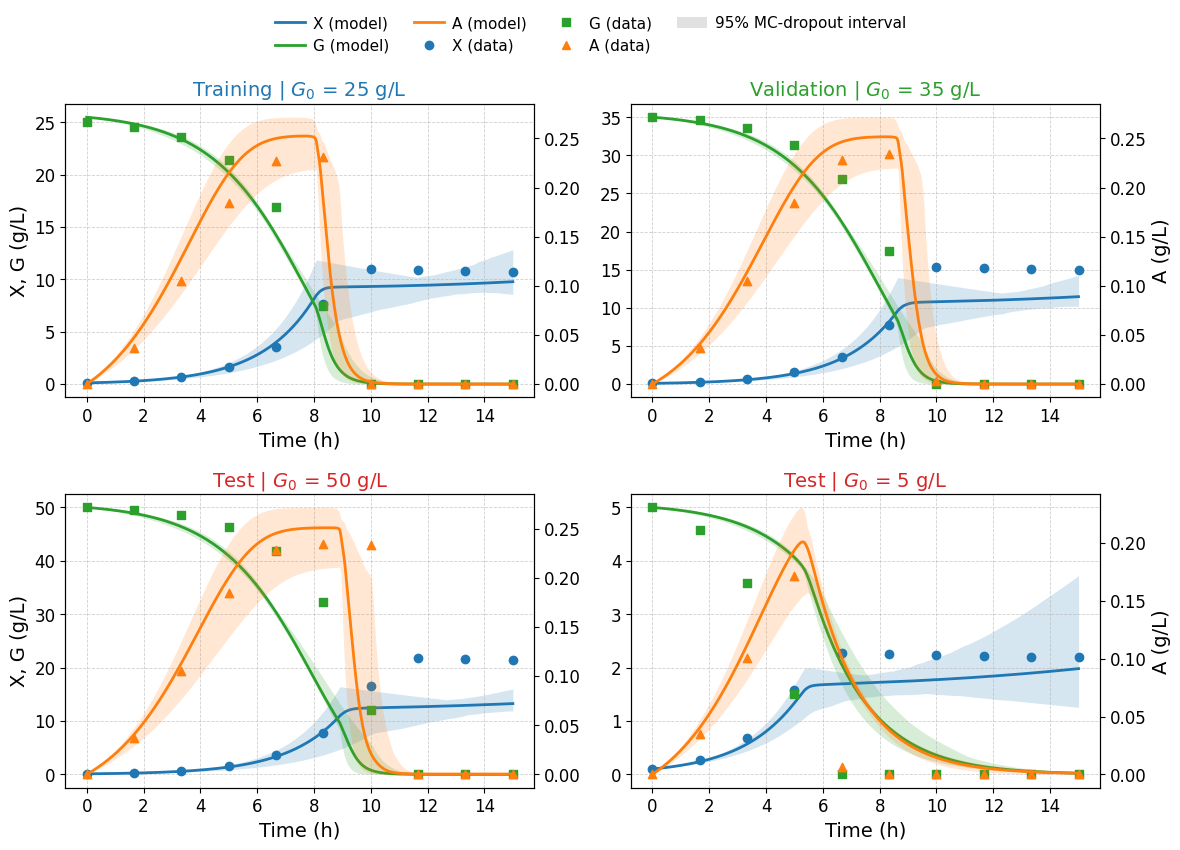


Band statistics (relative width / coverage):
      G0         set                X                G                A
      25    training      0.422 / 70%      0.070 / 30%      0.518 / 70%
      35  validation      0.362 / 30%      0.061 / 30%      0.540 / 80%
      50        test      0.367 / 30%      0.061 / 20%      0.511 / 80%
       5        test      0.472 / 40%      0.206 / 10%      0.663 / 40%
  rel. width = mean band width / mean observed value
  coverage   = fraction of measurements falling inside the band


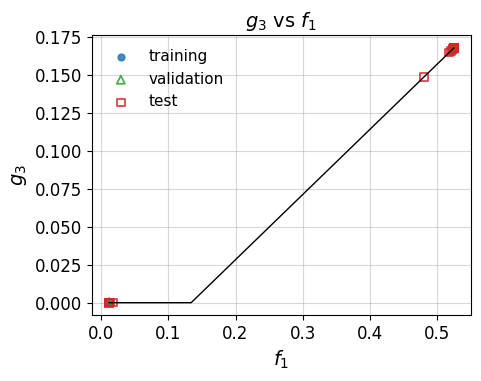


g3 vs f1: batches [1, 6, 7, 2, 5, 0, 3, 4, 8, 9] (test, training, validation)
  hinge fit on 'training' batches [1, 6, 7]: g3 = max(k*(f1 - l), 0) over 30 points
    k  = 0.4281
    l  = 0.1339
    R2 = 1.0000

LaTeX R^2 table (copy-paste ready)
\begin{table}[h!]
\centering
\caption{Determination coefficients ($R^2$) associated with Figure~\ref{fig:ecoli}, comparing model simulations with data for biomass ($X$), glucose ($G$), and acetate ($A$). Each experiment is identified by its initial glucose concentration $G_0$.}
\begin{tabular}{llccc}
\toprule
\textbf{Experiment} & \textbf{Set} & \textbf{$X$} & \textbf{$G$} & \textbf{$A$} \\
\midrule
$G_0 = 20$ g/L & Training & 0.99 & 0.99 & 0.97 \\
$G_0 = 25$ g/L & Training & 0.96 & 0.99 & 0.97 \\
$G_0 = 30$ g/L & Training & 0.91 & 0.95 & 0.96 \\
\midrule
$G_0 = 35$ g/L & Validation & 0.85 & 0.96 & 0.99 \\
$G_0 = 15$ g/L & Validation & 0.99 & 0.97 & 0.83 \\
\midrule
$G_0 = 10$ g/L & Test & 0.95 & 0.88 & 0.94 \\
$G_0 = 50$ g/L & Test & 0.72 & 0

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  - acetate_figures/figure4.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# SCRIPT 2 of 2 — FIGURES FROM A SAVED MODEL (no retraining)
# Acetate production, hybrid neural-ODE (X, G, A).
#
# Loads the .pkl written by train_acetate.py and produces:
#
#   FIGURE 1 — trajectories with MC-dropout uncertainty bands.
#              One panel per selected batch, each labelled with its role
#              (training / validation / test). X and G on the left axis,
#              A on the right axis.
#
#   FIGURE 2 — g3 vs f1 scatter, evaluated WITHOUT dropout (deterministic),
#              the learned overflow-metabolism relationship.
#
# Everything is configurable below without touching the model: how many MC
# samples, the dropout rate used for sampling, the interval width, which
# batches to show, figure size, output format. The pickle also carries a copy
# of the data, so this script runs standalone -- no need to re-run the
# data-generation cell.
# ============================================================
import os, pickle
import numpy as np

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

import jax
import jax.numpy as jnp
import diffrax


def _show_fig(fig):
    try:
        from IPython.display import display
        display(fig)
    except Exception:
        pass


# ========================================================
# 0. WHAT TO PLOT  <<<< EDIT HERE >>>>
# ========================================================
PKL_PATH = "acetate_run/model_LR0.001_dr0.1_h7-7-7-7_lam1_tanh_seed2.pkl"

# --- which batches, and in which order ---
# Four panels chosen to tell the whole story, one situation each. Training
# range is G0 = 20-30, so:
#   index 6  G0 = 25  training    -- representative fit (middle of the range)
#   index 2  G0 = 35  validation  -- held out, just outside the training range
#   index 3  G0 = 50  test        -- far ABOVE the range, still predicted well
#   index 4  G0 = 5   test        -- far BELOW the range, where it breaks down
# The last two are the interesting contrast: extrapolating upward works,
# downward does not, which is the point worth discussing.
# Alternatives: 1 = 20, 7 = 30 (training) | 5 = 15 (validation)
#               0 = 10, 8 = 40, 9 = 45 (test)
# Set to None to plot every batch in the splits.
PLOT_BATCHES = [6, 2, 3, 4]
# Sort the panels by role instead of by index (train first, then valid, test).
SORT_BY_ROLE = True

# --- Monte Carlo dropout ---
MC_SAMPLES = 500        # stochastic forward simulations per batch
MC_RATE = None          # None = reuse the training dropout rate from the pickle.
                        # Set a float to override (REQUIRED if the model was
                        # trained with dropout = 0, since a zero rate gives no
                        # variability at all). Report this choice in the paper.
MC_CI = 95.0            # interval width in percent (95 -> 2.5/97.5 percentiles)
MC_SEED = 0             # change to resample the bands
BAND_ALPHA = 0.18       # transparency of the shaded band
SHOW_MEAN = True      # Which line is drawn inside the band.
                        # False (default) = the DETERMINISTIC trajectory
                        #   (dropout off). This is the model the R^2 table
                        #   refers to, so figure and table stay consistent.
                        # True = the mean of the MC samples. Note this is a
                        #   DIFFERENT curve: averaging stochastic solutions of
                        #   a nonlinear ODE does not give the deterministic
                        #   solution, so the plotted line would then no longer
                        #   be the one the reported R^2 was computed from.
N_DENSE = 400           # time points per trajectory (lower = faster)

# --- g3 vs f1 figure ---
# "training", "validation", "test", "training+validation", "all",
# None (= same selection as PLOT_BATCHES), or an explicit list [1, 6, 7].
G3F1_BATCHES = "all"
G3F1_FIGSIZE = (5.0, 4.0)
# Each role gets its own colour AND marker, so the two groups stay legible
# even in greyscale. Filled = training, open = validation.
G3F1_STYLE = {
    "training":   dict(color="#1f77b4", marker="o", filled=True,  s=26),
    "validation": dict(color="#2ca02c", marker="^", filled=False, s=34),
    "test":       dict(color="#d62728", marker="s", filled=False, s=30),
}
G3F1_LEGEND = True          # legend identifying the point groups only
# Least-squares fit of a hinge  g3 = max(k*(f1 - l), 0).
# The fitted curve is drawn, but nothing on the figure identifies it --
# no legend entry, no annotation. The parameters are printed to the console.
G3F1_FIT = True
G3F1_FIT_ON = "training"    # which points the fit uses: "training", "plotted",
                            # or any of the keys accepted by G3F1_BATCHES
G3F1_FIT_COLOR = "#000000"  # black: distinct from every point group
G3F1_FIT_LW = 1.0           # thin line

# --- LaTeX R^2 table ---
MAKE_R2_TABLE = True
R2_DECIMALS = 2         # decimal places, uniform across every column
R2_TABLE_BATCHES = "all"    # the table keeps every experiment even though the
                            # figure shows only four; use None to follow
                            # PLOT_BATCHES, or an explicit list
# Rows are identified by their initial glucose concentration, not by a batch
# number: the numbering would depend on the order the splits happen to be
# listed in, which invites confusion.
R2_ID_HEADER = r"\textbf{Experiment}"
R2_ROLE_COLUMN = True   # add an explicit training/validation/test column, so
                        # the groups are unambiguous without relying on order
R2_TABLE_LABEL = "tab:r2_xsa"
R2_TABLE_CAPTION = (
    "Determination coefficients ($R^2$) associated with "
    "Figure~\\ref{fig:ecoli}, comparing model simulations with data for "
    "biomass ($X$), glucose ($G$), and acetate ($A$). Each experiment is "
    "identified by its initial glucose concentration $G_0$.")

# --- output ---
OUTDIR = "acetate_figures"
# PDF is vector AND supports transparency, so the overlapping uncertainty bands
# blend properly. Elsevier lists PDF alongside EPS as a recommended format for
# vector artwork, so this is fine for Applied Mathematical Modelling.
# EPS (PostScript) has no alpha channel: with "eps" in FORMATS the bands are
# drawn as solid pre-blended colours instead, which is safe but makes
# overlapping bands hide one another. Prefer "pdf" unless EPS is mandatory.
FORMATS = ("png", "pdf")     # png for quick viewing, pdf for the journal
DOWNLOAD_FORMATS = ("pdf",)  # which of the above get auto-downloaded in Colab
# File names, matching the manuscript's figure numbering. The extension is
# added automatically, one file per entry in FORMATS.
FIG_TRAJECTORIES = "figure3"    # trajectories with MC-dropout bands
FIG_G3F1 = "figure4"            # g3 vs f1
DPI = 150
PANEL_W, PANEL_H = 6.0, 4.0
NCOLS = 2
# Entries per row in the figure legend. There are 7 entries (3 model lines,
# 3 data markers, 1 band patch): 4 gives two tidy rows, 7 forces a single wide
# row, 3 gives three compact rows for narrow figures.
LEGEND_NCOL = 4
DOWNLOAD = True              # auto-download in Colab

os.makedirs(OUTDIR, exist_ok=True)

# EPS cannot store an alpha channel; every other format we emit can.
ALPHA_OK = "eps" not in [f.lower() for f in FORMATS]


def _blend(color, alpha, bg="white"):
    """Blend a colour towards the background, for the EPS fallback.

    Used only when ALPHA_OK is False. Matches real transparency over a white
    background for a single layer, but note that overlapping bands can then no
    longer show through one another -- which is exactly why PDF is preferred.
    """
    import matplotlib.colors as mcolors
    c = np.array(mcolors.to_rgb(color))
    b = np.array(mcolors.to_rgb(bg))
    return tuple(alpha * c + (1.0 - alpha) * b)


def band_kwargs(color):
    """Fill styling for an uncertainty band: real transparency when the output
    format supports it, pre-blended solid colour otherwise."""
    if ALPHA_OK:
        return dict(color=color, alpha=BAND_ALPHA)
    return dict(color=_blend(color, BAND_ALPHA))


def point_kwargs(color, filled):
    """Marker styling, likewise."""
    if filled:
        face = color if ALPHA_OK else _blend(color, 0.8)
        d = dict(facecolors=face, edgecolors=color, linewidths=0.8)
    else:
        d = dict(facecolors="none", edgecolors=color, linewidths=1.3)
    if ALPHA_OK:
        d["alpha"] = 0.85
    return d

# ========================================================
# 1. LOAD THE TRAINED MODEL
# ========================================================
with open(PKL_PATH, "rb") as fh:
    B = pickle.load(fh)

params = B["params"]
LAYER_SIZES = B["layer_sizes"]
ACTIVATION = B["activation"]
DROPOUT_TRAIN = B["dropout_train"]
SPLITS = B["splits"]
SOLVER = B["solver"]
RUN_NAME = B.get("run_name", "model")

DATA_t, DATA_X = B["data"]["t"], B["data"]["X"]
DATA_G, DATA_A = B["data"]["G"], B["data"]["A"]

train_idxs, valid_idxs, test_idxs = SPLITS["train"], SPLITS["valid"], SPLITS["test"]

ROLE_OF = {}
for i in train_idxs:
    ROLE_OF[i] = "training"
for i in valid_idxs:
    ROLE_OF[i] = "validation"
for i in test_idxs:
    ROLE_OF[i] = "test"
ROLE_ORDER = {"training": 0, "validation": 1, "test": 2}

STATE_NAMES = ("X", "G", "A")
COL = {"X": "#1f77b4", "G": "#2ca02c", "A": "#ff7f0e"}
MARK = {"X": "o", "G": "s", "A": "^"}
ROLE_COL = {"training": "#1f77b4", "validation": "#2ca02c", "test": "#d62728"}

_PLOT_RC = {"font.size": 13, "axes.titlesize": 14, "axes.labelsize": 14,
            "xtick.labelsize": 12, "ytick.labelsize": 12, "legend.fontsize": 11}

mc_rate = MC_RATE if MC_RATE is not None else DROPOUT_TRAIN

print(f"Loaded    : {PKL_PATH}")
print(f"Run       : {RUN_NAME}")
print(f"Arch      : {'-'.join(map(str, LAYER_SIZES))} | activation {ACTIVATION}")
print(f"Splits    : train={train_idxs} valid={valid_idxs} test={test_idxs}")
print(f"MC dropout: {MC_SAMPLES} samples at rate {mc_rate:g} "
      f"(training rate was {DROPOUT_TRAIN:g}) | {MC_CI:g}% interval")
if mc_rate <= 0.0:
    print("\nWARNING: the MC rate is zero, so all sampled trajectories are\n"
          "identical and the bands collapse to a line. Set MC_RATE > 0.\n")

# ========================================================
# 2. MODEL (identical to the training script)
# ========================================================
HIDDEN_ACTIVATIONS = {"tanh": jnp.tanh, "relu": jax.nn.relu,
                      "softplus": jax.nn.softplus}


def sample_hidden_masks(net_params, rate, rng):
    if rate is None or rate <= 0.0:
        return None
    keep = 1.0 - rate
    masks = []
    num_layers = len(net_params) // 2
    for i in range(num_layers - 1):
        size = net_params[f"b{i}"].shape
        rng, ki = jax.random.split(rng)
        masks.append(jax.random.bernoulli(ki, p=keep, shape=size).astype(jnp.float32) / keep)
    return masks


def neural_network(net_params, y, *, train=False, masks=None, activation="tanh"):
    phi = HIDDEN_ACTIVATIONS[activation]
    a = y
    num_layers = len(net_params) // 2
    for i in range(num_layers):
        W, b = net_params[f"W{i}"], net_params[f"b{i}"]
        z = W @ a + b
        if i < num_layers - 1:
            a = phi(z)
            if train and (masks is not None):
                a = a * masks[i]
        else:
            a = z
    return a


def model_jax(net_params, y, t, *, train=False, masks=None, activation="tanh"):
    X, G, A = y
    f1, f2, f3, g3 = neural_network(net_params, jnp.array([X, G, A]),
                                    train=train, masks=masks, activation=activation)
    g3c = jax.nn.relu(g3)
    return jnp.stack([f1 * X, f2 * G * X, (f3 * A + g3c) * X])


def predict(net_params, t_array, X0, G0, *, A0=0.0,
            train=False, masks=None, activation="tanh"):
    def rhs(t, y, args):
        return model_jax(net_params, y, t, train=train, masks=masks,
                         activation=activation)
    sol = diffrax.diffeqsolve(
        diffrax.ODETerm(rhs), diffrax.Tsit5(),
        t0=t_array[0], t1=t_array[-1], dt0=None,
        y0=jnp.array([X0, G0, A0]),
        saveat=diffrax.SaveAt(ts=t_array),
        stepsize_controller=diffrax.PIDController(rtol=SOLVER["rtol"],
                                                 atol=SOLVER["atol"]),
        max_steps=SOLVER["max_steps"],
        adjoint=diffrax.RecursiveCheckpointAdjoint(),
        throw=False,
    )
    ys = sol.ys
    return ys[:, 0], ys[:, 1], ys[:, 2]


predict = jax.jit(predict, static_argnames=("train", "activation"))

net = jax.tree_util.tree_map(jnp.asarray, params["net"])
ic_alpha = jax.tree_util.tree_map(jnp.asarray, params["ic_alpha"])
ic_meas = jax.tree_util.tree_map(jnp.asarray, params["ic_meas"])


def initial_condition(bidx):
    """Training batches use the fitted initial condition; held-out batches use
    the measured one."""
    if bidx in train_idxs:
        pos = train_idxs.index(bidx)
        X0 = float(ic_meas["X0"][pos] * jnp.exp(ic_alpha["alpha_X"][pos]))
        G0 = float(ic_meas["G0"][pos] * jnp.exp(ic_alpha["alpha_G"][pos]))
    else:
        X0, G0 = float(DATA_X[bidx][0]), float(DATA_G[bidx][0])
    return X0, G0


# ========================================================
# 3. BATCH SELECTION
# ========================================================
def resolve_batches(sel):
    if sel is None:
        out = list(ROLE_OF)
    else:
        out = [int(b) for b in sel]
        unknown = [b for b in out if b not in ROLE_OF]
        if unknown:
            raise ValueError(f"batches {unknown} are not in any split of this run")
    if SORT_BY_ROLE:
        out = sorted(out, key=lambda b: (ROLE_ORDER[ROLE_OF[b]], b))
    else:
        out = sorted(out)
    return out


batches = resolve_batches(PLOT_BATCHES)
print(f"Plotting  : batches {batches}\n")


def resolve_g3f1_batches(sel):
    """Accepts 'training', 'validation', 'test', 'training+validation',
    'all', None (= same as PLOT_BATCHES) or an explicit list."""
    if isinstance(sel, str):
        key = sel.lower().replace(" ", "")
        table = {"training": train_idxs, "train": train_idxs,
                 "validation": valid_idxs, "valid": valid_idxs,
                 "test": test_idxs}
        if key in table:
            return sorted(table[key])
        if key in ("training+validation", "train+valid"):
            return sorted(list(train_idxs) + list(valid_idxs))
        if key == "all":
            return resolve_batches(None)
        if key == "plotted":
            return list(batches)
        raise ValueError(f"unknown batch selection '{sel}'")
    return resolve_batches(sel if sel is not None else PLOT_BATCHES)


# ========================================================
# 4. MONTE CARLO DROPOUT
# ========================================================
def mc_bands(bidx, n_samples=MC_SAMPLES, rate=None, ci=MC_CI, seed=MC_SEED):
    """n_samples trajectories, ONE dropout mask each held fixed along the whole
    integration (exactly as during training). Returns dense mean/lo/hi."""
    rate = mc_rate if rate is None else rate
    X0, G0 = initial_condition(bidx)
    t_np = DATA_t[bidx]
    t_dense = jnp.linspace(float(t_np.min()), float(t_np.max()), N_DENSE)

    lo_q, hi_q = (100.0 - ci) / 2.0, 100.0 - (100.0 - ci) / 2.0
    keys = jax.random.split(jax.random.fold_in(jax.random.PRNGKey(seed), bidx),
                            n_samples)

    def one(key):
        masks = sample_hidden_masks(net, rate, key)
        Xp, Gp, Ap = predict(net, t_dense, X0, G0, A0=0.0, train=True,
                             masks=masks, activation=ACTIVATION)
        return jnp.stack([Xp, Gp, Ap])

    if rate is not None and rate > 0.0:
        samples = np.asarray(jax.vmap(one)(keys))          # (n, 3, T)
        mean = np.nanmean(samples, axis=0)
        lo = np.nanpercentile(samples, lo_q, axis=0)
        hi = np.nanpercentile(samples, hi_q, axis=0)
    else:
        det = np.asarray(predict(net, t_dense, X0, G0, A0=0.0, train=False,
                                 masks=None, activation=ACTIVATION))
        mean = lo = hi = det

    det = np.asarray(predict(net, t_dense, X0, G0, A0=0.0, train=False,
                             masks=None, activation=ACTIVATION))

    # relative band width and coverage, per state variable
    td = np.asarray(t_dense)
    obs = dict(zip(STATE_NAMES, (DATA_X[bidx], DATA_G[bidx], DATA_A[bidx])))
    stats = {}
    for j, v in enumerate(STATE_NAMES):
        scale = max(float(np.mean(np.abs(obs[v]))), 1e-8)
        lo_o = np.interp(t_np, td, lo[j])
        hi_o = np.interp(t_np, td, hi[j])
        inside = (obs[v] >= lo_o - 1e-9) & (obs[v] <= hi_o + 1e-9)
        stats[v] = dict(rel_width=float(np.mean(hi[j] - lo[j])) / scale,
                        coverage=float(np.mean(inside)))
    return dict(t_dense=td, mean=mean, lo=lo, hi=hi, det=det, stats=stats)


def save_fig(fig, name):
    paths = []
    for ext in FORMATS:
        p = os.path.join(OUTDIR, f"{name}.{ext}")
        fig.savefig(p, format=ext, dpi=DPI if ext == "png" else 600,
                    bbox_inches="tight")
        paths.append(p)
    return paths


# ========================================================
# 5. FIGURE 1 — TRAJECTORIES WITH UNCERTAINTY BANDS
# ========================================================
print("Simulating MC-dropout bands...")
results = {b: mc_bands(b) for b in batches}

n = len(batches)
ncols = min(NCOLS, n)
nrows = int(np.ceil(n / ncols))

with plt.rc_context(_PLOT_RC):
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(PANEL_W * ncols, PANEL_H * nrows),
                             squeeze=False)
    axes = axes.ravel()
    for k, bidx in enumerate(batches):
        r = results[bidx]
        ax1 = axes[k]; ax2 = ax1.twinx()
        for j, v in enumerate(STATE_NAMES):
            ax = ax2 if v == "A" else ax1
            curve = r["mean"][j] if SHOW_MEAN else r["det"][j]
            ax.fill_between(r["t_dense"], r["lo"][j], r["hi"][j],
                            linewidth=0, zorder=1, **band_kwargs(COL[v]))
            ax.plot(r["t_dense"], curve, "-", color=COL[v], lw=2, zorder=2)
            ax.scatter(DATA_t[bidx], (DATA_X, DATA_G, DATA_A)[j][bidx],
                       marker=MARK[v], color=COL[v], zorder=3)
        role = ROLE_OF[bidx]
        ax1.set_title(f"{role.capitalize()} | $G_0$ = {DATA_G[bidx][0]:.0f} g/L",
                      color=ROLE_COL[role])
        if k % ncols == 0:
            ax1.set_ylabel("X, G (g/L)")
        if k % ncols == ncols - 1:
            ax2.set_ylabel("A (g/L)")
        ax1.set_xlabel("Time (h)")
        ax1.grid(True, ls="--", lw=0.6, alpha=0.6)
    for j in range(n, len(axes)):
        axes[j].axis("off")

    handles = ([Line2D([0], [0], color=COL[v], lw=2, label=f"{v} (model)")
                for v in STATE_NAMES] +
               [Line2D([0], [0], color=COL[v], marker=MARK[v], lw=0,
                       label=f"{v} (data)") for v in STATE_NAMES] +
               [Patch(label=f"{MC_CI:g}% MC-dropout interval",
                      **{("facecolor" if k == "color" else k): v
                         for k, v in band_kwargs("0.35").items()})])
    # Lay the axes out FIRST, then hang the legend above them. Anchoring its
    # LOWER edge to the top of the figure (loc="lower center" at y = 1.0) makes
    # it grow upwards, so extra legend rows can never overlap the panel titles
    # -- which is what happens with loc="upper center", since that anchors the
    # legend's top edge and lets it expand downwards into the first row.
    fig.tight_layout()
    fig.legend(handles=handles, loc="lower center", ncol=LEGEND_NCOL,
               frameon=False, bbox_to_anchor=(0.5, 1.0),
               borderaxespad=0.0, columnspacing=1.6, handletextpad=0.5)
    saved = save_fig(fig, FIG_TRAJECTORIES)
    _show_fig(fig)
    plt.close(fig)

print("\nBand statistics (relative width / coverage):")
print(f"{'G0':>8} {'set':>11} " + " ".join(f"{v:>16}" for v in STATE_NAMES))
for bidx in batches:
    s = results[bidx]["stats"]
    cells = [f"{s[v]['rel_width']:.3f} / {100*s[v]['coverage']:.0f}%"
             for v in STATE_NAMES]
    print(f"{DATA_G[bidx][0]:>8.0f} {ROLE_OF[bidx]:>11} "
          + " ".join(f"{c:>16}" for c in cells))
print("  rel. width = mean band width / mean observed value")
print("  coverage   = fraction of measurements falling inside the band")

# ========================================================
# 6. FIGURE 2 — g3 vs f1 (deterministic, NO dropout)
# ========================================================
g3f1_batches = resolve_g3f1_batches(G3F1_BATCHES)


def eval_f1_g3(bidx):
    """Network outputs evaluated at the measured data points of one batch."""
    Y = jnp.stack([jnp.asarray(DATA_X[bidx]), jnp.asarray(DATA_G[bidx]),
                   jnp.asarray(DATA_A[bidx])], axis=1)

    def fwd(y):
        return neural_network(net, y, train=False, masks=None,
                              activation=ACTIVATION)

    out = jax.vmap(fwd)(Y)
    f1 = np.asarray(out[:, 0])
    g3 = np.asarray(jax.nn.relu(out[:, 3]))
    return f1, g3


def fit_hinge(f1, g3):
    """Least-squares fit of  g3 = max(k*(f1 - l), 0).

    For a fixed threshold l the model is linear in k over the active set
    {f1 > l}, so k has a closed form. We therefore scan l over the observed
    range and keep the pair with the smallest residual sum of squares. This
    avoids the local minima a joint gradient fit runs into, since the residual
    is piecewise-linear and flat wherever the hinge is inactive.
    """
    f1 = np.asarray(f1, float).ravel()
    g3 = np.asarray(g3, float).ravel()
    m = np.isfinite(f1) & np.isfinite(g3)
    f1, g3 = f1[m], g3[m]
    if f1.size < 3 or not np.any(g3 > 0):
        return None

    lo, hi = float(f1.min()), float(f1.max())
    if hi <= lo:
        return None

    best = None
    for l in np.linspace(lo, hi, 601):
        d = f1 - l
        act = d > 0
        if act.sum() < 2:
            continue
        denom = float(np.sum(d[act] ** 2))
        if denom <= 0:
            continue
        k = float(np.sum(d[act] * g3[act]) / denom)      # closed-form slope
        if k <= 0:
            continue
        resid = g3 - np.maximum(k * d, 0.0)
        sse = float(np.sum(resid ** 2))
        if best is None or sse < best[2]:
            best = (k, float(l), sse)

    if best is None:
        return None
    k, l, sse = best
    ss_tot = float(np.sum((g3 - g3.mean()) ** 2))
    r2 = 1.0 - sse / ss_tot if ss_tot > 0 else np.nan
    return dict(k=k, l=l, sse=sse, r2=r2, n=int(f1.size))


with plt.rc_context(_PLOT_RC):
    fig2 = plt.figure(figsize=G3F1_FIGSIZE)

    # evaluate once per batch, then draw one scatter per role
    by_role = {}
    for bidx in g3f1_batches:
        f1, g3 = eval_f1_g3(bidx)
        r = ROLE_OF[bidx]
        by_role.setdefault(r, [[], []])
        by_role[r][0].append(f1)
        by_role[r][1].append(g3)

    for role in ("training", "validation", "test"):
        if role not in by_role:
            continue
        f1 = np.concatenate(by_role[role][0])
        g3 = np.concatenate(by_role[role][1])
        st = G3F1_STYLE.get(role, dict(color="#1f77b4", marker="o",
                                       filled=True, s=26))
        plt.scatter(f1, g3, marker=st["marker"], s=st["s"], zorder=3,
                    label=role if G3F1_LEGEND else None,
                    **point_kwargs(st["color"], st["filled"]))

    # points the fit is computed on (may differ from the points displayed)
    fit = None
    if G3F1_FIT:
        fit_batches = (g3f1_batches if str(G3F1_FIT_ON).lower() == "plotted"
                       else resolve_g3f1_batches(G3F1_FIT_ON))
        ff, gg = [], []
        for bidx in fit_batches:
            a, b = eval_f1_g3(bidx)
            ff.append(a); gg.append(b)
        if ff:
            fit = fit_hinge(np.concatenate(ff), np.concatenate(gg))

    if fit is not None:
        # Drawn WITHOUT a label: no legend entry, nothing on the figure
        # identifies the fitted function.
        span = np.concatenate([np.concatenate(v[0]) for v in by_role.values()])
        xs = np.linspace(float(np.nanmin(span)), float(np.nanmax(span)), 400)
        plt.plot(xs, np.maximum(fit["k"] * (xs - fit["l"]), 0.0),
                 "-", color=G3F1_FIT_COLOR, lw=G3F1_FIT_LW, zorder=4)

    plt.xlabel(r"$f_1$")
    plt.ylabel(r"$g_3$")
    plt.title(r"$g_3$ vs $f_1$")
    plt.grid(True, alpha=0.5)
    if G3F1_LEGEND and by_role:
        plt.legend(frameon=False)
    plt.tight_layout()
    saved2 = save_fig(fig2, FIG_G3F1)
    _show_fig(fig2)
    plt.close(fig2)

print(f"\ng3 vs f1: batches {g3f1_batches} "
      f"({', '.join(sorted(by_role))})")
if fit is not None:
    print(f"  hinge fit on '{G3F1_FIT_ON}' batches {fit_batches}: "
          f"g3 = max(k*(f1 - l), 0) over {fit['n']} points")
    print(f"    k  = {fit['k']:.4f}")
    print(f"    l  = {fit['l']:.4f}")
    print(f"    R2 = {fit['r2']:.4f}")
elif G3F1_FIT:
    print("  hinge fit skipped: not enough active points (all g3 = 0?)")

# ========================================================
# 7. LaTeX TABLE OF R^2 (deterministic, no dropout)
# ========================================================
def _r2(obs, pred):
    obs = np.asarray(obs, float).ravel()
    pred = np.asarray(pred, float).ravel()
    n = min(obs.size, pred.size)
    obs, pred = obs[:n], pred[:n]
    m = np.isfinite(obs) & np.isfinite(pred)
    if m.sum() < 2:
        return np.nan
    o, p = obs[m], pred[m]
    ss = float(np.sum((o - o.mean()) ** 2))
    return float(1.0 - np.sum((o - p) ** 2) / ss) if ss > 0 else np.nan


def r2_of_batch(bidx):
    """R^2 per state variable at the measured time points, from the
    DETERMINISTIC trajectory (dropout off). With SHOW_MEAN = False this is
    exactly the curve drawn in the trajectory figure."""
    X0, G0 = initial_condition(bidx)
    P = predict(net, jnp.asarray(DATA_t[bidx]), X0, G0, A0=0.0,
                train=False, masks=None, activation=ACTIVATION)
    return [_r2(o, np.asarray(p)) for o, p in
            zip((DATA_X[bidx], DATA_G[bidx], DATA_A[bidx]), P)]


def latex_r2_table(bidxs, decimals=R2_DECIMALS, caption=R2_TABLE_CAPTION,
                   label=R2_TABLE_LABEL, role_column=R2_ROLE_COLUMN):
    """Emit a booktabs table with one row per experiment, identified by its
    initial glucose concentration. No batch numbering, so the row order carries
    no meaning that could be misread. A \\midrule marks each change of role."""
    fmt = f"{{:.{decimals}f}}"
    ncols = "l" + ("l" if role_column else "") + "ccc"
    header = R2_ID_HEADER
    if role_column:
        header += r" & \textbf{Set}"
    header += r" & \textbf{$X$} & \textbf{$G$} & \textbf{$A$} \\"

    lines = [r"\begin{table}[h!]", r"\centering",
             r"\caption{" + caption + "}",
             r"\begin{tabular}{" + ncols + "}", r"\toprule",
             header, r"\midrule"]

    prev_role = None
    for bidx in bidxs:
        role = ROLE_OF[bidx]
        if prev_role is not None and role != prev_role:
            lines.append(r"\midrule")
        prev_role = role
        ident = f"$G_0 = {DATA_G[bidx][0]:.0f}$ g/L"
        vals = [fmt.format(v) if np.isfinite(v) else "--" for v in r2_of_batch(bidx)]
        cells = [ident] + ([role.capitalize()] if role_column else []) + vals
        lines.append(" & ".join(cells) + r" \\")

    lines += [r"\bottomrule", r"\end{tabular}",
              r"\label{" + label + "}", r"\end{table}"]
    return "\n".join(lines)


if MAKE_R2_TABLE:
    r2_batches = resolve_g3f1_batches(R2_TABLE_BATCHES)
    tex = latex_r2_table(r2_batches)
    tex_path = os.path.join(OUTDIR, f"table_r2_{RUN_NAME}.tex")
    with open(tex_path, "w") as fh:
        fh.write(tex + "\n")

    print("\n" + "=" * 70)
    print("LaTeX R^2 table (copy-paste ready)")
    print("=" * 70)
    print(tex)
    print("=" * 70)
    if SHOW_MEAN:
        print("NOTE: SHOW_MEAN is True, so the line drawn in the figure is the\n"
              "MC mean, while these R^2 come from the deterministic run. Set\n"
              "SHOW_MEAN = False to make figure and table refer to one curve.")
    # R^2 is normalised by each variable's own spread WITHIN its experiment, so
    # the same absolute error is harmless where a variable varies a lot and
    # catastrophic where it barely moves. Printing the spread makes a strongly
    # negative R^2 immediately interpretable.
    print("\nContext for the R^2 values (std of the observations, g/L):")
    print(f"{'G0':>8} {'set':>11} " + " ".join(f"{'sd(' + v + ')':>10}"
                                               for v in STATE_NAMES)
          + " ".join(f"{'RMSE(' + v + ')':>12}" for v in STATE_NAMES))
    for bidx in r2_batches:
        X0, G0 = initial_condition(bidx)
        P = predict(net, jnp.asarray(DATA_t[bidx]), X0, G0, A0=0.0,
                    train=False, masks=None, activation=ACTIVATION)
        obs = (DATA_X[bidx], DATA_G[bidx], DATA_A[bidx])
        sds = [np.std(np.asarray(o, float)) for o in obs]
        rmse = [float(np.sqrt(np.mean((np.asarray(o, float)
                                       - np.asarray(p, float)) ** 2)))
                for o, p in zip(obs, P)]
        print(f"{DATA_G[bidx][0]:>8.0f} {ROLE_OF[bidx]:>11} "
              + " ".join(f"{s:>10.3f}" for s in sds)
              + " ".join(f"{r:>12.3f}" for r in rmse))
    print("A large negative R^2 means RMSE exceeds that variable's own spread\n"
          "in that experiment -- which happens easily in low-G0 batches, where\n"
          "biomass barely grows, even when the curve looks close on a shared\n"
          "axis with glucose.")
    print(f"Written to: {tex_path}")
    saved2 = list(saved2) + [tex_path]

print("\nFiles written:")
for p in saved + saved2:
    print(f"  - {p}")

if DOWNLOAD:
    try:
        from google.colab import files
        exts = tuple(f".{e}" for e in DOWNLOAD_FORMATS)
        to_get = [p for p in saved + saved2 if p.endswith(exts)]
        print("\nDownloading:")
        for p in to_get:
            print(f"  - {p}")
            files.download(p)
    except Exception as e:
        print(f"\n(Download skipped: {e})")